# **Managing Public Portfolios**

The notebook produces all tables in Section 5 of the main text except all figures in Appendix C except Figure 17,18,19

The Notebook has two sections

**Data**

We first start with the data construction
1. Macro data (Fred, Barro-Redlick)
2. Bond yield data ( Gurkaynak et al. )
3. Bond excess return data (CRSP Bond Portfolios)
We use the data to construct the common factor $f_t$ and the bond price curve $\{Q^k_t\}_k$

**RESULTS**

The results are organized as follows
1. Target Portfolio the baseline factor model 
2. Extensions: Predictability
3. Extensions: HH heterogeneity
4. Extensions: Price Effects (30 years)
5. Extensions: AR(1) factor model
6. Extensions: Multi-factor model
7. Extensions: Role of the noise terms
8. Extensions: Price Effects (50 years)



In [1]:
from IPython.display import HTML

#HTML('''<script>
#code_show=true; 
#function code_toggle() {
# if (code_show){
# $('div.input').hide();
# } else {
# $('div.input').show();
# }
# code_show = !code_show
#} 
#$( document ).ready(code_toggle);
#</script>
#<form action="javascript:code_toggle()"><input type="submit" value="Click here to toggle on/off the raw code."></form>''')

## Import libraries

In [2]:
import time,os,datetime,math,warnings
import pandas as pd
import numpy as np
import scipy as sp
from scipy import interpolate
import scipy.optimize as optimize
import matplotlib.pyplot as plt
import pandas_datareader as web
import statsmodels.api as sm
import statsmodels.formula.api as reg
from statsmodels.tsa import tsatools
from statsmodels.tsa.vector_ar.var_model  import VAR
import subprocess as sub
from sklearn.decomposition import PCA
from scipy.interpolate import interp1d

#matplotlib.rcdefaults()


warnings.filterwarnings('ignore')
freq='Q'
pd.core.common.is_list_like = pd.api.types.is_list_like
pd.options.display.float_format = '{:,.4f}'.format
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
draft_path = "../dump/"
os.makedirs(draft_path, exist_ok=True)
#draft_path = "/Users/apb/Dropbox/2011RA/FiscalPolicy/begs/begs4/revision/figdata/"
#draft_path="C:/Users/admin\Dropbox/2011RA/FiscalPolicy/begs/begs4/revision/figdata/"




# DATA 
Sample period 1952-2017

In [3]:
start_year=1952
end_year=2017

### FRED
We download macrodata from FRED. The frequency is **quarterly**. Things can be aggregated to annual frequency if needed. We extract data on output, inflation, and several items of the goverment accounts from NIPA. The data is stored in "macrodata".

In [4]:
start = datetime.date(start_year,1,1)
end = datetime.date(end_year,12,31)
macrodata=web.DataReader(['A796RX0Q048SBEA','GDP','GDPDEF','CPIAUCSL','W006RC1Q027SBEA','A957RC1Q027SBEA','A955RC1Q027SBEA','B087RC1Q027SBEA','A074RC1Q027SBEA','W780RC1Q027SBEA','TB3MS','FDEFX',"UNRATE"], "fred",start,end).resample(freq).mean()
macrodata.columns = ['real_cons_nondurable','gdp_nominal','gdpdef','CPI','TotalCurrentTaxReceipts','ConsumptionExpenditures','ConsumptionExpendituresAll','TransferPaymentsToPersons','PersonalIncomeTaxReceipts','ContributionToSocialInsurance','TB3','DefenseSpending','unemp']

#macrodata=web.DataReader(['A796RX0Q048SBEA','GDP','GDPDEF','CPIAUCSL','W006RC1Q027SBEA','A957RC1Q027SBEA','B087RC1Q027SBEA','A074RC1Q027SBEA','W780RC1Q027SBEA','TB3MS','FDEFX','USREC','UNRATE','LTCYUK','A957RC1Q027SBEA','HQMCB2YR','HQMCB5YR','HQMCB10YR','DGS1','DGS2','DGS5','DGS10','AAA10Y','AAAFFM'], "fred",start,end).resample(freq).mean()
#macrodata.columns = ['real_cons_nondurable','gdp_nominal','gdpdef','CPI','TotalCurrentTaxReceipts','ConsumptionExpenditures','TransferPaymentsToPersons','PersonalIncomeTaxReceipts','ContributionToSocialInsurance','TB3','DefenseSpending','rec_ind','unemp','uk_console','fed_gexp','hqm2yr','hqm5yr','hqm10yr','tb1yr','tb2yr','tb5yr','tb10yr','AAA10yr','AAA3m']
start = datetime.date(start_year,6,1)

macrodata['cons']=1

# define inflation as rate of change of CPI
macrodata['inflation']=(np.log(macrodata['CPI'])-np.log(macrodata['CPI'].shift()))*100
rho_pi=macrodata.inflation.autocorr()
macrodata['inf_innov']=    (macrodata.inflation-rho_pi*macrodata.inflation.shift())/100
pi_bar=2.0/((freq=='A')*1.0+(freq=='Q')*4.0)

# definte a measure of output. Here we start with real GDP

macrodata['real_gdp']=(macrodata['gdp_nominal'])/macrodata['gdpdef']

cycle, trend = sm.tsa.filters.hpfilter(np.log(macrodata['real_gdp']), 1600)
macrodata['real_gdp_hp']=cycle
macrodata['real_gdp_trend']=trend


# Define terms for computing the primary deficits relative to output
# spending
macrodata['g']=(macrodata['ConsumptionExpenditures']+macrodata['TransferPaymentsToPersons'])
macrodata['real_g']=(macrodata['ConsumptionExpenditures']+macrodata['TransferPaymentsToPersons'])/macrodata['gdpdef']
macrodata['real_g_y']=macrodata['real_g']/macrodata['real_gdp']
macrodata['real_g_y']=macrodata['real_g_y']*100
macrodata['real_g_y']=macrodata['real_g']/macrodata['real_gdp']
macrodata['g_y']=macrodata['real_g_y']

# revenues
macrodata['real_R']=(macrodata['TotalCurrentTaxReceipts']+macrodata['ContributionToSocialInsurance'])/macrodata['gdpdef']
macrodata['R']=(macrodata['TotalCurrentTaxReceipts']+macrodata['ContributionToSocialInsurance'])
macrodata['real_R_y']=macrodata['real_R']/macrodata['real_gdp']
macrodata['real_R_y']=macrodata['real_R_y']*100
macrodata['R_y']=macrodata['real_R_y']


macrodata['real_deficits']=macrodata['real_g']-macrodata['real_R']
macrodata['deficits']=macrodata['g']-macrodata['R']

cycle, trend = sm.tsa.filters.hpfilter(macrodata['real_deficits'], 1600)
macrodata['real_deficits_hp']=cycle
macrodata['real_deficits_hptrend']=trend

cycle, trend = sm.tsa.filters.hpfilter(macrodata['deficits'], 1600)
macrodata['deficits_hp']=cycle
macrodata['deficits_hptrend']=trend
#macrodata['deficits_dt'] = sm.tsa.detrend(macrodata['deficits'], order=1)


macrodata['real_deficits_y']=macrodata['real_g_y']-macrodata['real_R_y']
macrodata['real_deficits_y_dm']=macrodata['real_deficits_y']-macrodata['real_deficits_y'].mean()


macrodata['deficits_y']=macrodata['g_y']-macrodata['R_y']
macrodata['deficits_y_dm']=macrodata['deficits_y']-macrodata['deficits_y'].mean()

# expost and ex-ante real risk-free rate
macrodata['expost_rf']=macrodata['TB3']/4-macrodata['inflation'].shift(-1)

macrodata['inflation_year']=(np.log(macrodata['CPI'])-np.log(macrodata['CPI'].shift(4)))*100
X=macrodata[['cons','TB3','inflation_year']]
Y=macrodata.expost_rf
model = sm.OLS(Y[4:-1],X[4:-1])
results = model.fit()
macrodata['exante_rf']=results.fittedvalues
macrodata['rf']=macrodata['exante_rf']
macrodata['nom_shortrate']=macrodata.TB3/4



lag=0
macrodata["nom_shortrate_lag1"]=macrodata["nom_shortrate"].shift()
macrodata["nom_shortrate_lead1"]=macrodata["nom_shortrate"].shift(-1)

macrodata["unemp_lag"]=macrodata["unemp"].shift()
sel=(macrodata.nom_shortrate.notnull())&(macrodata.unemp_lag.notnull())
Y = macrodata[sel]["nom_shortrate"]
X = macrodata[sel][['cons', 'nom_shortrate_lag1','unemp_lag','unemp']]
model = sm.OLS(Y[lag:], X[lag:])
results = model.fit()
#print(results.summary())
macrodata["nom_shortrate_news"]=results.resid
lag=0
macrodata["nom_shortrate_lag1"]=macrodata["nom_shortrate"].shift()
macrodata["nom_shortrate_lead1"]=macrodata["nom_shortrate"].shift(-1)
sel=(macrodata.nom_shortrate.notnull())&(macrodata.unemp_lag.notnull())
Y = macrodata[sel]["nom_shortrate"]
X = macrodata[sel][['cons', 'nom_shortrate_lag1']]
model = sm.OLS(Y[lag:], X[lag:])
results = model.fit()
#print(results.summary())
macrodata["nom_shortrate_news"]=results.resid



### CRSP data

In [5]:
#return_data=pd.read_csv('../Data/crsp_return_data.csv')
#return_data_start=datetime.date(1950,1,31)
#return_data_end = datetime.date(2020,12,31)
#return_data.set_index(pd.date_range(start=return_data_start,end=return_data_end,freq='M'),inplace=True)
#market_return=return_data['sprtrn'].resample('Q').sum()
#macrodata['market_return']=market_return*100
fama_portfolio = pd.read_csv('../Data/fama_portfolio_2018.csv')


### Tax rates data (from Barro Redlick)


In [6]:
start_tax=datetime.date(1946,12,31)
end_tax = datetime.date(2017,12,31)
taxdata=pd.read_excel('../Data/barrotaxdata.xls')
taxdata.index=pd.date_range(start=start_tax,end=end_tax,freq='12M')
taxdata=taxdata[taxdata.index.year>=start.year]

### Bond yield data

In [7]:
feds=pd.read_csv('../Data/feds200628.csv',skiprows=9,index_col=0,parse_dates=True)
colnames=['SVENY'+ str(n+1).zfill(2) for n in range(15) ]
feds[colnames].describe().T

,count,mean,std,min,25%,50%,75%,max
SVENY01,"15,638.0000",4.8268,3.3048,0.0554,2.2020,4.9046,6.7434,16.4620
SVENY02,"15,638.0000",5.0312,3.2465,0.1020,2.5454,4.9714,6.9708,15.9118
SVENY03,"15,638.0000",5.1978,3.1767,0.1272,2.7559,5.1094,7.1520,15.5746
SVENY04,"15,638.0000",5.3390,3.1081,0.1685,2.9598,5.2355,7.2559,15.3498
SVENY05,"15,638.0000",5.4616,3.0455,0.2218,3.2282,5.3498,7.3450,15.1776
SVENY06,"15,638.0000",5.5690,2.9905,0.2806,3.4836,5.4440,7.4140,15.0611
SVENY07,"15,638.0000",5.6634,2.9430,0.3413,3.6743,5.5238,7.4668,15.0109
SVENY08,"13,102.0000",5.8757,3.1123,0.4020,3.3609,5.9265,7.8205,14.9799
SVENY09,"13,102.0000",5.9608,3.0721,0.4618,3.5194,5.9937,7.8556,14.9572
SVENY10,"13,102.0000",6.0357,3.0378,0.5202,3.6747,6.0600,7.8841,14.9398


## Description  terms in the government budget constraint

#### Real Governemnt Spending (Federal)
To construct expenditures we use the quarterly series of Federal Consumption Expenditures + Federal TransferPaymentsToPersons deflated by GDP deflator

<Figure size 640x480 with 0 Axes>

<Axes: >

<Axes: title={'center': 'real govt. spending'}, xlabel='DATE'>

<Axes: >

<Axes: title={'center': 'spending by GDP'}, xlabel='DATE'>

count   264.0000
mean      0.1457
std       0.0128
min       0.1213
25%       0.1373
50%       0.1442
75%       0.1511
max       0.1856
Name: real_g_y, dtype: float64

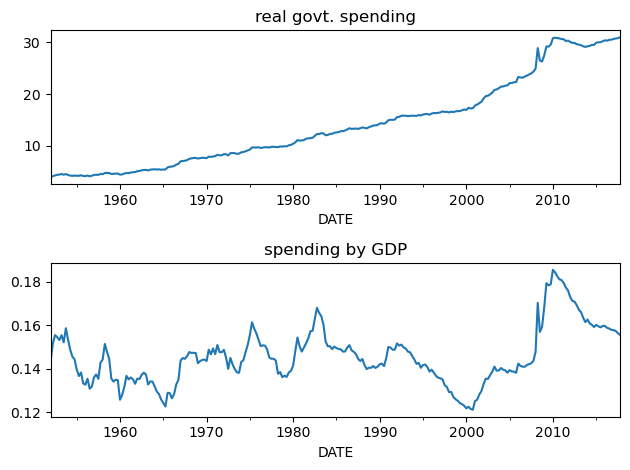

In [8]:
plt.figure(1)
plt.subplot(2,1,1)
macrodata['real_g'].plot(title='real govt. spending');#no need to specify for first axis
plt.subplot(2,1,2)
macrodata['real_g_y'].plot(ax=plt.gca(),title='spending by GDP');
plt.tight_layout()
macrodata['real_g_y'].describe()

<Figure size 640x480 with 0 Axes>

<Axes: >

<Axes: title={'center': 'nominal govt. spending'}, xlabel='DATE'>

<Axes: >

<Axes: title={'center': 'spending by GDP'}, xlabel='DATE'>

count   264.0000
mean      0.1457
std       0.0128
min       0.1213
25%       0.1373
50%       0.1442
75%       0.1511
max       0.1856
Name: g_y, dtype: float64

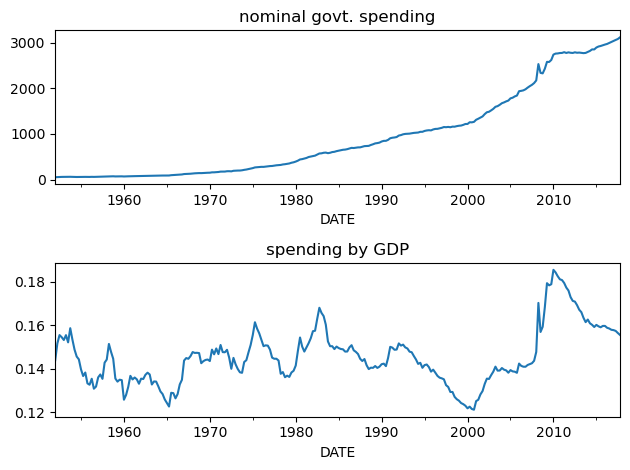

In [9]:
plt.figure(1)
plt.subplot(2,1,1)
macrodata['g'].plot(title='nominal govt. spending');#no need to specify for first axis
plt.subplot(2,1,2)
macrodata['g_y'].plot(ax=plt.gca(),title='spending by GDP');
plt.tight_layout()
macrodata['g_y'].describe()

### Detrended Nominal Governemnt Spending (Federal)
We extract a linear trend from log nominal spending

<Figure size 640x480 with 0 Axes>

<Axes: >

<Axes: title={'center': 'nominal govt. spending'}, xlabel='DATE'>

<Axes: >

<Axes: title={'center': 'nominal govt. spending detrended'}, xlabel='DATE'>

count   264.0000
mean      0.0000
std      17.0178
min     -36.0894
25%      -9.8462
50%      -4.3743
75%      12.3071
max      34.7007
Name: ln_g_dt, dtype: float64

0.9926229724647988

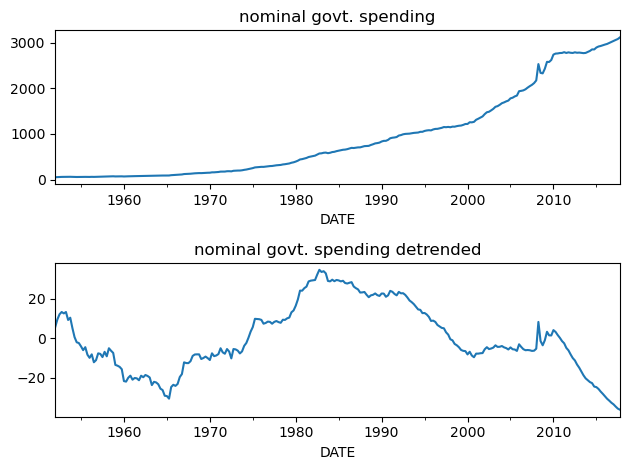

In [10]:
detrended_ln_g = sm.tsa.detrend(np.log(macrodata['g']), order=1)

macrodata['ln_g_dt']=detrended_ln_g *100
plt.figure(1)
plt.subplot(2,1,1)
macrodata['g'].plot(title='nominal govt. spending');#no need to specify for first axis
plt.subplot(2,1,2)
macrodata['ln_g_dt'].plot(ax=plt.gca(),title='nominal govt. spending detrended');
plt.tight_layout()

macrodata['ln_g_dt'].describe()
macrodata['ln_g_dt'].autocorr()

### Governemnt Nominal  Revenues (Federal)
We construct Revenues as  Nominal Federal TotalCurrentTaxReceipts +Federal'ContributionToSocialInsurance'

<Figure size 640x480 with 0 Axes>

<Axes: >

<Axes: title={'center': 'nominal govt. revenues'}, xlabel='DATE'>

<Axes: >

<Axes: title={'center': 'revenues by GDP'}, xlabel='DATE'>

count   264.0000
mean     16.9515
std       0.9768
min      14.2183
25%      16.4549
50%      16.9389
75%      17.5132
max      19.6108
Name: R_y, dtype: float64

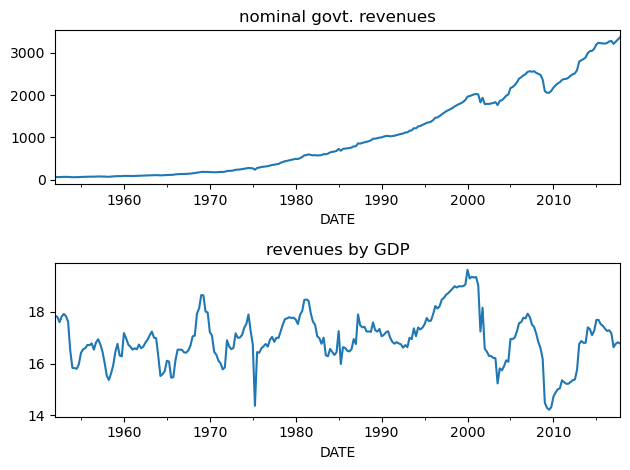

In [11]:
plt.figure(1)
plt.subplot(2,1,1)
macrodata['R'].plot(title='nominal govt. revenues');#no need to specify for first axis
plt.subplot(2,1,2)
macrodata['R_y'].plot(ax=plt.gca(),title='revenues by GDP');
plt.tight_layout()

macrodata['R_y'].describe()

### Nominal Primary deficit (Federal)
We construct Deficits are defined expenditures minus revenues.

<Figure size 640x480 with 0 Axes>

<Axes: >

<Axes: title={'center': 'real primary deficits'}, xlabel='DATE'>

<Axes: >

<Axes: title={'center': 'deficits by GDP'}, xlabel='DATE'>

count   264.0000
mean    -16.8059
std       0.9829
min     -19.4889
25%     -17.3675
50%     -16.7936
75%     -16.3142
max     -14.0399
Name: deficits_y, dtype: float64

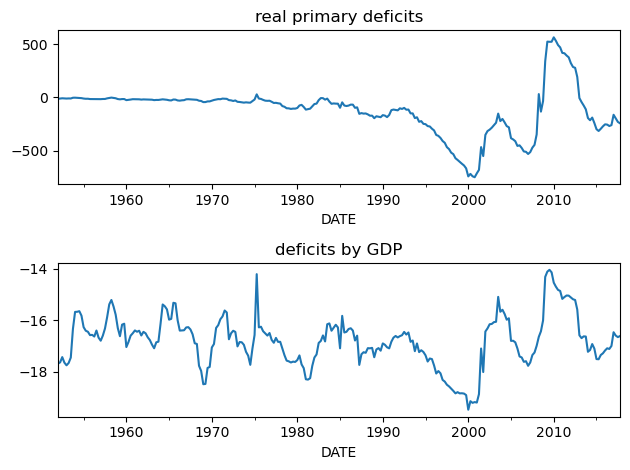

In [12]:
plt.figure(1)
plt.subplot(2,1,1)
macrodata['deficits'].plot(title='real primary deficits');#no need to specify for first axis
plt.subplot(2,1,2)
macrodata['deficits_y'].plot(ax=plt.gca(),title='deficits by GDP');
plt.tight_layout()

macrodata['deficits_y'].describe()

### Constructing $\frac{X_t}{\overline{y}_t}$

In this section, we construct a series for deficits relative to output trend. 

The deficits are divided by a seriers $\overline{y}_t$ that is simply the trend in GDP extracted by assuming a constant growth in logs, that is, $\overline{y_t}$ satisfies

$$ \log\text{real_gdp}_t =\underbrace{g_y t+\log y_0}_{\log{\overline{y}_t}}+ \log{\text{ deviations from trend}_t} $$


### Output trend $\overline{y}_t$

<Axes: xlabel='DATE'>

Growth rate per quarter % = 0.7771052895013658


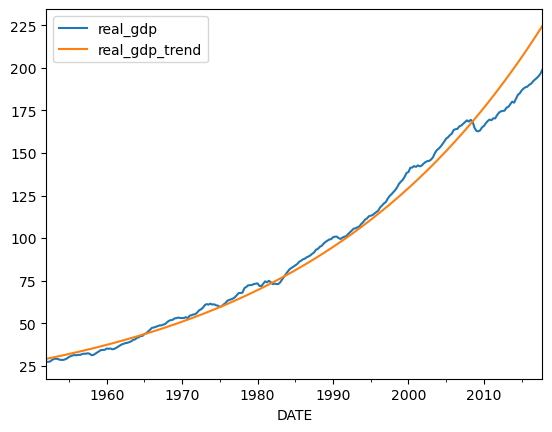

In [13]:
detrended_log_gdp = sm.tsa.detrend(np.log(macrodata['real_gdp']), order=1)
#detrended_log_gdp.plot()
log_trend=np.log(macrodata['real_gdp'])-detrended_log_gdp
y_trend=np.exp(log_trend)
macrodata['real_gdp_trend']=y_trend
macrodata['ln_real_gdp_dt']=detrended_log_gdp
gy=(log_trend-log_trend.shift()).mean()

#gy =0.0
macrodata[['real_gdp','real_gdp_trend']].plot()

print('Growth rate per quarter % = ' + str(gy*100))


<Axes: xlabel='DATE'>

Growth rate per quarter % = 1.676796473026158


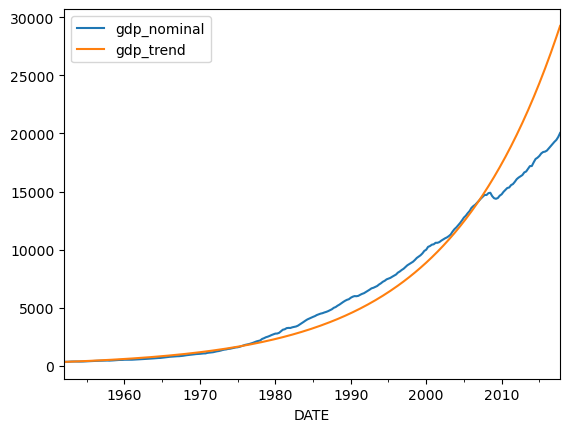

In [14]:
detrended_log_gdp = sm.tsa.detrend(np.log(macrodata['gdp_nominal']), order=1)
#detrended_log_gdp.plot()
log_trend=np.log(macrodata['gdp_nominal'])-detrended_log_gdp
y_trend=np.exp(log_trend)
macrodata['gdp_trend']=y_trend
macrodata['ln_gdp_dt']=detrended_log_gdp
gy=(log_trend-log_trend.shift()).mean()

#gy =0.0
macrodata[['gdp_nominal','gdp_trend']].plot()
print('Growth rate per quarter % = ' + str(gy*100))


### Constructed series for  $\frac{X_t}{\overline{y}_t}$

<Axes: xlabel='DATE'>

,deficits_y,deficits_dt
count,264.0000,264.0000
mean,-16.8059,-2.5279
std,0.9829,2.0603
min,-19.4889,-8.3471
25%,-17.3675,-3.4904
50%,-16.7936,-2.5877
75%,-16.3142,-1.5343
max,-14.0399,3.2538


,deficits_y,deficits_dt
deficits_y,1.0000,0.8454
deficits_dt,0.8454,1.0000


0.957983144011151

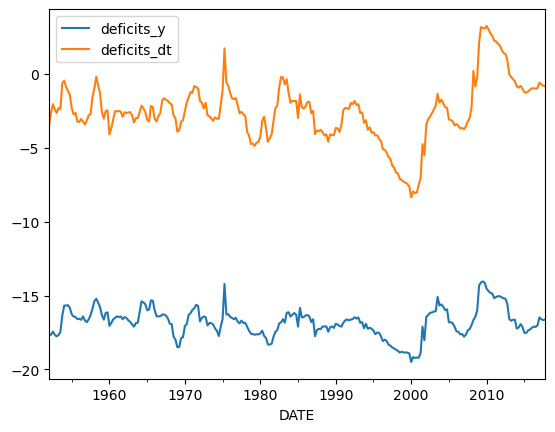

In [15]:
macrodata['deficits_dt']=(macrodata['deficits']/y_trend)*100
macrodata['deficits_dt_dm']=macrodata['deficits_dt']-macrodata['deficits_dt'].mean()
macrodata[['deficits_y','deficits_dt']].plot()
macrodata[['deficits_y','deficits_dt']].describe()
macrodata[['deficits_y','deficits_dt']].corr()
macrodata['deficits_dt'].autocorr()

### Tax rate 
We take away the trend using a HP filter


<Axes: xlabel='DATE'>

tau_alt   0.0167
tau       0.0139
dtype: float64

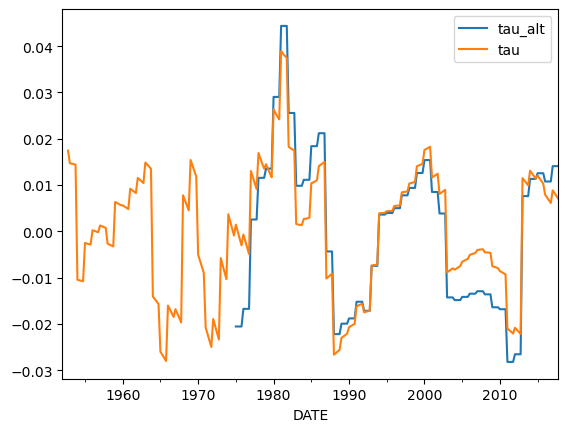

In [16]:

temp=taxdata.tau.resample('Q').bfill().reset_index()
temp.set_index(temp['index'],inplace=True)

cycle, trend = sm.tsa.filters.hpfilter(temp.tau,100000)
temp["cycle"] = cycle
temp["trend"] = trend

macrodata['tau_raw']=temp['cycle']+temp["trend"]
macrodata['tau']=temp.cycle+taxdata['tau'].mean()
macrodata['tau_alt']=macrodata['tau_raw'].values
macrodata.loc[macrodata.index.year<1975,'tau_alt']=np.nan
(macrodata[['tau_alt','tau']]-macrodata[['tau_alt','tau']].mean()).plot()
macrodata[macrodata.index.year>1974][['tau_alt','tau']].std()

### detreded TFP 
We construct the detreded TFP $\hat{\theta}_t$ using the expression

$$ \hat{\theta}_t = \widehat{\log(Y)}_t - \gamma \log(1-\overline{\tau}_{t})

<Axes: xlabel='DATE'>

count   261.0000
mean     17.9623
std      17.2717
min     -19.3580
25%       4.1563
50%      17.2976
75%      34.0305
max      45.3349
Name: theta, dtype: float64

0.9979097041854719

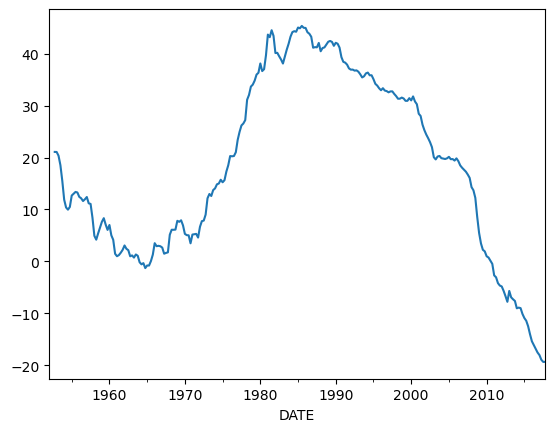

In [17]:
tau_bar=macrodata.tau.mean()
gamma=0.5

macrodata['theta']=macrodata['ln_gdp_dt'] -gamma*np.log(1-macrodata['tau'])

macrodata['theta']=macrodata['theta']*100
macrodata['theta'].plot()
macrodata['theta'].describe()
macrodata['theta'].autocorr()


##  Description of interpolated Yield Curve $Q^t_T$ 

We want to  discount with some version of $Q^t_T$. 

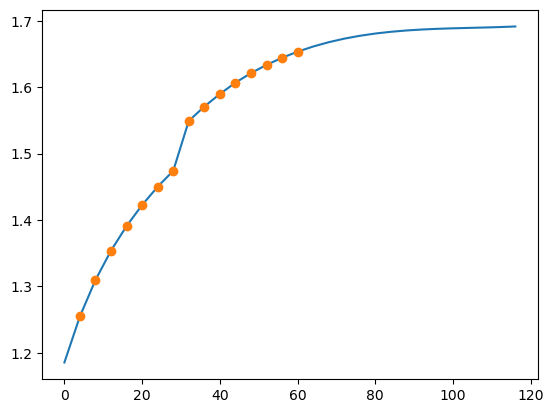

In [18]:
sel=(feds.index.year<2018)&(feds.index.year>1952)
#y=(feds.loc[sel,colnames].mean()/4)
# I want to fit a function to this data and then use it to interpolate the yields for the missing maturities
# I will use a cubic spline
x=np.array([4*k for k in range(1,15+1)])
y=feds.loc[sel,colnames].mean().values
y=((1+y/100)**(1/4)-1)*100
func_feds_mean = interp1d(x, y,kind='cubic',fill_value='extrapolate')

#define a function func_feds_mean that interpolates the yield curve and sets it 
# the value at 120 quarters for maturities more than 120 quarters

# def func_feds_mean(n):
#     if n<15*4+1:
#         y=func_feds_intr(n)
#     else:
#         y=func_feds_intr(15*4)
#     return y   

feds_mean=np.array([ func_feds_mean(n)  for  n in range(0,120,4)])
#plot the interpolated yield curve and compare it to the original data
plt.plot(range(0,120,4),feds_mean)
plt.plot(x,y,'o')
QT=lambda n: np.exp(-n*func_feds_mean(n)/100)   

# save the data as a csv file to be used to create a tikz plot
feds_mean=pd.DataFrame(feds_mean)
feds_mean.columns=['yield']
# add a column for the maturities
feds_mean['Maturities']=np.array([n for n in range(0,120,4)])
# add a column for the discount factors
feds_mean['DiscountFactor']=QT(feds_mean['Maturities'])
# save the data as a csv file
feds_mean.to_csv(draft_path+'feds_mean.csv')




## Description of Bond returns

This is the decription from CRSP: The Fama Maturity Portfolios are defined in 6-month intervals (TREASNOX range 2000028–2000037) and in 12-month intervals (TREASNOX range 2000040–2000044) for up to 60 months. TREASNOX 2000038 is a single portfolio for maturities between 60 and 120 months, and TREASNOX 2000039 is a single portfolio for maturities greater than 120 months. Each TREASNOX represents the portfolio containing one-month holding period returns for issues maturing in a range of months from the quote date. Callable, non-callable, and non-flower notes and bonds are included in the portfolios. Partially and full tax-exempt issues are excluded. The returns are calculated as the equal-weighted average of the unadjusted holding period return (TMRETNUA) for each bond in the portfolio. For our analysis we use hprXX where $XX  \in \{1,2,3,4,5, 510\}$ are maturities. 



In [19]:
def get_returns_ff(key,var_name,fama_portfolio):
    long_return=pd.DataFrame([fama_portfolio[fama_portfolio['KYTREASNOX']==key]['TMEWRETD'].values])
    long_return=long_return.T
    long_return['qdate'] = pd.date_range('1952-01-31',periods = len(long_return), freq='M')
    long_return.set_index('qdate',inplace=True)
    long_return.columns=[var_name]
    return pd.DataFrame(long_return.resample(freq).sum())*100

def adjust_real_hpr(n,inflation):
    inflation=inflation-inflation.mean()
    rho_pi=inflation.autocorr()
    factor=( (rho_pi/(1-rho_pi) )* (1-rho_pi**(n-1)) )* (inflation.shift(-1)-rho_pi*inflation)
    return factor




def construct_real_excess_returns(n,hpr,nom_rate):
    hprx=(hpr-nom_rate)
    #maturity=n*((freq=='A')*1.0+(freq=='Q')*4.0)
    # hprx=hprx+adjust_real_hpr(maturity,macrodata.inflation)
    return hprx
    

### Inflation adjustment 
In our baseline we want to use the real excess holding period return on nominal bonds. Since the inflation term will be in both the return on long bond and the risk-free rate, it will be cancelled. So no inflation adjustment is necessary

In [20]:
nom_returns = pd.DataFrame(macrodata['nom_shortrate'])
return_list = []
for mat in range(6, 66, 6):
    ret = get_returns_ff(2000027+mat/6, 'ret', fama_portfolio)
    nom_returns['hprx'+str(mat)+'m'] = ret
    macrodata['hprx'+str(mat)+'m'] = construct_real_excess_returns(mat /
                                                                   12.0, ret.ret, macrodata['nom_shortrate'])
    return_list.append('hprx'+str(mat)+'m')

hpr510yr = get_returns_ff(2000038, 'hpr510yr', fama_portfolio)
hpr10plusyr = get_returns_ff(2000039, 'hpr10plusyr', fama_portfolio)
macrodata['hprx510yr'] = construct_real_excess_returns(
    7.5, hpr510yr.hpr510yr, macrodata['nom_shortrate'])
macrodata['hprx10plusyr'] = construct_real_excess_returns(
    15.0, hpr10plusyr.hpr10plusyr, macrodata['nom_shortrate'])

nom_returns['hprx40Q'] = hpr510yr

macrodata['rf_lag'] = macrodata['rf'].shift()
return_list.append('hprx510yr')
return_list.append('hprx10plusyr')


#col_rename_dict = {i: j for i, j in zip(nom_returns.columns, yields_mat)}
#nom_returns.rename(columns=col_rename_dict, inplace=True)


### Constructing Table 1

In [21]:
col_rename_dict = {i: j for i, j in zip(nom_returns.columns, ['{}m'.format(3*k) for k in np.hstack((np.hstack(([1], [j for j in range(2, 21, 2)])),40))])}
nom_returns.rename(columns=col_rename_dict, inplace=True)



#### Time series for returns

array([[<Axes: xlabel='DATE'>, <Axes: xlabel='DATE'>],
       [<Axes: xlabel='DATE'>, <Axes: xlabel='DATE'>],
       [<Axes: xlabel='DATE'>, <Axes: xlabel='DATE'>],
       [<Axes: xlabel='DATE'>, <Axes: xlabel='DATE'>],
       [<Axes: xlabel='DATE'>, <Axes: xlabel='DATE'>],
       [<Axes: xlabel='DATE'>, <Axes: xlabel='DATE'>]], dtype=object)

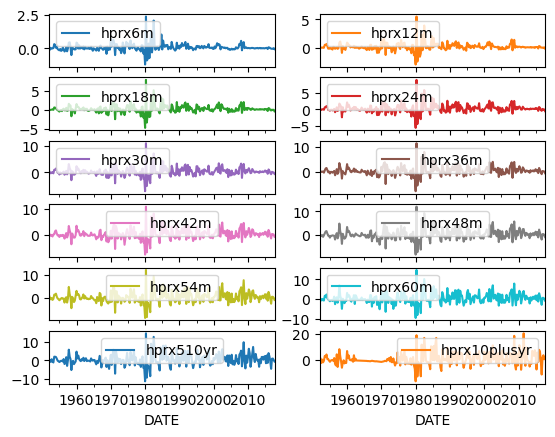

In [22]:
macrodata[return_list].plot(subplots=True,layout=(6,2))

## Construct the first principal component of returns $f_t$
It turned out that the CP factor did not explain much of our holding period returns. Therefore I decided to try the first principal compnent

explained variation
[0.88965443]


<Axes: xlabel='DATE'>

sigma2_f
63.32618786948786


DATE
1952-03-31        NaN
1952-06-30        NaN
1952-09-30        NaN
1952-12-31        NaN
1953-03-31    -3.4185
               ...   
2016-12-31   -12.7758
2017-03-31        NaN
2017-06-30        NaN
2017-09-30        NaN
2017-12-31        NaN
Freq: Q-DEC, Name: factor, Length: 264, dtype: float64

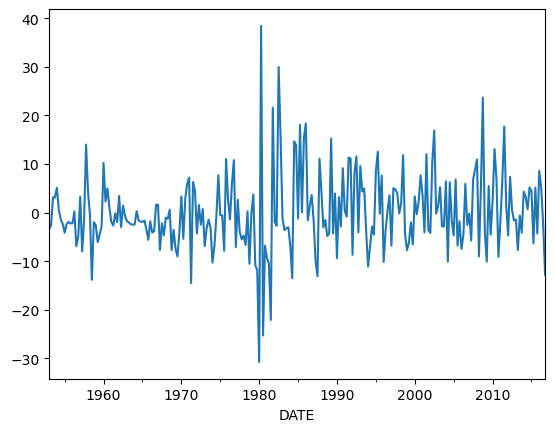

In [23]:
data=macrodata[(macrodata.index.year>start_year)&(macrodata.index.year<end_year) ]

#factornamelist=return_list+ ['deficits_y','nom_shortrate','log_gdp_dt'] 

factornamelist =['deficits_y','nom_shortrate','ln_real_gdp_dt'] + return_list

pca = PCA(n_components=1)
principalComponents = pca.fit_transform(data[factornamelist])
pair_of_return=return_list[:-1]

print ("explained variation")
print (pca.explained_variance_ratio_)

#data['factor']=macrodata["real_gdp"]/macrodata["real_gdp"].shift(4)-1
data['factor']=principalComponents
data['factor'].plot()
print ("sigma2_f")
print (data['factor'].var())
macrodata['factor']=data.factor
macrodata['factor']
#create a column "dateaalt" that reads year.quarter/4 in the format 1952.0,1952.25 and so on
macrodata['datealt']=macrodata.index.year+macrodata.index.quarter/4.0
macrodata[['datealt','factor']].to_csv(draft_path+'factordata.csv')


In [24]:
macrodata[return_list+['deficits_dt','nom_shortrate','nom_shortrate_news','nom_shortrate_lead1']].describe().T

,count,mean,std,min,25%,50%,75%,max
hprx6m,264.0000,0.0757,0.3030,-1.1931,-0.0404,0.0321,0.1640,2.3668
hprx12m,264.0000,0.1423,0.7020,-2.9796,-0.1110,0.0486,0.3495,5.4777
hprx18m,264.0000,0.2028,1.0622,-4.7757,-0.2605,0.0805,0.5105,7.8365
hprx24m,264.0000,0.2270,1.3472,-5.7238,-0.4632,0.0909,0.7028,9.0635
hprx30m,264.0000,0.2635,1.6803,-7.1693,-0.5820,0.0762,0.8725,10.9599
hprx36m,264.0000,0.3006,1.9097,-8.0650,-0.6526,0.0825,1.0383,11.5576
hprx42m,264.0000,0.3270,2.1035,-7.7213,-0.7602,0.0884,1.3015,10.9855
hprx48m,264.0000,0.3313,2.3135,-8.2436,-0.9198,-0.0229,1.3716,11.9944
hprx54m,264.0000,0.3552,2.4678,-8.5431,-1.0041,-0.0017,1.5461,11.9771
hprx60m,264.0000,0.2880,2.7901,-9.7209,-1.2256,-0.0544,1.7302,14.7989


In [25]:
macrodata[return_list+['deficits_y','nom_shortrate','nom_shortrate_news','nom_shortrate_lead1']].describe().T

,count,mean,std,min,25%,50%,75%,max
hprx6m,264.0000,0.0757,0.3030,-1.1931,-0.0404,0.0321,0.1640,2.3668
hprx12m,264.0000,0.1423,0.7020,-2.9796,-0.1110,0.0486,0.3495,5.4777
hprx18m,264.0000,0.2028,1.0622,-4.7757,-0.2605,0.0805,0.5105,7.8365
hprx24m,264.0000,0.2270,1.3472,-5.7238,-0.4632,0.0909,0.7028,9.0635
hprx30m,264.0000,0.2635,1.6803,-7.1693,-0.5820,0.0762,0.8725,10.9599
hprx36m,264.0000,0.3006,1.9097,-8.0650,-0.6526,0.0825,1.0383,11.5576
hprx42m,264.0000,0.3270,2.1035,-7.7213,-0.7602,0.0884,1.3015,10.9855
hprx48m,264.0000,0.3313,2.3135,-8.2436,-0.9198,-0.0229,1.3716,11.9944
hprx54m,264.0000,0.3552,2.4678,-8.5431,-1.0041,-0.0017,1.5461,11.9771
hprx60m,264.0000,0.2880,2.7901,-9.7209,-1.2256,-0.0544,1.7302,14.7989


## Summary Statistics for returns and deficits (detrended)

In [26]:
macrodata[return_list+['deficits_dt','nom_shortrate','nom_shortrate_news','nom_shortrate_lead1']].describe().T

,count,mean,std,min,25%,50%,75%,max
hprx6m,264.0000,0.0757,0.3030,-1.1931,-0.0404,0.0321,0.1640,2.3668
hprx12m,264.0000,0.1423,0.7020,-2.9796,-0.1110,0.0486,0.3495,5.4777
hprx18m,264.0000,0.2028,1.0622,-4.7757,-0.2605,0.0805,0.5105,7.8365
hprx24m,264.0000,0.2270,1.3472,-5.7238,-0.4632,0.0909,0.7028,9.0635
hprx30m,264.0000,0.2635,1.6803,-7.1693,-0.5820,0.0762,0.8725,10.9599
hprx36m,264.0000,0.3006,1.9097,-8.0650,-0.6526,0.0825,1.0383,11.5576
hprx42m,264.0000,0.3270,2.1035,-7.7213,-0.7602,0.0884,1.3015,10.9855
hprx48m,264.0000,0.3313,2.3135,-8.2436,-0.9198,-0.0229,1.3716,11.9944
hprx54m,264.0000,0.3552,2.4678,-8.5431,-1.0041,-0.0017,1.5461,11.9771
hprx60m,264.0000,0.2880,2.7901,-9.7209,-1.2256,-0.0544,1.7302,14.7989


In [27]:
macrodata[return_list+['deficits_dt','nom_shortrate','unemp','nom_shortrate_news','nom_shortrate_lead1']].corr()

,hprx6m,hprx12m,hprx18m,hprx24m,hprx30m,hprx36m,hprx42m,hprx48m,hprx54m,hprx60m,hprx510yr,hprx10plusyr,deficits_dt,nom_shortrate,unemp,nom_shortrate_news,nom_shortrate_lead1
hprx6m,1.0000,0.9479,0.9049,0.8715,0.8434,0.8266,0.7901,0.7626,0.7489,0.7207,0.7101,0.5511,0.0211,0.0795,0.1428,-0.6769,-0.0039
hprx12m,0.9479,1.0000,0.9816,0.9624,0.9415,0.9232,0.8995,0.8733,0.8595,0.8378,0.8218,0.6480,0.0702,-0.0334,0.1548,-0.6915,-0.1157
hprx18m,0.9049,0.9816,1.0000,0.9820,0.9678,0.9579,0.9393,0.9143,0.9024,0.8835,0.8675,0.6915,0.0766,-0.0254,0.1718,-0.6595,-0.1034
hprx24m,0.8715,0.9624,0.9820,1.0000,0.9842,0.9771,0.9686,0.9474,0.9389,0.9236,0.9064,0.7398,0.0944,-0.0650,0.1652,-0.6365,-0.1417
hprx30m,0.8434,0.9415,0.9678,0.9842,1.0000,0.9849,0.9778,0.9616,0.9509,0.9428,0.9257,0.7616,0.0896,-0.0784,0.1586,-0.6073,-0.1502
hprx36m,0.8266,0.9232,0.9579,0.9771,0.9849,1.0000,0.9862,0.9741,0.9653,0.9492,0.9417,0.7870,0.1004,-0.0825,0.1699,-0.5938,-0.1555
hprx42m,0.7901,0.8995,0.9393,0.9686,0.9778,0.9862,1.0000,0.9870,0.9787,0.9619,0.9597,0.8063,0.1036,-0.0904,0.1706,-0.5645,-0.1662
hprx48m,0.7626,0.8733,0.9143,0.9474,0.9616,0.9741,0.9870,1.0000,0.9792,0.9637,0.9678,0.8311,0.1055,-0.0980,0.1651,-0.5599,-0.1720
hprx54m,0.7489,0.8595,0.9024,0.9389,0.9509,0.9653,0.9787,0.9792,1.0000,0.9683,0.9707,0.8446,0.1103,-0.1030,0.1473,-0.5222,-0.1771
hprx60m,0.7207,0.8378,0.8835,0.9236,0.9428,0.9492,0.9619,0.9637,0.9683,1.0000,0.9659,0.8526,0.1079,-0.1062,0.1600,-0.5245,-0.1741


In [28]:
macrodata[return_list+['deficits_y','nom_shortrate','unemp','nom_shortrate_news','nom_shortrate_lead1']].corr()

,hprx6m,hprx12m,hprx18m,hprx24m,hprx30m,hprx36m,hprx42m,hprx48m,hprx54m,hprx60m,hprx510yr,hprx10plusyr,deficits_y,nom_shortrate,unemp,nom_shortrate_news,nom_shortrate_lead1
hprx6m,1.0000,0.9479,0.9049,0.8715,0.8434,0.8266,0.7901,0.7626,0.7489,0.7207,0.7101,0.5511,-0.0102,0.0795,0.1428,-0.6769,-0.0039
hprx12m,0.9479,1.0000,0.9816,0.9624,0.9415,0.9232,0.8995,0.8733,0.8595,0.8378,0.8218,0.6480,0.0640,-0.0334,0.1548,-0.6915,-0.1157
hprx18m,0.9049,0.9816,1.0000,0.9820,0.9678,0.9579,0.9393,0.9143,0.9024,0.8835,0.8675,0.6915,0.0759,-0.0254,0.1718,-0.6595,-0.1034
hprx24m,0.8715,0.9624,0.9820,1.0000,0.9842,0.9771,0.9686,0.9474,0.9389,0.9236,0.9064,0.7398,0.0990,-0.0650,0.1652,-0.6365,-0.1417
hprx30m,0.8434,0.9415,0.9678,0.9842,1.0000,0.9849,0.9778,0.9616,0.9509,0.9428,0.9257,0.7616,0.0975,-0.0784,0.1586,-0.6073,-0.1502
hprx36m,0.8266,0.9232,0.9579,0.9771,0.9849,1.0000,0.9862,0.9741,0.9653,0.9492,0.9417,0.7870,0.1045,-0.0825,0.1699,-0.5938,-0.1555
hprx42m,0.7901,0.8995,0.9393,0.9686,0.9778,0.9862,1.0000,0.9870,0.9787,0.9619,0.9597,0.8063,0.1116,-0.0904,0.1706,-0.5645,-0.1662
hprx48m,0.7626,0.8733,0.9143,0.9474,0.9616,0.9741,0.9870,1.0000,0.9792,0.9637,0.9678,0.8311,0.1159,-0.0980,0.1651,-0.5599,-0.1720
hprx54m,0.7489,0.8595,0.9024,0.9389,0.9509,0.9653,0.9787,0.9792,1.0000,0.9683,0.9707,0.8446,0.1161,-0.1030,0.1473,-0.5222,-0.1771
hprx60m,0.7207,0.8378,0.8835,0.9236,0.9428,0.9492,0.9619,0.9637,0.9683,1.0000,0.9659,0.8526,0.1102,-0.1062,0.1600,-0.5245,-0.1741


#### Covariances of returns and deficits

In [29]:
variables = ['deficits_dt', 'tau','nom_shortrate','nom_shortrate_news','nom_shortrate_lead1']
#macrodata = macrodata.join(lpdata_yields_interpolated)

In [30]:
rescal_mat = macrodata[return_list[0:-1]+variables]
rescal_mat['tau'] = rescal_mat['tau']*100
#rescal_mat['Yield_3m'] = rescal_mat['Yield_3m']
rescal_mat['nom_shortrate'] = rescal_mat['nom_shortrate']
rescal_mat['nom_shortrate_news'] = rescal_mat['nom_shortrate_news']
rescal_mat['nom_shortrate_lead1'] = rescal_mat['nom_shortrate_lead1']

rescal_mat['surplus'] = -rescal_mat['deficits_dt']
cov_mat = rescal_mat.cov()
cov_mat.where(np.triu(np.ones(cov_mat.shape)).astype(bool)).to_csv(
    'covariances_returns_deficits_no_adjust.csv', float_format='%.2g')
cov_mat.where(np.triu(np.ones(cov_mat.shape)).astype(bool))


,hprx6m,hprx12m,hprx18m,hprx24m,hprx30m,hprx36m,hprx42m,hprx48m,hprx54m,hprx60m,hprx510yr,deficits_dt,tau,nom_shortrate,nom_shortrate_news,nom_shortrate_lead1,surplus
hprx6m,0.0918,0.2017,0.2913,0.3558,0.4295,0.4784,0.5037,0.5346,0.5600,0.6094,0.6894,0.0132,0.0167,0.0186,-0.0353,-0.0009,-0.0132
hprx12m,NaN,0.4928,0.7320,0.9103,1.1106,1.2377,1.3282,1.4184,1.4891,1.6411,1.8481,0.1016,-0.0214,-0.0181,-0.0837,-0.0627,-0.1016
hprx18m,NaN,NaN,1.1282,1.4053,1.7273,1.9432,2.0987,2.2469,2.3655,2.6183,2.9520,0.1677,-0.0274,-0.0208,-0.1207,-0.0848,-0.1677
hprx24m,NaN,NaN,NaN,1.8150,2.2280,2.5138,2.7449,2.9528,3.1216,3.4716,3.9121,0.2620,-0.0684,-0.0675,-0.1478,-0.1474,-0.2620
hprx30m,NaN,NaN,NaN,NaN,2.8235,3.1605,3.4562,3.7384,3.9431,4.4204,4.9831,0.3102,-0.0910,-0.1016,-0.1759,-0.1949,-0.3102
hprx36m,NaN,NaN,NaN,NaN,NaN,3.6471,3.9617,4.3039,4.5493,5.0575,5.7611,0.3951,-0.0813,-0.1214,-0.1954,-0.2293,-0.3951
hprx42m,NaN,NaN,NaN,NaN,NaN,NaN,4.4247,4.8031,5.0805,5.6453,6.4669,0.4491,-0.1406,-0.1466,-0.2046,-0.2700,-0.4491
hprx48m,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.3525,5.5908,6.2205,7.1730,0.5027,-0.1812,-0.1747,-0.2232,-0.3074,-0.5027
hprx54m,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0900,6.6672,7.6739,0.5609,-0.1929,-0.1959,-0.2220,-0.3375,-0.5609
hprx60m,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.7846,8.6337,0.6205,-0.1681,-0.2285,-0.2521,-0.3753,-0.6205


#### Autocorrelations

In [31]:
pd.DataFrame(rescal_mat.apply(lambda x: x.autocorr())).T.to_csv(
    'autocorr.csv', float_format='%.2g')
pd.DataFrame(rescal_mat.apply(lambda x: x.autocorr())).T


,hprx6m,hprx12m,hprx18m,hprx24m,hprx30m,hprx36m,hprx42m,hprx48m,hprx54m,hprx60m,hprx510yr,deficits_dt,tau,nom_shortrate,nom_shortrate_news,nom_shortrate_lead1,surplus
0,-0.1117,-0.0786,-0.0939,-0.0777,-0.0939,-0.0685,-0.0515,-0.0340,-0.0438,-0.0652,-0.0255,0.9580,0.9154,0.9748,0.2453,0.9747,0.9580


In [32]:
rescal_mat.mean()

hprx6m                 0.0757
hprx12m                0.1423
hprx18m                0.2028
hprx24m                0.2270
hprx30m                0.2635
hprx36m                0.3006
hprx42m                0.3270
hprx48m                0.3313
hprx54m                0.3552
hprx60m                0.2880
hprx510yr              0.4382
deficits_dt           -2.5279
tau                   30.1723
nom_shortrate          1.0810
nom_shortrate_news    -0.0000
nom_shortrate_lead1    1.0837
surplus                2.5279
dtype: float64

#### Means

In [33]:
pd.DataFrame(rescal_mat.mean()).T.to_csv(
    'means_no_adj_inflation.csv', float_format='%.2g')
pd.DataFrame(rescal_mat.mean()).T


,hprx6m,hprx12m,hprx18m,hprx24m,hprx30m,hprx36m,hprx42m,hprx48m,hprx54m,hprx60m,hprx510yr,deficits_dt,tau,nom_shortrate,nom_shortrate_news,nom_shortrate_lead1,surplus
0,0.0757,0.1423,0.2028,0.2270,0.2635,0.3006,0.3270,0.3313,0.3552,0.2880,0.4382,-2.5279,30.1723,1.0810,-0.0000,1.0837,2.5279


# RESULTS

## 1. Target Portfolio


In the paper we show that
$$
\sum_{i\neq rf}\omega_{t}^{i}cov_{t}\left(r_{t+1}^{i},r_{t+1}^{j}\right)	=\sum_{k=1}^{\infty}s_{t}^{Q,k}cov_{t}\left(\ln Q_{t+1}^{k},r_{t+1}^{j}\right)-\sum_{k=1}^{\infty}s_{t}^{G,k}cov_{t}\left(\ln G_{t+k},r_{t+1}^{j}\right)
+\sum_{k=1}^{\infty}s_{t}^{\Theta,k}cov_{t}\left(\ln\theta_{t+k},r_{t+1}^{j}\right)
$$
    
where 
$$
s_{t}^{Q,k}:=\frac{Q_{t}^{k+1}\mathbb{E}_{t}\left(T^*_{t+k+1}-G_{t+k+1}\right)}{Q_{t}^{rf}B_{t}},s_{t}^{G,k}:=\frac{Q_{t}^{k}\mathbb{E}_{t}G_{t+k}}{Q_{t}^{rf}B_{t}}, s_{t}^{\Theta,k}:=\frac{Q_{t}^{k}\mathbb{E}_{t}T_{t+k}}{Q_{t}^{rf}B_{t}} 
$$

and $T^*_{t+k} = \mathcal{T}_{T}^{*}\left(\theta_{t+k}\right)=\tau_{T}^{*}\theta_{t+k}\left(1-\tau_{T}^{*}\right)^{1-\gamma}$





Assume that

* The market strcture is given by zero coupon bonds of maturities 1 to 120
* returns, spending, TFP follow a factor structure with homoskedasktic errors

$$r^{k}_{t}=\alpha_k+\rho_{k} r^{k}_{t-1}+\delta_{(k)}  f_t+\sigma_{k}\varepsilon_{k,t}$$


$$\ln{G}_{t}= \ln\Gamma^{G} + \ln{G}_{t-1} + \kappa_{G}f_{t}+\sigma_{G}\epsilon_{t}^{G}$$

$$\ln{\theta}_{t}= \ln\Gamma^{\theta} + \ln{\theta}_{t-1} + \kappa_{\theta}f_{t}+\sigma_{\theta}\epsilon_{t}^{\theta}$$


$$f_t=\sigma_f \varepsilon_{f,t}$$

* We take as observables $\{Q^k_T\}$, $G_T$, $B_T$, $\theta_T$. We use  the normalization  $Y_T=1$: 

    * then we set $B_T=4$, $G_T=0.15$
    * $\Gamma^G=\Gamma^\theta=1.005$
    * labor supply elasticity $\gamma=0.5$

*  we can compute $\tau^*$ using 

$$\tau_{T}^{*}\left(1-\tau_{T}^{*}\right)^{1-\gamma}=\frac{B_{T}+G_{T}\sum_{t=1}^{\infty}Q_{T}^{t}\mathbb{E}_{T}\frac{G_{T+t}}{G_{T}}}{\left(1-\tau_{T}\right)^{-\gamma}\sum_{t=1}^{\infty}Q_{T}^{t}\mathbb{E}_{T}\frac{\theta_{T+t}}{\theta_{T}}}$$


Using the factor structure, 

* let $\Delta$ is a diagonal matrix with elements $\sigma^2_k$  then inverse 

$$
\Sigma_{T}^{-1}=\Delta^{-1}-\frac{\left(\Delta^{-1}\mathbf{\kappa}_{\left(r\right)}\right)\cdot\left(\Delta^{-1}\mathbf{\kappa}_{\left(r\right)}\right)^{\intercal}}{\left[var\left(f_{t}\right)\right]^{-1}+\mathbf{\kappa}_{\left(r\right)}^{\intercal}\Delta^{-1}\mathbf{\kappa}_{\left(r\right)}}
$$

* the covariances 
    * $cov_T \left(\ln G_{T+k}, r^j_{T+1}\right)=\kappa_G \kappa_j\sigma^2_f$
    * $cov_T \left(\ln \theta_{T+k}, r^j_{T+1}\right)=\kappa_\theta \kappa_j\sigma^2_f$
    * $cov_T \left ( \ln Q^{k-1}_{T+1},r^j_{T+1} \right)=cov_T (r^{k}_{T+1},r^{j}_{T+1})=\kappa_j \kappa_i \sigma^2_f+\iota_{\{i==j\}}\sigma^2_j$

* the weights 
$$ \mathbf{s}_{T}^{Q}[k]=\frac{Q_{T}^{k+1}\Gamma^{k+1}}{Q_{T}^{rf}\sum Q_{T}^{k+1}\Gamma^{k+1}},\quad\mathbf{s}_{T}^{G}[k]=\frac{Q_{T}^{k}\left(\Gamma^{G}\right)^{k}}{Q_{T}^{rf}}\frac{G_{T}}{B_{T}},\quad\mathbf{s}_{T}^{\theta}[k]=\frac{Q_{T}^{k}\left(\Gamma^{\theta}\right)^{k}}{Q_{T}^{rf}}\frac{T_{T}^{*}}{B_{T}} $$    
    
* So the portfolios are $\mathbf{\omega}_{T}=\mathbf{\omega}_{T}^{Q}+\mathbf{\omega}_{T}^{\theta}+\mathbf{\omega}_{T}^{G}$ where

    $$\omega^\theta_T= \frac{T^*_T}{Q^{rf}_T B_T} \sigma^2_f \kappa_\theta \sum_{k} (Q^k_T\Gamma^k )  \Sigma^{-1}_T \mathbf{\kappa}_{(r)}$$

    $$\omega^G_T= - \frac{G_T}{Q^{rf}_T B_T} \sigma^2_f \kappa_G \sum_{k} (Q^k_T\Gamma^k )  \Sigma^{-1}_T \mathbf{\kappa}_{(r)}$$


In [34]:
B_T=4.0
Gamma=1+0.02/4
tau_T=0.3
gamma=0.5
G_T=.15
Pii=1.0
N=30
γ=gamma


In [35]:
Gamma

1.005

77.33201605430494
0.9870687452490858


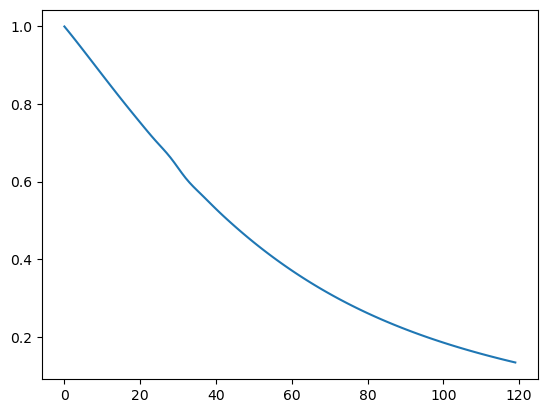

In [36]:

#plot QT for n=0 to 120
plt.plot(range(0,N*4,1),[QT(n) for n in range(0,N*4,1)])
PVQ=0
for n in range(1,N*4*4,1):
    PVQ+=QT(n)*Gamma**(n)
print(PVQ)
beta_hat=1-1/PVQ
print(beta_hat)


### finding the optimal tau
We use 
$$\tau_{T}^{*}\left(1-\tau_{T}^{*}\right)^{1-\gamma}=\frac{B_{T}+G_{T}\sum_{t=1}^{\infty}Q_{T}^{t}\mathbb{E}_{T}\frac{G_{T+t}}{G_{T}}}{\left(1-\tau_{T}\right)^{-\gamma}\sum_{t=1}^{\infty}Q_{T}^{t}\mathbb{E}_{T}\frac{\theta_{T+t}}{\theta_{T}}}$$



In [37]:
Nm=N*4*4
def res_tau(tau):
    LHS=tau*(1-tau)**(1-gamma)
    PVG=0
    PVTheta=0
    for t in range(1,Nm):
        PVG+=QT(t)*Gamma**(t)*G_T
        PVTheta+=QT(t)*Gamma**(t)*(1-tau_T)**(-gamma)
    RHS=(B_T+PVG)/PVTheta
    return LHS-RHS

taustar=optimize.fsolve(res_tau,0.3)[0]
print("the optimal tau is")
print(taustar)

Upsilonstar=taustar*(1-tau_T)**(-gamma)*(1-taustar)**(1-gamma)
print("the optimal Upsilon is")
print(Upsilonstar)
tau_bar=taustar
Upsilon_T=Upsilonstar


the optimal tau is
0.18720540404734815
the optimal Upsilon is
0.20172501900365702


In [38]:
print("implied beta_hat = " + str(beta_hat))

print( "(Quaterly) Output to Debt = " +str(1/B_T) )
print( "Growth rate= " +str(Gamma) )
print( "Avg gross inflation= " +str(Pii) )

print( "tax rate = " +str(tau_bar) )
print( "spending to output = " +str(G_T) )
print( "revenue to output = " +str(Upsilon_T) )


implied beta_hat = 0.9870687452490858
(Quaterly) Output to Debt = 0.25
Growth rate= 1.005
Avg gross inflation= 1.0
tax rate = 0.18720540404734815
spending to output = 0.15
revenue to output = 0.20172501900365702


### Measuring $\kappa_G,\kappa_\theta,\kappa_{(r)},\sigma_f$

We measure $\mathbf{\kappa}_{(r)}, \Delta$ for using the data on returns that we have  and  interpolate for other maturities

#### Estimating the factor regressions for returns

For each maturity $k$, we now run the regression 

$$r^{k}_{t}=\alpha_k +\kappa_{(k)}  f_t+\sigma_{k}\varepsilon_{k,t}$$

and record the factor loadings $\kappa_{r}\equiv\{\kappa_{(k)}\}$, $R2$, $\Delta\equiv diag \left(\{\sigma^2_{k}\}_k\right)$


In [39]:
lag=1
X=data[['cons','factor']]
alpha=np.zeros(len(pair_of_return))
se_alpha=np.zeros(len(pair_of_return))
rho=np.zeros(len(pair_of_return))
se_rho=np.zeros(len(pair_of_return))
kappa=np.zeros(len(pair_of_return))
se_kappa=np.zeros(len(pair_of_return))
r2=np.zeros(len(pair_of_return))
Delta=np.zeros(len(pair_of_return))
Deltaraw=np.zeros(len(pair_of_return))
std_simga2 = np.zeros(len(pair_of_return))

for ret in range(len(pair_of_return)):
    Y=data[pair_of_return[ret]]
    data['lag_ret']=data[pair_of_return[ret]].shift()
    X=data[['cons','factor','lag_ret']]
    model = sm.OLS(Y[lag:],X[lag:])
    results = model.fit()
    alpha[ret]=results.params.cons
    se_alpha[ret]=results.bse.cons
    rho[ret]=results.params.lag_ret
    se_rho[ret]=results.bse.lag_ret
    kappa[ret]=results.params.factor
    se_kappa[ret]=results.bse.factor
    r2[ret]=results.rsquared
    Delta[ret]=results.resid.var()
    Deltaraw[ret]=Y.var()
     #cehck with leo
    #std_simga2[ret]=np.sqrt(2*(Y.var())**2/(len(Y)-1))
    std_simga2[ret]=np.sqrt(2*(results.resid.var())**2/(len(Y)-1))
    
#kappa=np.zeros(len(pair_of_return))
Loadings=pd.DataFrame([alpha, se_alpha, rho, se_rho, kappa,se_kappa,Delta,std_simga2,r2,Deltaraw]).T
Loadings.index=pair_of_return
Loadings.columns=['alpha','se_alpha','rho','se_rho','kappa_f','se_kappa_f','sigma2','std_simga2','R2','sigma2_raw']
Loadings['maturities']=np.array([6,9,15,21,27,33,39,45,51,57,7.5*12])/3.0
Loadings['maturities']=Loadings['maturities'].astype(int)


           alpha  se_alpha     rho  se_rho  kappa_f  se_kappa_f  sigma2  \
hprx6m    0.0863    0.0136 -0.1068  0.0429   0.0279      0.0017  0.0439   
hprx12m   0.1549    0.0252 -0.0568  0.0346   0.0745      0.0031  0.1538   
hprx18m   0.2197    0.0331 -0.0415  0.0302   0.1184      0.0041  0.2666   
hprx24m   0.2449    0.0350 -0.0429  0.0252   0.1569      0.0043  0.3000   
hprx30m   0.2841    0.0392 -0.0425  0.0227   0.1992      0.0049  0.3784   
hprx36m   0.3154    0.0395 -0.0252  0.0202   0.2304      0.0049  0.3842   
hprx42m   0.3460    0.0380 -0.0216  0.0176   0.2573      0.0047  0.3557   
hprx48m   0.3440    0.0373 -0.0081  0.0158   0.2855      0.0046  0.3452   
hprx54m   0.3721    0.0371 -0.0218  0.0147   0.3057      0.0046  0.3412   
hprx60m   0.3042    0.0429 -0.0274  0.0151   0.3449      0.0054  0.4603   
hprx510yr 0.4440    0.0299  0.0029  0.0092   0.4044      0.0037  0.2218   

           std_simga2     R2  sigma2_raw  maturities  
hprx6m         0.0039 0.5363      0.0944    

<Axes: >

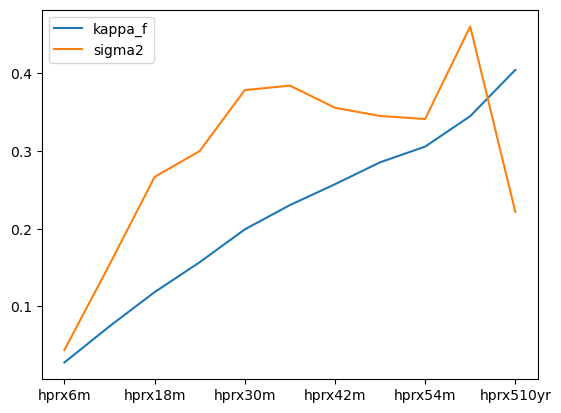

In [40]:
print (Loadings)
Loadings[['kappa_f','sigma2']].plot()    

In [41]:
Reg_table=Loadings

In [42]:
sigma2_f=data.factor.var()
print("factor variance = "+str(sigma2_f))


factor variance = 63.32618786948786


#### Estimating the factor regressions for log spending deviation

Like the returns, we also project $\hat{G}$ on the factor using 

$$\hat{G}_{t}=\ln \Gamma^G +  \hat{G}_{t-1} + \kappa_G f_t+\sigma_{G}\varepsilon_{G,t}$$



In [43]:
macrodata['ln_g_dt_lag'] = macrodata['ln_g_dt'].shift()

data = macrodata[(macrodata.index.year > start_year)
                 & (macrodata.index.year < end_year)]
sel = pd.notnull(data['ln_g_dt_lag']) & (pd.notnull(
    data['factor'])) & (pd.notnull(data['ln_g_dt']))

Y = data[sel].ln_g_dt-data[sel].ln_g_dt_lag
X = data[sel][['cons', 'factor']]
model = sm.OLS(Y[lag:], X[lag:])
results = model.fit()
print(results.summary())
kappa_G = results.params.factor
rho_G = 1.0
cov_rG_factor = Loadings.kappa_f*kappa_G*data.factor.var()

macrodata['ln_g_innv'] = macrodata['ln_g_dt'] - \
    rho_G*macrodata['ln_g_dt'].shift()
data['ln_g_innv'] = macrodata['ln_g_innv']

cov_rG_raw = macrodata[pair_of_return +
                       ['ln_g_innv']].cov().ln_g_innv[:-1].values
Loadings['cov_rG'] = cov_rG_factor
Loadings['cov_rG_raw'] = cov_rG_raw

Loadings['alpha_G'] = results.params.cons
Loadings['se_alpha_G'] = results.bse.cons

Loadings['kappa_G'] = results.params.factor
Loadings['se_alpha_G'] = results.bse.factor

Loadings['sigma_G']=results.resid.var()
## check with LEO
#Loadings['sigma_G_se'] = np.sqrt(2*(Y.var())**2/(len(Y)-1))
Loadings['sigma_G_se'] = np.sqrt(2*(results.resid.var())**2/(len(Y)-1))

Loadings['kappa_G'] = results.params.factor
Loadings['se_alpha_G'] = results.bse.factor

Loadings['rho_G']=rho_G
Loadings['kappa_G']=kappa_G
Loadings['se_rho_G']=np.NaN
Loadings['se_kappa_G']=results.bse.factor

Loadings["R2_G"]=results.rsquared


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     3.827
Date:                Wed, 20 Nov 2024   Prob (F-statistic):             0.0515
Time:                        15:59:35   Log-Likelihood:                -545.26
No. Observations:                 255   AIC:                             1095.
Df Residuals:                     253   BIC:                             1102.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
cons          -0.1769      0.129     -1.370      0.1

####  Covariance of returns $r^j_{T+1}$ and orthogonal component of deficit $\hat{G}$

We compute this two ways: using the factor structure and using the raw data 

Using the factor structure, the  T conditional covariance of $\hat{G}$ and $\boldsymbol{r}$ is given by 
$\kappa_G \kappa_f \sigma^2_{f} $

,cov_rG,cov_rG_raw
hprx6m,-0.0562,0.0045
hprx12m,-0.1497,-0.0579
hprx18m,-0.2380,-0.0793
hprx24m,-0.3155,-0.2058
hprx30m,-0.4003,-0.3724
hprx36m,-0.4632,-0.4234
hprx42m,-0.5171,-0.4942
hprx48m,-0.5738,-0.5496
hprx54m,-0.6145,-0.6729
hprx60m,-0.6933,-0.6274


<Axes: >

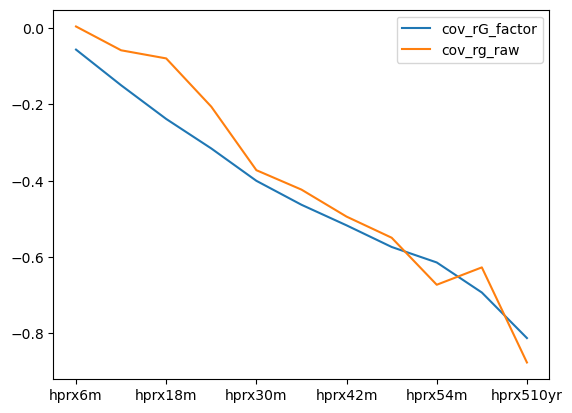

In [44]:
Loadings[['cov_rG','cov_rG_raw']]
Loadings[['cov_rG','cov_rG_raw']].plot()
plt.legend(['cov_rG_factor', 'cov_rg_raw'])
#save figure
plt.savefig(draft_path+'cov_rG.pdf')

#### Estimating the factor regressions for detrended tfp $\hat{\theta}$

Like the returns, we also project $\hat{\theta}$ on the factor using 

$$\hat{\theta}_{t}=\ln \Gamma^\theta +  \hat{\theta}_{t-1} + \kappa_{\theta} f_t+\sigma_{\theta}\varepsilon_{\theta,t}$$



In [45]:
macrodata['theta_lag'] = macrodata['theta'].shift()

data = macrodata[(macrodata.index.year > start_year)
                 & (macrodata.index.year < end_year)]
sel = pd.notnull(data['theta_lag']) & (pd.notnull(
    data['factor'])) & (pd.notnull(data['theta']))

Y = data[sel].theta-data[sel].theta_lag
X = data[sel][['cons', 'factor']]
model = sm.OLS(Y[lag:], X[lag:])
results = model.fit()
print(results.summary())
kappa_theta = results.params.factor
rho_theta = 1.0
cov_rtheta_factor = Loadings.kappa_f*kappa_theta*data.factor.var()

macrodata['theta_innv'] = macrodata['theta'] - \
    rho_theta*macrodata['theta'].shift()
data['theta_innv'] = macrodata['theta_innv']

cov_rtheta_raw = macrodata[pair_of_return +
                           ['theta_innv']].cov().theta_innv[:-1].values
Loadings['cov_rtheta'] = cov_rtheta_factor
Loadings['cov_rtheta_raw'] = cov_rtheta_raw

Loadings['rho_theta'] = rho_theta
Loadings['kappa_theta'] = kappa_theta
Loadings['se_rho_theta'] = np.NaN
Loadings['se_kappa_theta'] = results.bse.factor

Loadings['alpha_theta'] = results.params.cons
Loadings['se_alpha_theta'] = results.bse.cons

Loadings['kappa_theta'] = results.params.factor
Loadings['se_alpha_theta'] = results.bse.factor

Loadings['sigma_theta'] = results.resid.var()
# check with Leo
#Loadings['sigma_theta_se'] = np.sqrt(2*(Y.var())**2/(len(Y)-1))
Loadings['sigma_theta_se']  = np.sqrt(2*(results.resid.var())**2/(len(Y)-1))

Loadings['kappa_theta'] = results.params.factor
Loadings['se_alpha_theta'] = results.bse.factor


Loadings["R2_theta"] = results.rsquared




                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.109
Model:                            OLS   Adj. R-squared:                  0.106
Method:                 Least Squares   F-statistic:                     31.01
Date:                Wed, 20 Nov 2024   Prob (F-statistic):           6.55e-08
Time:                        15:59:36   Log-Likelihood:                -378.71
No. Observations:                 255   AIC:                             761.4
Df Residuals:                     253   BIC:                             768.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
cons          -0.1508      0.067     -2.245      0.0

,cov_rtheta,cov_rtheta_raw
hprx6m,-0.0832,-0.0862
hprx12m,-0.2217,-0.2517
hprx18m,-0.3526,-0.3691
hprx24m,-0.4673,-0.4891
hprx30m,-0.5930,-0.6146
hprx36m,-0.6861,-0.6961
hprx42m,-0.7660,-0.7764
hprx48m,-0.8501,-0.8552
hprx54m,-0.9103,-0.9666
hprx60m,-1.0270,-1.0377


<Axes: >

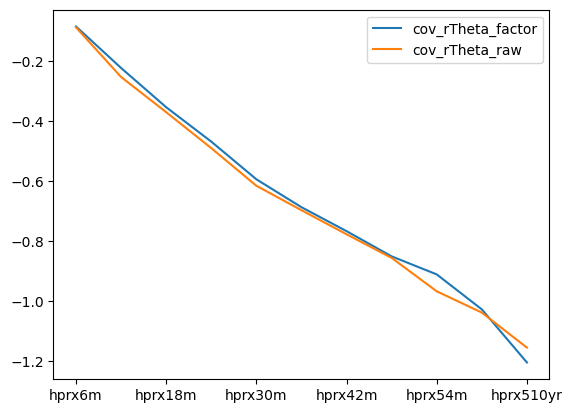

In [46]:
Loadings[['cov_rtheta','cov_rtheta_raw']]
Loadings[['cov_rtheta','cov_rtheta_raw']].plot()
plt.legend(['cov_rTheta_factor', 'cov_rTheta_raw'])
#save figure
plt.savefig(draft_path+'cov_rTheta.pdf')

#### Estimating the factor autoregression $f_t$


$$f_{t} =\alpha_{f} +\sigma_{f}\varepsilon_{f, t}$$


In [47]:
macrodata['factor_lag'] = macrodata['factor'].shift()

data = macrodata[(macrodata.index.year > start_year)
                 & (macrodata.index.year < end_year)]
sel = (pd.notnull(data['factor'])) & (pd.notnull(data['factor_lag']))

Y = data[sel].factor
X = data[sel][['cons']]
model = sm.OLS(Y[lag:], X[lag:])
results = model.fit()
print(results.summary())

Loadings['rho_factor'] = 0
Loadings['kappa_factor'] = 0
Loadings['se_rho_factor'] = np.NaN
Loadings['se_kappa_factor'] = np.NaN

Loadings['alpha_factor'] = results.params.cons
Loadings['se_alpha_factor'] = results.bse.cons


Loadings['sigma_factor'] = results.resid.var()
# check with leo
#Loadings['sigma_factor_se'] = np.sqrt(2*(Y.var())**2/(len(Y)-1))
Loadings['sigma_factor_se'] = np.sqrt(2*(results.resid.var())**2/(len(Y)-1))

Loadings["R2_factor"] = results.rsquared


                            OLS Regression Results                            
Dep. Variable:                 factor   R-squared:                      -0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Wed, 20 Nov 2024   Prob (F-statistic):                nan
Time:                        15:59:36   Log-Likelihood:                -887.60
No. Observations:                 254   AIC:                             1777.
Df Residuals:                     253   BIC:                             1781.
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
cons           0.0238      0.501      0.047      0.9

### $\Sigma^{-1}$ using factor model
Now we contstruct the following inverse of covariance matrix: $\Pi_f=\Pi(\Delta,\kappa_f,\sigma^2_f)$ which is the inverse computed using the factor loadings $\kappa$ and $\Delta=diag\{\sigma^2_k\}$ 
 
 $$\Pi(\Delta,\kappa_f,\sigma^2_f)=(\sigma^2_f \kappa_f \kappa_f^{\intercal} + \Delta)^{-1}= \Delta^{-1}- \frac{\Delta^{-1}\kappa_f\kappa_f^{\intercal}\Delta^{-1} }{\frac{1}{\sigma^2_f} +\kappa_f^{\intercal} \Delta^{-1}\kappa_f }$$

In [48]:
Delta=np.diag(Loadings.sigma2.values)
def getPi(Delta,kappa,sigma2_f):
    invDelta=np.linalg.inv(Delta)
    term1=np.matmul(invDelta,kappa)
    term2=np.matmul(kappa,term1)
    Sigma=sigma2_f*np.outer(kappa,kappa) +Delta
    Pi=invDelta-np.outer(term1,term1)/((1.0/sigma2_f)+term2)
    return Pi,Sigma    
Pi,Sigma=getPi(Delta,kappa,data.factor.var())
#pd.options.display.float_format = '{:.2f}'.format


### Estimates with interpolation 

We estimate $\delta_j$ and $\sigma^2_j$ by fitting a following function 
$$f(j)=a-a\exp(-b \times j) $$

We fit $a$ and $b$ to minimize sum of squares betwen fitted and actual values of delta and sigma2

In [49]:
initial_guess = [0.3, .1]
resultkappa = optimize.minimize(lambda x:np.sum ((Loadings.kappa_f-(x[0]-x[0]*np.exp(-x[1]*Loadings.maturities.values)) )**2) , initial_guess,method='Nelder-Mead')
print("a and b for kappa" )
resultkappa.x
func_kappa = lambda n: resultkappa.x[0]-resultkappa.x[0]*np.exp(-resultkappa.x[1]*n)

resultsigma = optimize.minimize(lambda x:np.sum ((Loadings.sigma2-(x[0]-x[0]*np.exp(-x[1]*Loadings.maturities.values)))**2) , initial_guess,method='Nelder-Mead')
print("a and b for sigma2" )
resultsigma.x
func_sigma2 = lambda n: resultsigma.x[0]-resultsigma.x[0]*np.exp(-resultsigma.x[1]*n)
func_sigma2_raw =func_sigma2



resultalpha = optimize.minimize(lambda x:np.sum ((Loadings.alpha-(x[0]-x[0]*np.exp(-x[1]*Loadings.maturities.values)))**2) , initial_guess,method='Nelder-Mead')
print("a and b for alpha" )
resultalpha.x
func_alpha = lambda n: resultalpha.x[0]-resultalpha.x[0]*np.exp(-resultalpha.x[1]*n)


a and b for kappa


array([0.51859614, 0.05293846])

a and b for sigma2


array([0.36583394, 0.23032915])

a and b for alpha


array([0.40362272, 0.13721219])

In [50]:

maturities= Loadings.maturities
maturities_finer=np.linspace(2,N*4+1,N*4)
kappa_finer=np.zeros(len(maturities_finer))
alpha_finer=np.zeros(len(maturities_finer))

sigma2_finer=np.zeros(len(maturities_finer))
sigma2_raw_finer=np.zeros(len(maturities_finer))

#func_kappa = interp1d(maturities, Loadings.kappa_f.values,kind='linear',fill_value='extrapolate')
#func_alpha = interp1d(maturities, Loadings.alpha.values,kind='linear',fill_value='extrapolate')
#func_sigma2 = interp1d(maturities, Loadings.sigma2.values,kind='linear',fill_value='extrapolate')
#func_sigma2_raw = interp1d(maturities, Loadings.sigma2_raw.values,kind='linear',fill_value='extrapolate')

#func_kappa = lambda n: 0.1505*np.log(n)-0.0209
#func_sigma2 = lambda n: 0.1245*np.log(n)-0.0975


In [51]:


for n in maturities_finer:
    kappa_finer[int(n)-2]=func_kappa(n)
    alpha_finer[int(n)-2]=func_alpha(n)
    sigma2_finer[int(n)-2]=func_sigma2(n)        
    sigma2_raw_finer[int(n)-2]=func_sigma2_raw(n)




Delta_finer = np.diag(sigma2_finer)
Pi_finer, Sigma_finer = getPi(Delta_finer, kappa_finer, data.factor.var())
Loadings_finer = pd.DataFrame([maturities_finer, alpha_finer, kappa_finer,
                              sigma2_finer, sigma2_raw_finer]).T
Loadings_finer.columns = ['maturities', 'alpha',
                          'kappa_f', 'sigma2', 'sigma2_raw']
#N = Loadings_finer.maturities
Loadings_finer = Loadings_finer.set_index("maturities")


In [52]:
Original_points = pd.DataFrame()
Original_points["maturities"] = maturities_finer-2
for k in ["kappa_f", "alpha", "sigma2", "sigma2_raw"]:
    Original_points["{}".format(k)] = np.zeros(len(maturities_finer))
    Original_points["{}".format(k)] = np.nan
    l = 0
    for j in maturities-2:
        Original_points.loc[j, "{}".format(
            k)] = Loadings["{}".format(k)].values[l]
        l = l+1
Original_points["maturities"] = Original_points["maturities"]+2
Original_points = Original_points.loc[0:len(maturities_finer)-2, :]
Original_points.set_index("maturities", inplace=True)


### Fit for $\kappa_j$

Text(0.5, 0, 'Maturity, quarters')

(0.0, 40.0)

(0.0, 0.5)

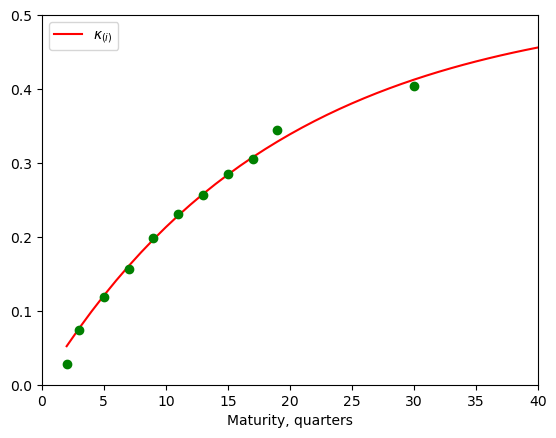

In [53]:

fig, ax = plt.subplots()
ax.set_prop_cycle(color=['red', 'green', 'blue'])
#plt.plot(Loadings_finer[['sigma2', 'kappa_f', 'cov_rX']])

#plt.plot(Original_points[['sigma2', 'kappa_f', 'cov_rX']],
#         'o')

plt.plot(Loadings_finer[[ 'kappa_f']])

plt.plot(Original_points[['kappa_f']],
         'o')

plt.xlabel("Maturity, quarters")

plt.legend([r"$\kappa_{\left(i\right)}$"])


plt.xlim(0, 40)
plt.ylim(0, .5)
plt.savefig(draft_path+"fit_kappa.png")

### Fit for $\sigma^2_j$

Text(0.5, 0, 'Maturity, quarters')

(0.0, 40.0)

(0.0, 0.5)

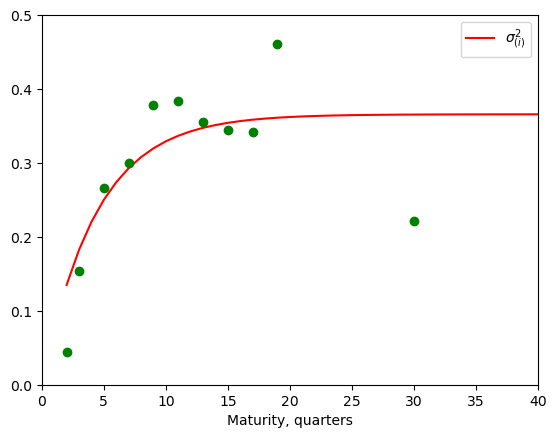

In [54]:

fig, ax = plt.subplots()
ax.set_prop_cycle(color=['red', 'green', 'blue'])
#plt.plot(Loadings_finer[['sigma2', 'kappa_f', 'cov_rX']])

#plt.plot(Original_points[['sigma2', 'kappa_f', 'cov_rX']],
#         'o')

plt.plot(Loadings_finer[[ 'sigma2']])

plt.plot(Original_points[['sigma2']],
         'o')

plt.xlabel("Maturity, quarters")

plt.legend([r"$\sigma_{\left(i\right)}^{2}$"])

plt.xlim(0, 40)
plt.ylim(0, .5)
plt.savefig(draft_path+"fit_sigma.png")

### Fit for $\frac{\kappa_j}{\sigma^2_j}$

Text(0.5, 0, 'Maturity, quarters')

(0.0, 40.0)

(0.0, 2.0)

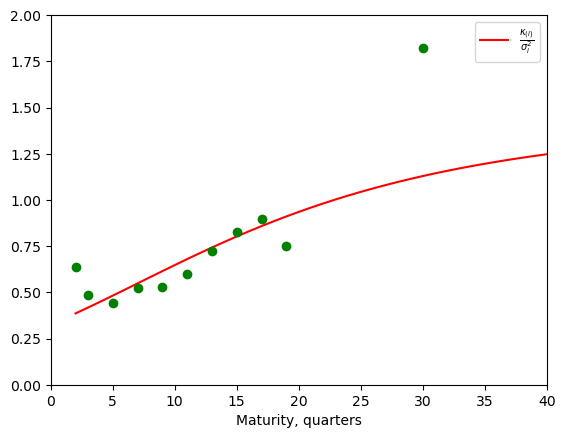

In [55]:

fig, ax = plt.subplots()
ax.set_prop_cycle(color=['red', 'green', 'blue'])
#plt.plot(Loadings_finer[['sigma2', 'kappa_f', 'cov_rX']])

#plt.plot(Original_points[['sigma2', 'kappa_f', 'cov_rX']],
#         'o')

plt.plot(Loadings_finer[ 'kappa_f']/Loadings_finer[ 'sigma2'])

plt.plot(Original_points['kappa_f']/Original_points['sigma2'],
         'o')

plt.xlabel("Maturity, quarters")

plt.legend([r"$\frac{\kappa_{\left(i\right)}}{\sigma^2_{i}}$"])

plt.xlim(0, 40)
plt.ylim(0, 2)
plt.savefig(draft_path+"fit_kappa_over_sigma.png")

### Optimal fiscal hedging portfolio
* The fiscal hedging portfolio is $\mathbf{\omega}_{T}^{\theta}+\mathbf{\omega}_{T}^{G}$ where

    $$\omega^\theta_T= \frac{T^*_T}{Q^{rf}_T B_T} \sigma^2_f \kappa_\theta \sum_{k} (Q^k_T\Gamma^k )  \Sigma^{-1}_T \mathbf{\kappa}_{(r)}$$

    $$\omega^G_T= - \frac{G_T}{Q^{rf}_T B_T} \sigma^2_f \kappa_G \sum_{k} (Q^k_T\Gamma^k )  \Sigma^{-1}_T \mathbf{\kappa}_{(r)}$$


<Axes: xlabel='maturities'>

Sum of hedging - portfolios = omega_h_theta   -0.3966
omega_h_G        0.1991
omega_h         -0.1975
dtype: float64


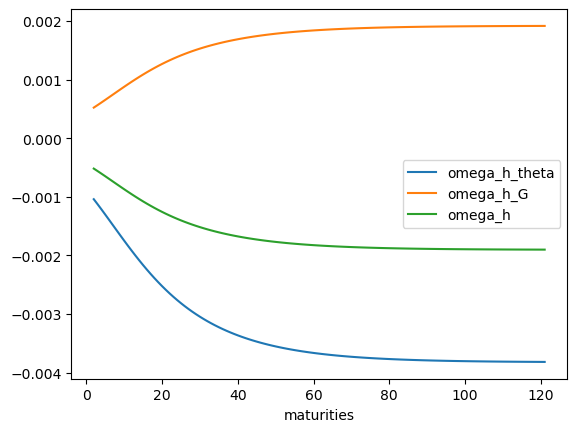

In [56]:
Qrf=QT(1)
omega_h_theta_finer=(1/(Qrf* B_T ))*( Upsilon_T *kappa_theta / (1-  beta_hat) -  0*G_T *kappa_G / (1-  beta_hat) )*np.matmul(Pi_finer,kappa_finer)*sigma2_f
omega_h_G_finer=(1/(Qrf* B_T ))*( 0*Upsilon_T *kappa_theta / (1-  beta_hat) -  G_T *kappa_G / (1-  beta_hat) )*np.matmul(Pi_finer,kappa_finer)*sigma2_f


omega_h_finer=(1/(Qrf* B_T ))*( Upsilon_T *kappa_theta / (1-  beta_hat) -  G_T *kappa_G / (1-  beta_hat) )*np.matmul(Pi_finer,kappa_finer)*sigma2_f

Loadings_finer['omega_h']=omega_h_finer
Loadings_finer['omega_h_theta']=omega_h_theta_finer
Loadings_finer['omega_h_G']=omega_h_G_finer

Loadings_finer[['omega_h_theta','omega_h_G','omega_h']].plot()

print("Sum of hedging - portfolios = "+ str(Loadings_finer[['omega_h_theta','omega_h_G','omega_h']].sum()))

### Optimal interest risk portfolio


#### Construct $\Sigma^Q$ 

In [57]:

def  get_SigmaInfty():
    Nm=N*4*4
    maturities= Loadings.maturities
    maturities_finer=np.linspace(2,Nm+1,Nm)
    kappa_finer=np.zeros(len(maturities_finer))
    alpha_finer=np.zeros(len(maturities_finer))

    sigma2_finer=np.zeros(len(maturities_finer))
    sigma2_raw_finer=np.zeros(len(maturities_finer))

    for n in maturities_finer:
            kappa_finer[int(n)-2]=func_kappa(n)
            alpha_finer[int(n)-2]=func_alpha(n)
            sigma2_finer[int(n)-2]=func_sigma2(n)        
            sigma2_raw_finer[int(n)-2]=func_sigma2_raw(n)


    Delta_finer = np.diag(sigma2_finer)
    Pi_finer, Sigma_finer = getPi(Delta_finer, kappa_finer, data.factor.var())
    np.save('Sigma_finer_tt.npy', Sigma_finer)
    np.save('maturities_finer_tt.npy', maturities_finer)
    np.save('alpha_finer_tt.npy', alpha_finer)
    np.save('kappa_finer_tt.npy', kappa_finer)
           

get_SigmaInfty()

In [58]:
SigmaInfinity = np.load('Sigma_finer_tt.npy')
maturitiesInfinity = np.load('maturities_finer_tt.npy')
alphaInfinity = np.load('alpha_finer_tt.npy')
kappaInfinity = np.load('kappa_finer_tt.npy')

sQ=np.zeros(len(maturitiesInfinity))
for k in range(len(maturitiesInfinity)):
    sQ[k]=QT(k+1)*Gamma**(k+1)


SigmaQ = SigmaInfinity[:len(maturities_finer), :]

W =  (1-beta_hat)*np.matmul(np.matmul(Pi_finer, SigmaQ),sQ)
Loadings_finer['omega_r_fin'] = W
Loadings_finer['omega_r_beta'] = (1-beta_hat)*beta_hat**(maturitiesInfinity[:len(maturities_finer)]-1 )
Loadings_finer['omega_r_QGamma'] = sQ[:len(maturities_finer)]*(1-beta_hat) # check this


print("Sum of Q- portfolio = "+ str(Loadings_finer['omega_r_fin'].sum()))
Loadings_finer['omega_r_fin'].sum()
Loadings_finer["Q"]=[QT(mat) for mat in Loadings_finer.index]


Sum of Q- portfolio = 1.0167785863634644


1.0167785863634644

In [59]:
len(maturities_finer)

120

<Axes: xlabel='maturities'>

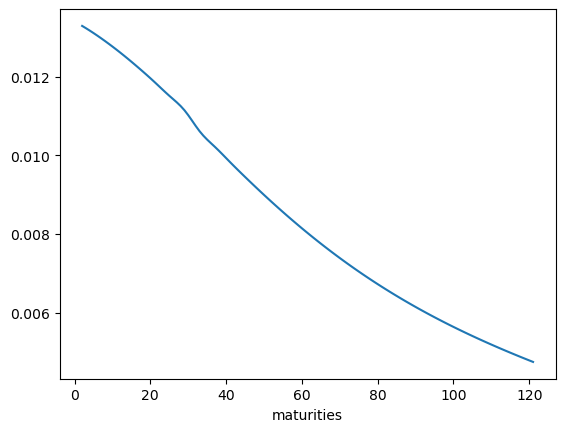

In [60]:
Loadings_finer['omega_r_fin'].plot()

<Axes: xlabel='maturities'>

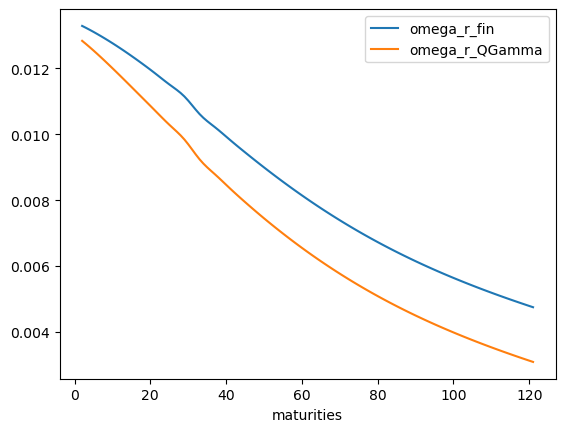

In [61]:
Loadings_finer[['omega_r_fin','omega_r_QGamma']].plot()

### sum of fiscal+hedging portfolio


<Axes: xlabel='maturities'>

fraction in the risk free bond


0.18075674021825294

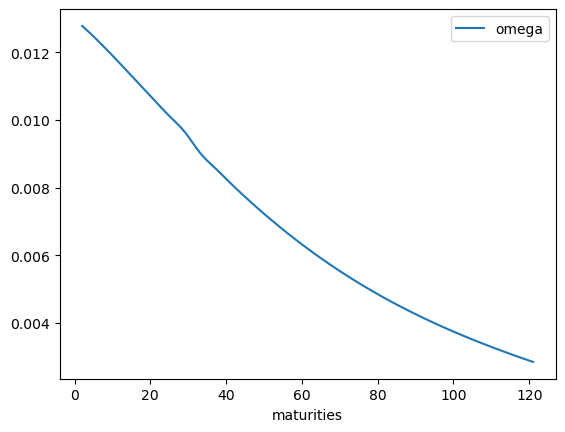

In [62]:
Loadings_finer['omega'] = Loadings_finer['omega_h'] + \
    Loadings_finer['omega_r_fin']
Loadings_finer[['omega']].plot()
print("fraction in the risk free bond")
1-Loadings_finer['omega'].sum()

Loadings_finer['omega_flipped'] = -Loadings_finer['omega_h'] + \
    Loadings_finer['omega_r_fin']

Loadings_finer.to_csv('Loadings_finer_finite.csv')


In [63]:
Loadings_finer[["omega","omega_h","omega_r_fin"]].sum()

omega          0.8192
omega_h       -0.1975
omega_r_fin    1.0168
dtype: float64

### Figure 2: TARGET PORTFOLIO, COMPONENTS, AND U.S.

In [64]:
temp=[]
usdata=(pd.read_csv('../Data/omega_2017.csv').set_index('tmduratn_bin')/100)
temp=pd.DataFrame(np.ones(len(Loadings_finer.index)+1))
temp.index=range(1,len(maturities_finer)+2)
temp["omega capped"]=0
temp["omega_X"]=0
temp["omega_Q"]=0
temp["omega MF"]=0
temp["omega_US"]=0
temp["omega_QGamma"]=0

temp["(1-beta)beta^j"]=0


temp.loc[1:len(usdata),"omega_US"]=(pd.read_csv('../Data/omega_2017.csv').set_index('tmduratn_bin')/100)
temp["omega_US"]=temp["omega_US"].fillna(0)
temp.loc[2:,"omega capped"]=Loadings_finer.omega.values
temp.loc[2:,"omega_X"]=Loadings_finer.omega_h.values
temp.loc[2:,"(1-beta)beta^j"]=Loadings_finer.omega_r_beta.values
temp.loc[1,"omega capped"]=1-np.sum(Loadings_finer.omega.values)
temp.loc[2:,"omega_G"]=Loadings_finer.omega_h_G.values
temp.loc[2:,"omega_theta"]=Loadings_finer.omega_h_theta.values
temp.loc[2:,"omega_Q"]=Loadings_finer.omega_r_fin.values
temp.loc[2:,"QGamma"]=Loadings_finer.omega_r_QGamma.values
temp.loc[2:,"omega flipped"]=Loadings_finer.omega_flipped.values





In [65]:
temp.to_csv("Loadings_finer_finite.csv")

<Axes: >

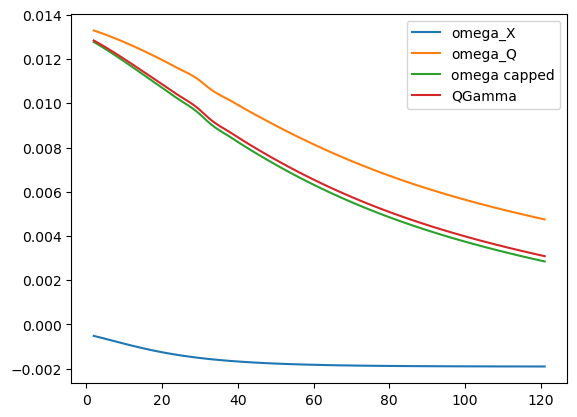

In [66]:
temp[temp.index>1][["omega_X","omega_Q","omega capped","QGamma"]].plot()

In [67]:
def plot_fig(columns=["omega capped", 'omega_US', 'omega_Q', 'omega_X'], name='u',
            leg=[r"target portfolio",
                 r"U.S. portfolio", r"$\left(1-\hat{\beta}\right)\mathtt{\overrightarrow{\beta}}$", 
                 r"$\left(1-\hat{\beta}\right)\mathtt{\overrightarrow{\beta}}$"],
            T=len(temp),
            Max_y=6.0,
             col=['darkred', 'black', 'darkseagreen'],
            marker=['None' ,'None', 'None'],
            markersize=['3','1','2'],linestyle=['--', '-', '-']):
               fig, ax = plt.subplots()
               cycler = plt.cycler(linestyle=linestyle,marker=marker,markersize=markersize)
               #ax.set_prop_cycle(cycler)
               fig     = (temp[columns]*100).plot(lw=1,color=col,ax=ax).get_figure()
               columns = [x.replace('omega_', '') for x in columns]
               columns = [x.replace('gr', 'base') for x in columns]
               leg     = leg
               fig.set_dpi(200)
               plt.xlim(2, T)
               plt.ylim(-.5, Max_y)
               plt.xlabel("Maturity, quarters")
               plt.ylabel("Portfolio share, percent")
               plt.legend(leg)
               fig.savefig(draft_path+"{}.pdf".format(name))

               return fig


In [68]:
def plot_fig(
    columns=["omega capped", 'omega_US', 'omega_Q', 'omega_X'], 
    name='u',
    leg=[
        r"target portfolio",
        r"U.S. portfolio", 
        r"$\left(1-\hat{\beta}\right)\mathtt{\overrightarrow{\beta}}$", 
        r"$\left(1-\hat{\beta}\right)\mathtt{\overrightarrow{\beta}}$"
    ],
    T=None,
    Max_y=6.0,
    col=['darkred', 'black', 'darkseagreen'],
    marker=['None', 'None', 'None'],
    markersize=['3', '1', '2'],
    linestyle=['--', '-', '-.'],
    alpha=[0.5, 0.6, 0.7]
):
    # Create a copy of the data to avoid modifying the original DataFrame
    data_to_plot = temp[columns].copy() * 100

    if T is None:
        T = len(temp)

    fig, ax = plt.subplots()

    # Iterate over each column and plot with specified alpha
    for i, col_name in enumerate(columns):
        ax.plot(
            data_to_plot[col_name],  # Use the copied data
            color=col[i % len(col)], 
            lw=1, 
            linestyle=linestyle[i % len(linestyle)], 
            marker=marker[i % len(marker)], 
            markersize=float(markersize[i % len(markersize)]),
            alpha=alpha[i % len(alpha)]
        )
    
    columns = [x.replace('omega_', '') for x in columns]
    columns = [x.replace('gr', 'base') for x in columns]
    leg = leg
    
    fig.set_dpi(200)
    plt.xlim(2, T)
    plt.ylim(-0.5, Max_y)
    plt.xlabel("Maturity, quarters")
    plt.ylabel("Portfolio share, percent")
    plt.legend(leg)
    fig.savefig(draft_path + "{}.pdf".format(name))

    return fig


#### Figure 2 (b):  COMPONENTS

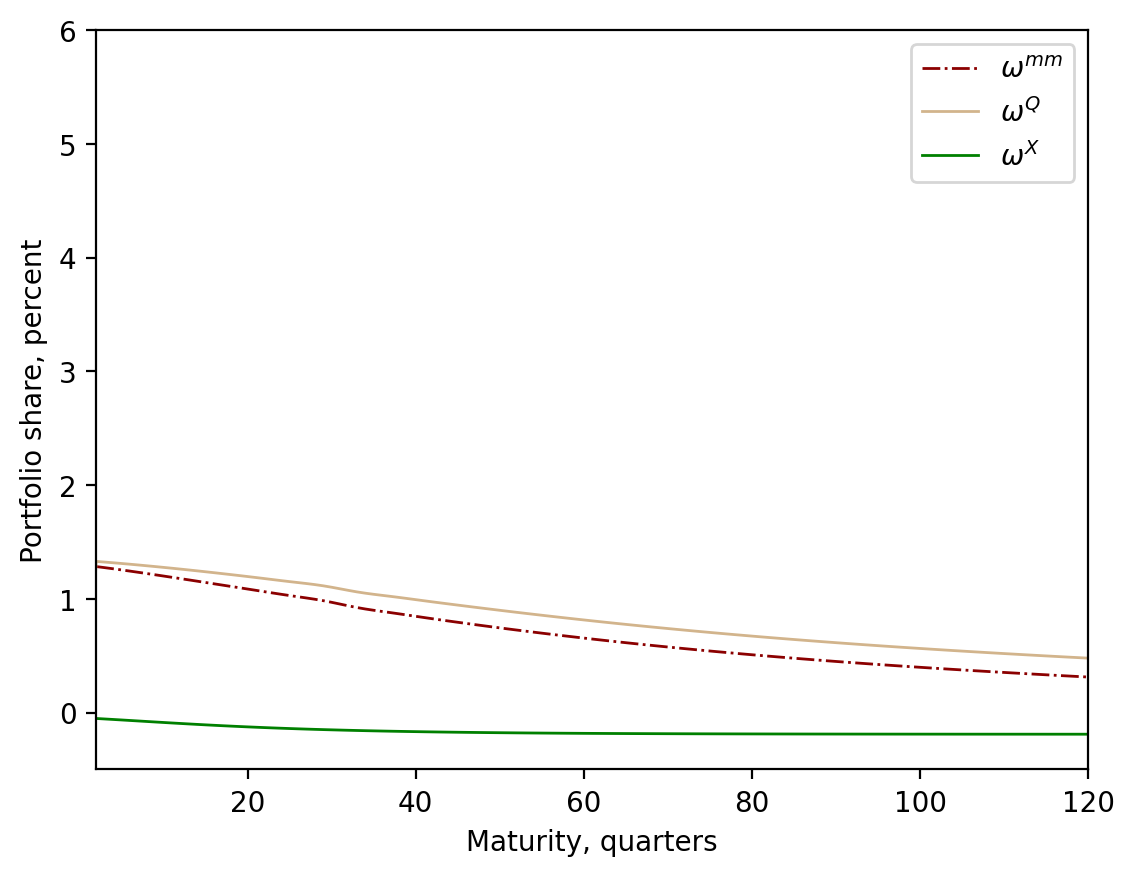

In [69]:
main_3components = plot_fig(name='main_comp', T=len(maturities_finer), Max_y=6,marker=['None', 'None', 'None'],markersize=['2','1','1'], columns=[
    "QGamma", 'omega_Q', 'omega_X'], leg=[r"$\omega^{mm}$",
                                                     r"$\omega^{Q}$", r"$\omega^{X}$"],col=['darkred', 'tan', 'green'],alpha=[1,1,1],linestyle=['-.', '-', '-' ])


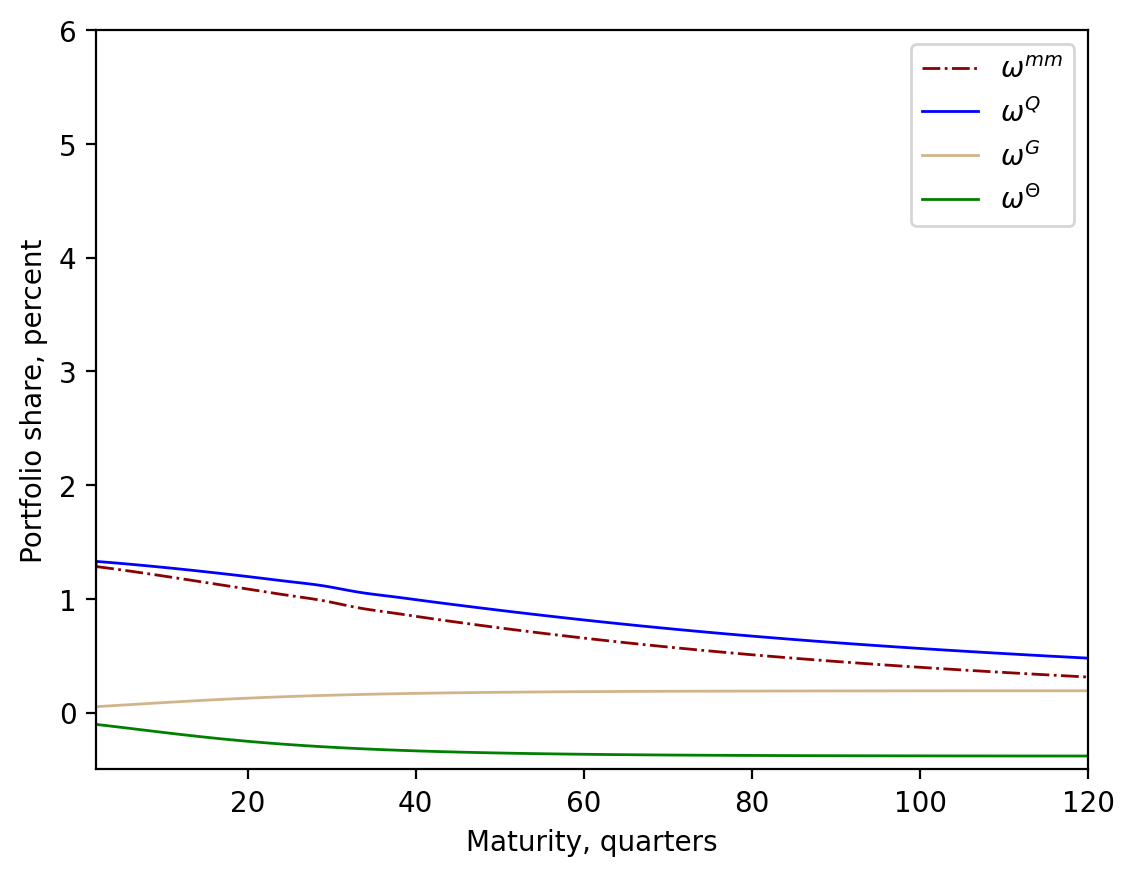

In [70]:
main_3components = plot_fig(name='3comps', T=len(maturities_finer), Max_y=6,marker=['None', 'None', 'None','None'],markersize=['2','1','1','1'], columns=[
    "QGamma","omega_Q", 'omega_G', 'omega_theta'], leg=[r"$\omega^{mm}$",r"$\omega^{Q}$",
                                                     r"$\omega^{G}$", r"$\omega^{\Theta}$"],col=['darkred', 'blue','tan', 'green'],alpha=[1,1,1,1],linestyle=['-.','-', '-', '-' ])


#### Figure 2 (a): US vs Target

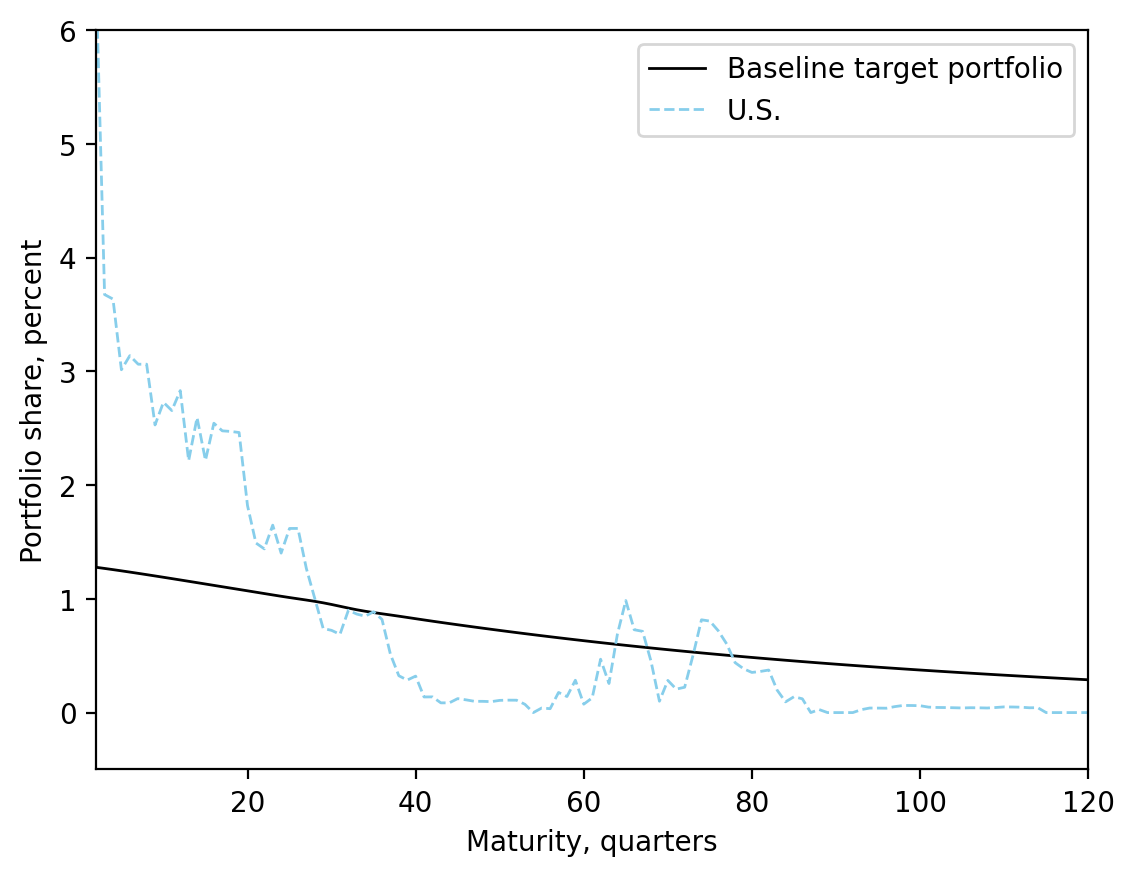

In [71]:
opt_us = plot_fig(name='opt_us', T=len(maturities_finer), marker=['None', 'None'], columns=["omega capped", 'omega_US'], leg=[r"Baseline target portfolio",  r"U.S."], col=['black', 'skyblue'],linestyle=['-', '--'],markersize=['2','1'],alpha=[1,1])

#### Figure with flipped portfolio (for Andy's letter)

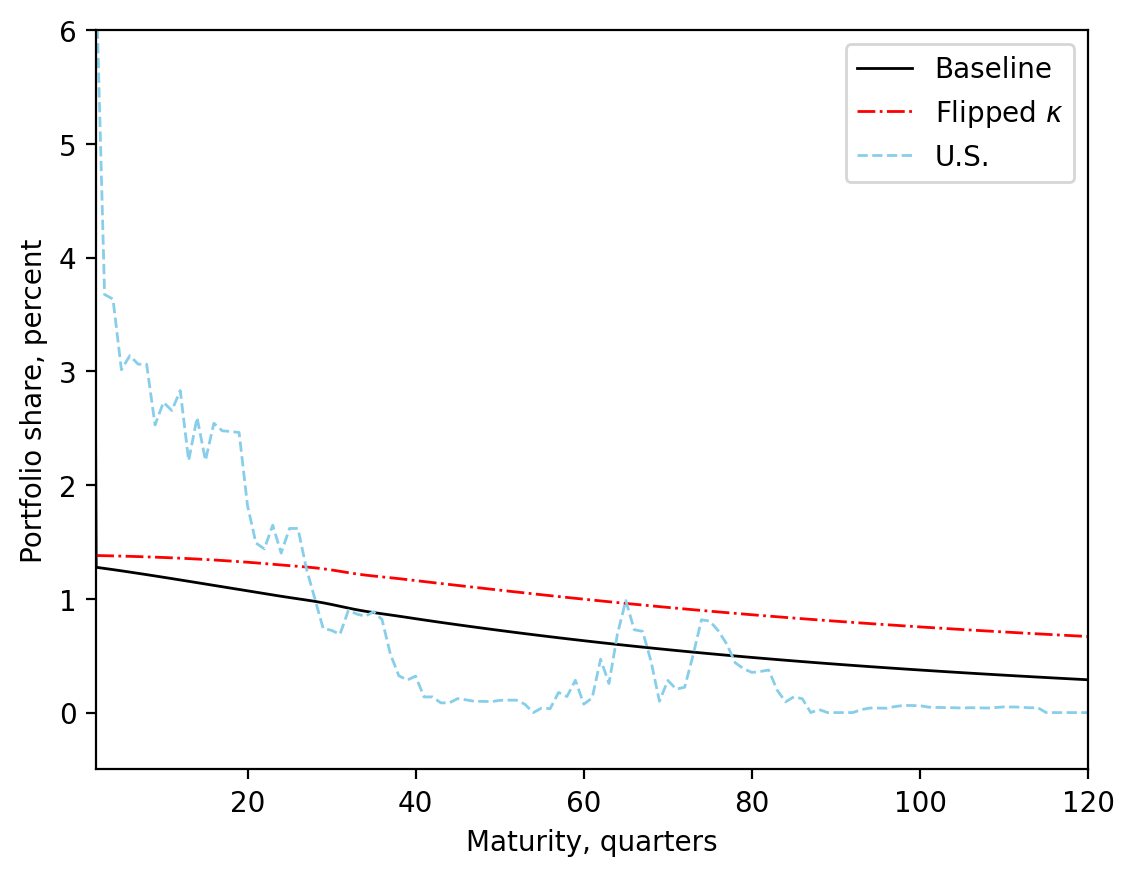

In [72]:
opt_us = plot_fig(name='opt_flipped', T=len(maturities_finer), marker=['None', 'None','None'], columns=["omega capped", 'omega flipped','omega_US'], leg=[r"Baseline",  r"Flipped $\kappa$","U.S."], col=['black', 'red','skyblue'],linestyle=['-','-.', '--'],markersize=['2','1','1'],alpha=[1,1,1])

In [73]:
#sum n*Q_n for n=1 to 120

tembeta=beta_hat
sum_nQn=0
for n in range(2,1000):
    sum_nQn+=n*(tembeta**n)
print(((1-tembeta)*sum_nQn*0.7+0.3)/4)


13.430449938122326


In [74]:
Macaulay=temp.reset_index()

Mc_US=(Macaulay.loc[0:121,'omega_US']*Macaulay.loc[0:121,'index']/4).sum()

Mc_th = (Macaulay['omega capped'] * Macaulay['index'] / 4).sum()
print("Mcaulay US = {}".format(Mc_US))
print("Mcaulay target = {}".format(Mc_th))

Mcaulay US = 5.285136107905255
Mcaulay target = 9.590219889941526


In [75]:
Loadings_finer.to_csv('Loadings_finer.csv')
Loadings.to_csv('Loadings.csv')


### Table 2: FACTOR MODEL ESTIMATION (BASELINE)

In [76]:
Reg_table=Loadings.reset_index(drop=True)
Reg_table['maturities']=Reg_table['maturities']*3
Reg_table.loc[10,'maturities']=120

Reg_table = Reg_table[["maturities",
    "alpha", "se_alpha", "rho", "se_rho", "kappa_f", "se_kappa_f", "sigma2", "std_simga2", "R2"]]





for k in ["G", "theta","factor"]:
    var = '{}'.format(k)
    Reg_table.loc[len(Reg_table.index)] = [var, Loadings["alpha_{}".format(k)][0], Loadings["se_alpha_{}".format(
        k)][0], Loadings["rho_{}".format(k)][0], Loadings["se_rho_{}".format(k)][0], Loadings["kappa_{}".format(k)][0],
        Loadings["se_kappa_{}".format(k)][0], Loadings["sigma_{}".format(k)][0], Loadings["sigma_{}_se".format(k)][0], Loadings["R2_{}".format(k)][0]]

Reg_table = Reg_table.set_index('maturities')
Reg_table[["alpha", "se_alpha", "rho", "se_rho", "kappa_f", "se_kappa_f", "sigma2", "std_simga2", "R2"]] = Reg_table[[
    "alpha", "se_alpha", "rho", "se_rho", "kappa_f", "se_kappa_f", "sigma2", "std_simga2", "R2"]].applymap("{0:.3f}".format)

Reg_table['std_simga2'] = "(" + Reg_table['std_simga2'].apply(str) + ")"
Reg_table['se_alpha'] = "(" + Reg_table['se_alpha'].apply(str) + ")"
Reg_table['se_kappa_f'] = "(" + Reg_table['se_kappa_f'].apply(str) + ")"
Reg_table['se_rho'] = "(" + Reg_table['se_rho'].apply(str) + ")"
Reg_table = Reg_table.T
Reg_table.to_csv(draft_path+'Reg_table_no_adjust.csv')
Reg_table


maturities,6,9,15,21,27,33,39,45,51,57,120,G,theta,factor
alpha,0.086,0.155,0.220,0.245,0.284,0.315,0.346,0.344,0.372,0.304,0.444,-0.177,-0.151,0.024
se_alpha,(0.014),(0.025),(0.033),(0.035),(0.039),(0.039),(0.038),(0.037),(0.037),(0.043),(0.030),(0.016),(0.008),(0.501)
rho,-0.107,-0.057,-0.041,-0.043,-0.042,-0.025,-0.022,-0.008,-0.022,-0.027,0.003,1.000,1.000,0.000
se_rho,(0.043),(0.035),(0.030),(0.025),(0.023),(0.020),(0.018),(0.016),(0.015),(0.015),(0.009),(nan),(nan),(nan)
kappa_f,0.028,0.074,0.118,0.157,0.199,0.230,0.257,0.285,0.306,0.345,0.404,-0.032,-0.047,0.000
se_kappa_f,(0.002),(0.003),(0.004),(0.004),(0.005),(0.005),(0.005),(0.005),(0.005),(0.005),(0.004),(0.016),(0.008),(nan)
sigma2,0.044,0.154,0.267,0.300,0.378,0.384,0.356,0.345,0.341,0.460,0.222,4.232,1.146,63.753
std_simga2,(0.004),(0.014),(0.024),(0.027),(0.034),(0.034),(0.031),(0.031),(0.030),(0.041),(0.020),(0.375),(0.101),(5.657)
R2,0.536,0.698,0.771,0.840,0.870,0.898,0.922,0.938,0.946,0.943,0.979,0.015,0.109,-0.000


### Understanding the components of the optimal portfolio

In [77]:
pi_X=(1/beta_hat)*(1/Qrf*B_T)
kappa_x=kappa_theta*Upsilon_T-kappa_G*G_T
kappa_infty=kappa_finer[-1]

comp_table=pd.DataFrame()
comp_table["Capped"]=[temp["omega capped"][1:len(temp)].sum(),1-temp["omega capped"][1:len(temp)].sum(),temp["omega_X"][1:len(temp)].sum(),temp["omega_Q"][1:len(temp)].sum()]
comp_table[""]=["sum omega","r_f share","sum of omega X","sum of omega Q"]
comp_table=comp_table.set_index("")

sum_th=beta_hat/(1-beta_hat)*((1-beta_hat+pi_X*kappa_x/kappa_infty))
sum_X=beta_hat/(1-beta_hat)*((pi_X*kappa_x/kappa_infty))
sum_Q=beta_hat/(1-beta_hat)*(1-beta_hat)

comp_table["Unrestricted"]=[sum_th,1-sum_th,sum_X,sum_Q]
comp_table.to_csv("portoflio_sums_emp_th.csv")
comp_table

,Capped,Unrestricted
,,
sum omega,0.8192,-1.8696
r_f share,0.1808,2.8696
sum of omega X,-0.1975,-2.8567
sum of omega Q,1.0168,0.9871


## 2. Extension: Predictability
Lets add a transitory shock to government spending. This shock occurs at date $T$ and dies off at some rate $\rho_GTr$. To implement the new formulas we need to recompute two things

* optimal tax rate: $\tau^*_T$
* optimal weights for the fiscal hedging term

$$\mathbf{s}_{T}^{G}[k]=\frac{Q_{T}^{k}\left(\Gamma^{G}\right)^{k}}{Q_{T}^{rf}}\frac{G_{T}\left(G^{tr}_{T}\right)^{\left(1-\rho_{GTr}^{k}\right)}}{B_{T}}$$
* optimal weights on the interest rate risk

$$
\mathbf{s}_{T}^{Q}[k-1]=\frac{Q_{T}^{k}\left(\Gamma\right)^{k}\left(T_{T}^{*}-G_{T}\left(G^{tr}_{T}\right)^{\left(1-\rho_{GTr}^{k}\right)}\right)}{Q_{T}^{rf}\sum\left(Q_{T}^{k}\left(\Gamma\right)^{k}\left(T_{T}^{*}-G_{T}\left(G^{tr}_{T}\right)^{\left(1-\rho_{GTr}^{k}\right)}\right)\right)}
$$



In [78]:
def beta_tilde(QT,length=len(maturitiesInfinity)):
    beta = np.zeros(length)
    for t in range(length):
        beta[t] = QT(t+1)*Gamma**(t+1)
    return beta

In [79]:
def taustar(G_Tr_T,rho_GTr,QT,tau_T,G_T,B_T,Gamma,gamma, N=500):

    def res_tau(tau):
        ln_g_trans = np.log(G_Tr_T)

        LHS=tau*(1-tau)**(1-gamma)
        PVG=0
        PVTheta=0
        for t in range(1,N):
            PVG+=QT(t)*Gamma**(t)*G_T*G_Tr_T**(1-rho_GTr**(t)) 
            PVTheta+=QT(t)*Gamma**(t)*(1-tau_T)**(-gamma)
        RHS=(B_T+PVG)/PVTheta
        return LHS-RHS

    taustar_GTr=optimize.fsolve(res_tau,.15)[0]
    #print("the optimal tau is")
    #print(taustar_GTr)

    #Upsilonstar_GTr=taustar_GTr*(1-tau_T)**(-gamma)*(1-taustar_GTr)**(1-gamma)
    #print("the optimal Upsilon is")
    #print(Upsilonstar_GTr)
    return taustar_GTr

def Upsilonstar_GTr(G_Tr_T,rho_GTr,QT,tau_T,G_T,B_T,Gamma,gamma, N=500):
    taustar_val=taustar(G_Tr_T,rho_GTr,QT,tau_T,G_T,B_T,Gamma,gamma, N)
    return taustar_val*(1-tau_T)**(-gamma)*(1-taustar_val)**(1-gamma)



In [80]:
def sigma_X(G_Tr_T,rho_GTr,QT,tau_T,G_T,B_T,Gamma,gamma):
    Upsilon_T=Upsilonstar_GTr(G_Tr_T,rho_GTr,QT,tau_T,G_T,B_T,Gamma,gamma)
    lnG_Tr_T=np.log(G_Tr_T)
    Sigma_X = np.zeros((len(Loadings_finer[ 'kappa_f'].to_numpy()),len(maturitiesInfinity)))
    for j in range(len(Loadings_finer["kappa_f"].to_numpy())):
        for t in range(len(maturitiesInfinity)):
            Sigma_X[j,t] = Loadings_finer["kappa_f"].to_numpy()[j]*(Upsilon_T*kappa_theta-G_T*np.exp(lnG_Tr_T)**((1- rho_GTr**(t+1)))*(kappa_G))*sigma2_f
    return(Sigma_X@beta_tilde(QT))

the optimal tau is
0.2033026523704287
Sum ofX- portfolio = -0.20722458033285207


<Axes: xlabel='maturities'>

fraction in the risk free bond


omega          0.1808
omega_Tr1075   0.1778
dtype: float64

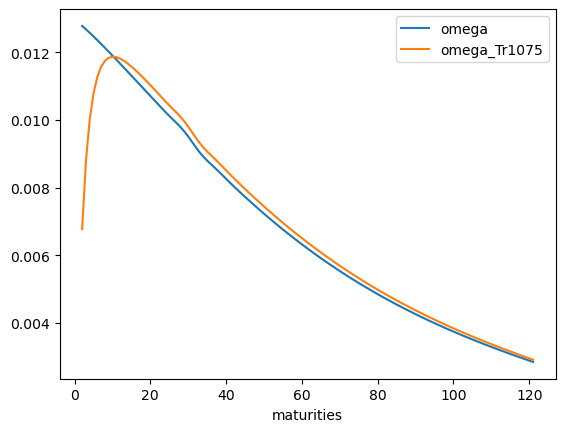

In [81]:
G_Tr_T=np.exp(0.1)
rho_GTr=0.75

taustar_val=taustar(G_Tr_T,rho_GTr,QT=QT,tau_T=0.3,G_T=.15,B_T=4.0,Gamma=1.005,gamma=0.5, N=500)
print("the optimal tau is")
print(taustar_val)


Qrf=QT(1)
omega_h_finer_Tr1075=(1/(Qrf* B_T ))*Pi_finer@sigma_X(G_Tr_T,rho_GTr,QT,tau_T,G_T,B_T,Gamma,gamma)

Loadings_finer['omega_h_Tr1075']=omega_h_finer_Tr1075

print("Sum ofX- portfolio = "+ str(Loadings_finer['omega_h_Tr1075'].sum()))

sQ=np.zeros(len(maturitiesInfinity))
for k in range(len(maturitiesInfinity)):
    sQ[k]=QT(k+1)*Gamma**(k+1)*(Upsilon_T-G_T*G_Tr_T*np.exp(-(1-rho_GTr**(k+1))))
sQ=sQ/(Qrf*np.sum(sQ))


SigmaQ = SigmaInfinity[:len(maturities_finer), :]

W =  np.matmul(np.matmul(Pi_finer, SigmaQ),sQ)
Loadings_finer['omega_r_fin_Tr1075'] = W

Loadings_finer['omega_Tr1075'] = Loadings_finer['omega_h_Tr1075'] + \
    Loadings_finer['omega_r_fin_Tr1075']
Loadings_finer[['omega','omega_Tr1075']].plot()
print("fraction in the risk free bond")
1-Loadings_finer[['omega','omega_Tr1075']].sum()


the optimal tau is
0.22152808218278808
Sum ofX- portfolio = -0.20722458033285207


<Axes: xlabel='maturities'>

fraction in the risk free bond


omega          0.1808
omega_Tr2075   0.1777
dtype: float64

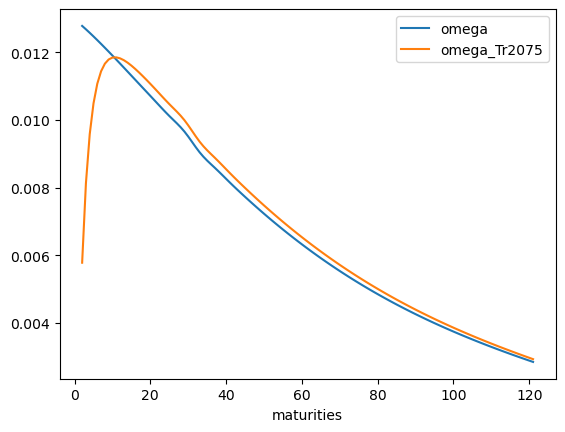

In [82]:
G_Tr_T=np.exp(0.20)
rho_GTr=0.75

taustar_val=taustar(G_Tr_T,rho_GTr,QT=QT,tau_T=0.3,G_T=.15,B_T=4.0,Gamma=1.005,gamma=0.5, N=500)
print("the optimal tau is")
print(taustar_val)


Qrf=QT(1)
omega_h_finer_Tr2075=(1/(Qrf* B_T ))*Pi_finer@sigma_X(G_Tr_T,rho_GTr,QT,tau_T,G_T,B_T,Gamma,gamma)

Loadings_finer['omega_h_Tr2075']=omega_h_finer_Tr1075

print("Sum ofX- portfolio = "+ str(Loadings_finer['omega_h_Tr2075'].sum()))

sQ=np.zeros(len(maturitiesInfinity))
for k in range(len(maturitiesInfinity)):
    sQ[k]=QT(k+1)*Gamma**(k+1)*(Upsilon_T-G_T*G_Tr_T*np.exp(-(1-rho_GTr**(k+1))))
sQ=sQ/(Qrf*np.sum(sQ))


SigmaQ = SigmaInfinity[:len(maturities_finer), :]

W =  np.matmul(np.matmul(Pi_finer, SigmaQ),sQ)
Loadings_finer['omega_r_fin_Tr2075'] = W

Loadings_finer['omega_Tr2075'] = Loadings_finer['omega_h_Tr2075'] + \
    Loadings_finer['omega_r_fin_Tr2075']
Loadings_finer[['omega','omega_Tr2075']].plot()
print("fraction in the risk free bond")
1-Loadings_finer[['omega','omega_Tr2075']].sum()


the optimal tau is
0.2004091487762395
Sum ofX- portfolio = -0.20722458033285207


<Axes: xlabel='maturities'>

fraction in the risk free bond


omega          0.1808
omega_Tr1095   0.1758
dtype: float64

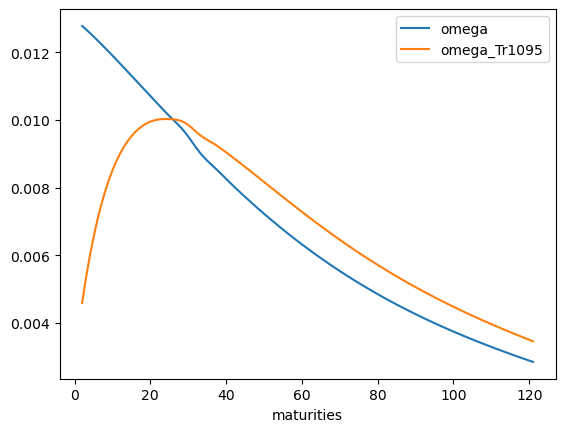

In [83]:

G_Tr_T=np.exp(0.1)
rho_GTr=0.95

taustar_val=taustar(G_Tr_T,rho_GTr,QT=QT,tau_T=0.3,G_T=.15,B_T=4.0,Gamma=1.005,gamma=0.5, N=500)
print("the optimal tau is")
print(taustar_val)


Qrf=QT(1)
omega_h_finer_Tr1095=(1/(Qrf* B_T ))*Pi_finer@sigma_X(G_Tr_T,rho_GTr,QT,tau_T,G_T,B_T,Gamma,gamma)

Loadings_finer['omega_h_Tr1095']=omega_h_finer_Tr1075

print("Sum ofX- portfolio = "+ str(Loadings_finer['omega_h_Tr1095'].sum()))

sQ=np.zeros(len(maturitiesInfinity))
for k in range(len(maturitiesInfinity)):
    sQ[k]=QT(k+1)*Gamma**(k+1)*(Upsilon_T-G_T*G_Tr_T*np.exp(-(1-rho_GTr**(k+1))))
sQ=sQ/(Qrf*np.sum(sQ))


SigmaQ = SigmaInfinity[:len(maturities_finer), :]

W =  np.matmul(np.matmul(Pi_finer, SigmaQ),sQ)
Loadings_finer['omega_r_fin_Tr1095'] = W

Loadings_finer['omega_Tr1095'] = Loadings_finer['omega_h_Tr1095'] + \
    Loadings_finer['omega_r_fin_Tr1095']
Loadings_finer[['omega','omega_Tr1095']].plot()
print("fraction in the risk free bond")
1-Loadings_finer[['omega','omega_Tr1095']].sum()



the optimal tau is
0.21514172772782603
Sum ofX- portfolio = -0.20722458033285207


<Axes: xlabel='maturities'>

fraction in the risk free bond


omega          0.1808
omega_Tr2095   0.1754
dtype: float64

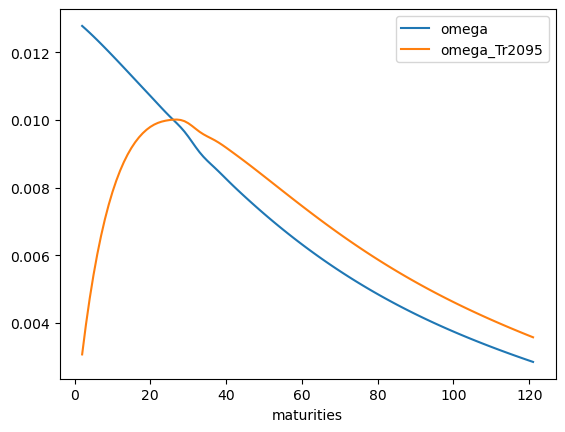

In [84]:

G_Tr_T=np.exp(0.2)
rho_GTr=0.95

taustar_val=taustar(G_Tr_T,rho_GTr,QT=QT,tau_T=0.3,G_T=.15,B_T=4.0,Gamma=1.005,gamma=0.5, N=500)
print("the optimal tau is")
print(taustar_val)


Qrf=QT(1)
omega_h_finer_Tr2095=(1/(Qrf* B_T ))*Pi_finer@sigma_X(G_Tr_T,rho_GTr,QT,tau_T,G_T,B_T,Gamma,gamma)

Loadings_finer['omega_h_Tr2095']=omega_h_finer_Tr1075

print("Sum ofX- portfolio = "+ str(Loadings_finer['omega_h_Tr2095'].sum()))

sQ=np.zeros(len(maturitiesInfinity))
for k in range(len(maturitiesInfinity)):
    sQ[k]=QT(k+1)*Gamma**(k+1)*(Upsilon_T-G_T*G_Tr_T*np.exp(-(1-rho_GTr**(k+1))))
sQ=sQ/(Qrf*np.sum(sQ))


SigmaQ = SigmaInfinity[:len(maturities_finer), :]

W =  np.matmul(np.matmul(Pi_finer, SigmaQ),sQ)
Loadings_finer['omega_r_fin_Tr2095'] = W

Loadings_finer['omega_Tr2095'] = Loadings_finer['omega_h_Tr2095'] + \
    Loadings_finer['omega_r_fin_Tr2095']
Loadings_finer[['omega','omega_Tr2095']].plot()
print("fraction in the risk free bond")
1-Loadings_finer[['omega','omega_Tr2095']].sum()



In [85]:
temp.loc[2:,"omega GTr1075"]=Loadings_finer.omega_Tr1075.values
temp.loc[2:,"omega GTr2075"]=Loadings_finer.omega_Tr2075.values
temp.loc[2:,"omega GTr1095"]=Loadings_finer.omega_Tr1095.values
temp.loc[2:,"omega GTr2095"]=Loadings_finer.omega_Tr2095.values



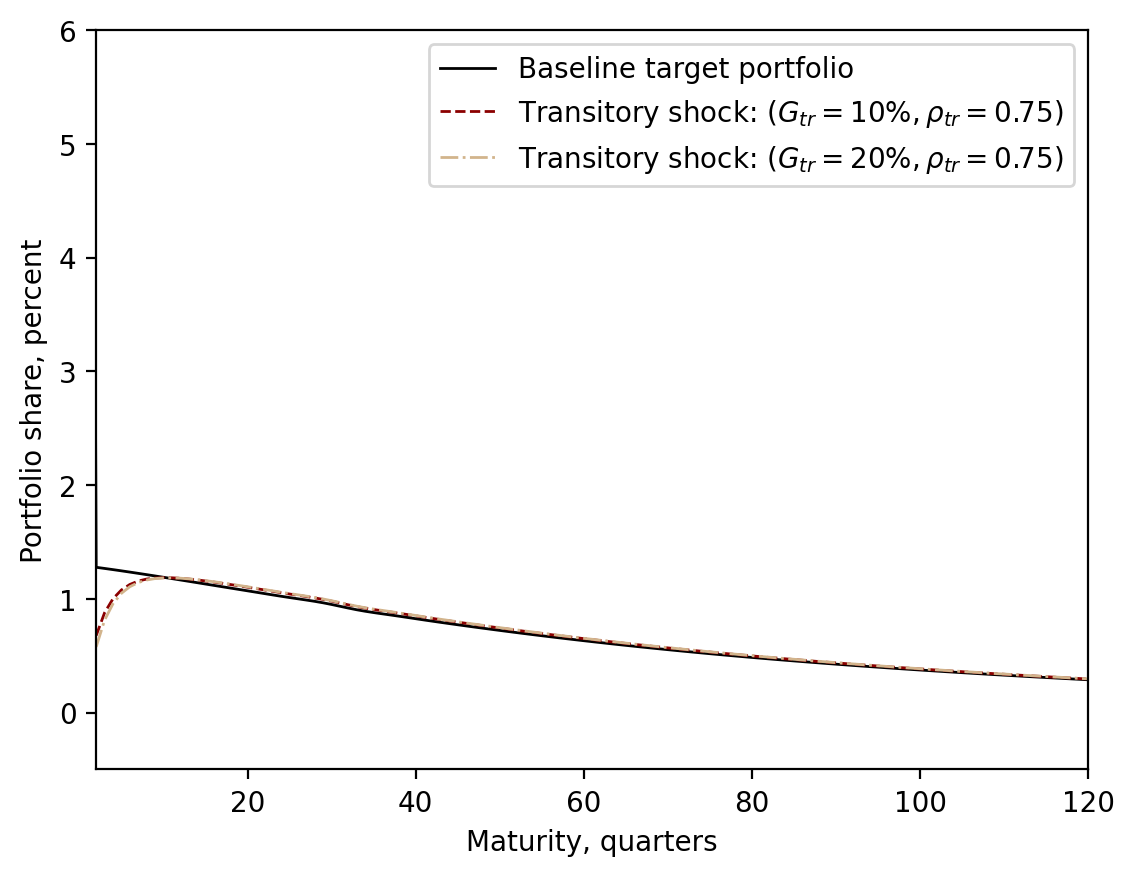

In [86]:
transitory = plot_fig(name='opt_gtr75', T=120, marker=['None', 'None','None'], columns=["omega capped", 'omega GTr1075','omega GTr2075'], leg=[r"Baseline target portfolio",  r"Transitory shock: ($G_{tr}=10\%, \rho_{tr}=0.75$)",r"Transitory shock: ($G_{tr}=20\%, \rho_{tr}=0.75$)"], col=['black', 'darkred','tan'],linestyle=["-","--","-."],markersize=['2','1','1'] ,Max_y=6,alpha=[1,1,1])

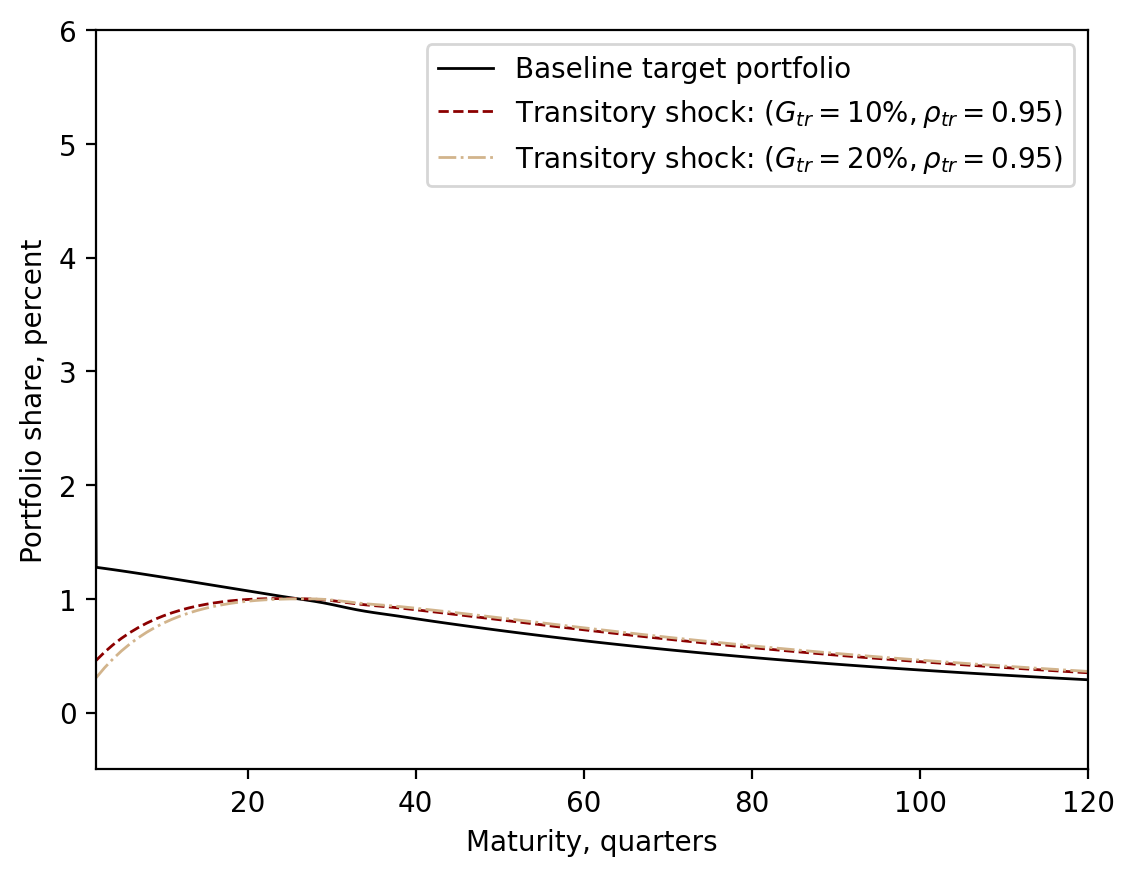

In [87]:
transitory = plot_fig(name='opt_gtr95', T=120, marker=['None', 'None','None'], columns=["omega capped", 'omega GTr1095','omega GTr2095'], leg=[r"Baseline target portfolio",  r"Transitory shock: ($G_{tr}=10\%, \rho_{tr}=0.95$)",r"Transitory shock: ($G_{tr}=20\%, \rho_{tr}=0.95$)"], col=['black', 'darkred','tan'],linestyle=["-","--","-."],markersize=['2','1','1'] ,Max_y=6,alpha=[1,1,1])

##  3. Extension: Household Heterogeneity

<Axes: >

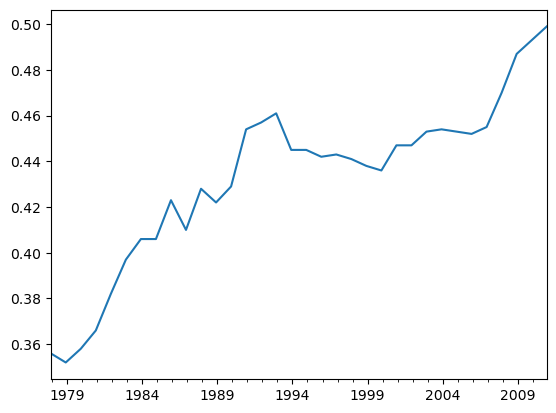

In [88]:
ineqdata=pd.read_csv("../Data/inequality_data.csv")
start_ineq=datetime.date(1977,12,31)
end_ineq=datetime.date(2010,12,31)
ineqdata.set_index(pd.date_range(start=start_ineq,end=end_ineq,freq='12M'),inplace=True)
ineqdata["ineqmeasure"]=-(ineqdata["P25"]-ineqdata["MeanWage"])
ineqdata["ineqmeasure"].plot()

<Axes: >

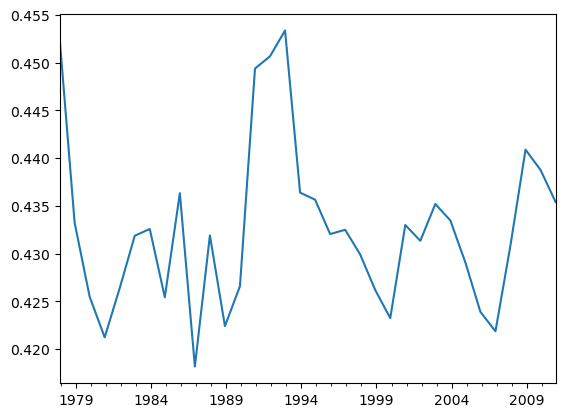

In [89]:
p = np.poly1d(np.polyfit(ineqdata.year.values, ineqdata.ineqmeasure.values,3))
ineqdata["ineqmeasure_trend"]=p(ineqdata.year.values)
ineqdata["ineqmeasure_dt"]=(ineqdata["ineqmeasure"]-ineqdata["ineqmeasure_trend"])+ineqdata["ineqmeasure"].mean()
ineqdata["ineqmeasure_dt"].plot()

<Axes: >

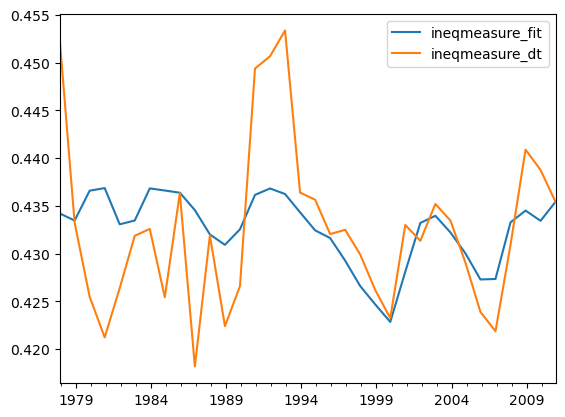

In [90]:
p = np.poly1d(np.polyfit(ineqdata.unrate, ineqdata.ineqmeasure_dt,3))
ineqdata["ineqmeasure_fit"]=p(ineqdata.unrate)
ineqdata[["ineqmeasure_fit","ineqmeasure_dt"]].plot()

<Axes: xlabel='DATE'>

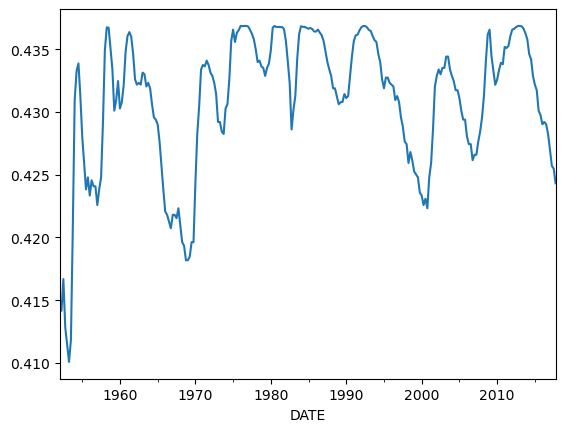

In [91]:
macrodata["ineqmeasure"]=p(macrodata.unemp)
macrodata["ineqmeasure_lag"]=macrodata["ineqmeasure"].shift()
macrodata["ineqmeasure"].plot()

In [92]:

tempineq=ineqdata.ineqmeasure.resample('Q').bfill().reset_index()
tempineq.set_index(tempineq['index'],inplace=True)
#tempineq.ineqmeasure.plot()
p = np.poly1d(np.polyfit(tempineq.index.year.values, tempineq.ineqmeasure.values,3))
tempineq["ineqmeasure_trend"]=p(tempineq.index.year.values)
tempineq["ineqmeasure_dt"]=(tempineq["ineqmeasure"]-tempineq["ineqmeasure_trend"])+tempineq["ineqmeasure"].mean()
#tempineq["ineqmeasure_dt"].plot()

macrodata["ineqmeasure_alt"]=tempineq["ineqmeasure_dt"]
macrodata["ineqmeasure_alt_lag"]=tempineq["ineqmeasure_dt"].shift()

In [93]:
data=macrodata[(macrodata.index.year>start_year)&(macrodata.index.year<end_year) ]
sel=pd.notnull(data['ineqmeasure']) & (pd.notnull(data['factor']) ) & (pd.notnull(data['ineqmeasure']) )
    
Y=data[sel].ineqmeasure
X=data[sel][['cons','ineqmeasure_lag','factor']]
model = sm.OLS(Y[lag:],X[lag:])
results = model.fit()
print (results.summary())

kappa_ineq=results.params.factor*100
rho_ineq=results.params.ineqmeasure_lag


                            OLS Regression Results                            
Dep. Variable:            ineqmeasure   R-squared:                       0.919
Model:                            OLS   Adj. R-squared:                  0.918
Method:                 Least Squares   F-statistic:                     1428.
Date:                Wed, 20 Nov 2024   Prob (F-statistic):          3.40e-138
Time:                        15:59:40   Log-Likelihood:                 1305.6
No. Observations:                 255   AIC:                            -2605.
Df Residuals:                     252   BIC:                            -2595.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
cons                0.0310      0.008     

In [94]:
omega_ineq_finer=(1/(Qrf* B_T ))*( Upsilon_T *kappa_ineq / (1-  rho_ineq*beta_hat)  )*np.matmul(Pi_finer,kappa_finer)*sigma2_f


<Axes: xlabel='maturities'>

Sum of Ineq- portfolio = 0.0034373442879006783


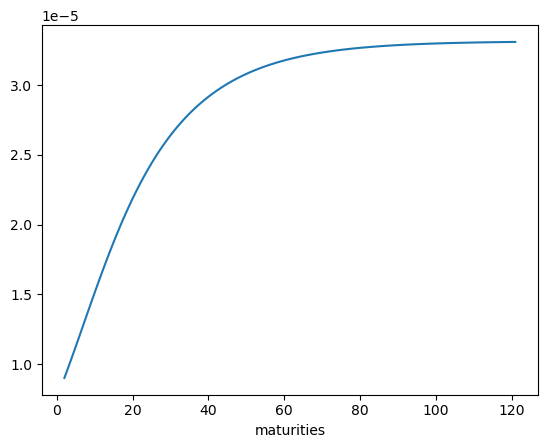

In [95]:
Loadings_finer['omega_ineq']=omega_ineq_finer
Loadings_finer['omega_ineq'].plot()

print("Sum of Ineq- portfolio = "+ str(Loadings_finer['omega_ineq'].sum()))

In [96]:
numerator1= np.dot(alphaInfinity,(beta_hat)**(maturitiesInfinity-1))/100
denominator1=((1-beta_hat/Gamma)**2/(beta_hat/Gamma)) *np.dot(np.matmul((beta_hat)**(maturitiesInfinity-1),SigmaInfinity),(beta_hat)**(maturitiesInfinity-1))/10000
numerator1/denominator1


133.4789088048076

## 4. Extension: Price Effects

$$
\Lambda_{t}[k,j]=\iota_{\{k=j\}}\frac{k\left(Y_{t}\frac{\partial\ln\text{yields}_{t}^{k}}{\partial B_{t}}\right)}{1+k\left(Y_{t}\frac{\partial\ln\text{yields}_{t}^{k}}{\partial B_{t}}\right)\times\left(\omega_{t}^{k}\right)\times\left(\frac{B_{t}}{Y_{t}}\right)}
$$

In [97]:
def getGVestimates(GVData):
    initial_guess = [0.002, .08]
    resultGV = optimize.minimize(lambda x:np.sum ((GVData.estimates-(x[0]-x[0]*np.exp(-x[1]*GVData.maturities.values*2)) )**2) , initial_guess,method='Nelder-Mead')
    print("a and b for GV" )
    resultGV.x
    func_GV = lambda n: (resultGV.x[0]-resultGV.x[0]*np.exp(-resultGV.x[1]*(n**2)))/4
    return func_GV


def getRatioQ(QT, maturities):
    den=np.array([QT(mat) for mat in range(3,len(maturities)+2 ) ])
    num=np.array([QT(mat) for mat in range(2,len(maturities)+1) ])
    ratioQ=np.array([QT(mat+2)/QT(mat+3) for mat in range(len(maturities)-1)])
    return ratioQ

# check this construct
def getLPlusMat(QT,maturities,Gamma):
    ratioQ=getRatioQ(QT, maturities)
    IMat=np.identity(len(maturities))
    LplusMat=np.diag((Gamma)**(-1)*ratioQ)
    LplusMat= np.hstack(( np.zeros(((len(maturities)-1),1 )),LplusMat))
    LplusMat= np.vstack(( LplusMat,np.zeros(((len(maturities)) ))))
    LplusMat[-1,-1]=0.0
    return LplusMat

def getPimat(maturities):
    kappa_finer=np.zeros(len(maturities))
    alpha_finer=np.zeros(len(maturities))
    sigma2_finer=np.zeros(len(maturities))
    sigma2_raw_finer=np.zeros(len(maturities))

    for n in maturities:
            kappa_finer[int(n)-2]=func_kappa(n)
            alpha_finer[int(n)-2]=func_alpha(n)
            sigma2_finer[int(n)-2]=func_sigma2(n)        
            sigma2_raw_finer[int(n)-2]=func_sigma2_raw(n)


    Delta_finer = np.diag(sigma2_finer)
    Pi_finer, Sigma_finer = getPi(Delta_finer, kappa_finer, macrodata.factor.var())
    return Pi_finer


def getPE( maturities,tau_bar,γ,beta_hat,QT,Gamma,GVData):
    dpe =  (-ζ(tau_bar, γ)**2  / ζ_prime(tau_bar, γ))*(1/( (1-  beta_hat)))*(QT(1)**(-2))
    dpe=dpe*(100**2) #convert to natural units
    func_GV=getGVestimates(GVData)
    nmax=40
    funcGVval=func_GV(np.array(range(1,nmax)))
    DataForLambda=(range(1,nmax)/temp.omega_US[1:nmax])*funcGVval*7.3
    #DataForLambda[nmax]=100
    LamMatVal=np.ones(len(maturities_finer))*DataForLambda[nmax]
    LamMatVal[0:len(DataForLambda)]=DataForLambda
    LamMat=np.diag(LamMatVal)
    LambdaRF=func_GV(1)/temp.omega_US[1]
    
    ratioQ=getRatioQ(QT,maturities)
    LplusMat=getLPlusMat(QT,maturities,Gamma)
    IMat=np.identity(len(maturities))
    # compute Y x Lambda x (I-Lplus)
    LamTildeMat = LamMat @ (IMat-LplusMat)
    Pi_finer=getPimat(maturities)
    price_effects_factor_lhs=IMat+ dpe * (Pi_finer @ LamTildeMat)
    #price_effects_factor=np.linalg.inv(IMat+d*np.matmul(Pi_finer,LamTildeMat))
    price_effects_factor=np.linalg.inv(price_effects_factor_lhs)
    return price_effects_factor,LamTildeMat,dpe,LamMat,LambdaRF,ratioQ,IMat,LplusMat


In [98]:
# constant for the liquidity premium
# ζ(τstar)*ζ(τstar)/ζ′(τstar)
γ=gamma
# function to compute ζ(τ)
def ζ(τ, γ):
    return 1 - γ * (τ / (1 - τ))

# function to compute the derivative of ζ(τ)
def ζ_prime(τ, γ):
    return -γ / (1 - τ)**2


a and b for GV
a and b for GV


<Axes: xlabel='maturities'>

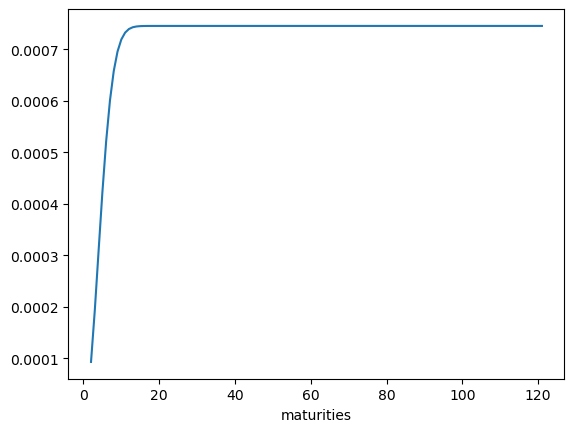

In [99]:
GVestimates=np.array([.001,0.002,0.002,0.002,0.003])
GVmaturities=np.array([2,3,4,5,50])*4
GVData=pd.DataFrame([GVestimates],columns=GVmaturities,index=["estimates"]).T
GVData["maturities"]=GVData.index

price_effects_factor,LamTildeMat,dpe,LamMat,LambdaRF,ratioQ,IMat,LplusMat=getPE( maturities_finer,tau_bar,γ,beta_hat,QT,Gamma,GVData)

func_GV=getGVestimates(GVData)

#plot the GV as function of maturity 
maturities_finer=Loadings_finer.index
GVData_finer=pd.DataFrame()
GVData_finer["GV_finer"]=func_GV(maturities_finer)
GVData_finer["maturities"]=maturities_finer
GVData_finer.set_index("maturities",inplace=True)
GVData_finer["GV_finer"].plot()
#Loadings_finer[["omega", 'omega_pe']].plot()
#Loadings_finer[["omega", 'omega_pe']].sum()

In [100]:

Loadings_finer['omega_pe_risky']=np.matmul(price_effects_factor,Loadings_finer['omega'])


### Price Effects with Costly bond issuances

We need to define 

* $\Lambda^{0}=Y_t\frac{\lambda^0_t}{Q^1_t}$
* $\omega^{0}_t = 1-\mathbb{1}^{\intercal} \omega_t$
* $\omega^{0,+}_t = \frac{Q^1_t}{\Gamma Q^2_t}\omega_t[1] (?)$ 

and define $h_{t}^{0}=\Lambda^{0}\left(\omega^0_t-\omega^{0,+}_t\right)\mathbf{1}$. Then we use the recursion

$$
\omega_{t}=\underbrace{\left[I+d_{t}\Sigma_{t}^{-1}\Lambda_{t}\right]^{-1}}_{B}\left(\omega_{t}^{*}+d_{t}\Sigma_{t}^{-1}h_{t}^{0}\right)+\underbrace{\left[I+d_{t}\Sigma_{t}^{-1}\Lambda_{t}\right]^{-1}\left[d_{t}\Sigma_{t}^{-1}\Lambda_{t}L_{t}^{+}\right]}_{A}\omega_{t-1}
$$

We compute the SS portfolio using this iteration

In [101]:
omega_US=temp.omega_US.values
namxy=15
bins=[range(n+1,n+1+4*3) for n in range(4*namxy)]
bins=[*bins,range(4*namxy+1,N*4)]
print(bins)
DataForLambdaVal=np.zeros(len(bins))
DataForLambdaMat=np.zeros(len(bins))
for ibin  in range(len(bins)):
    binval=bins[ibin]
    omegabin=sum(omega_US[binval])
    matbin=np.mean(binval)
    funcGVval=func_GV(matbin)
    DataForLambdaVal[ibin]=(matbin/omegabin)*funcGVval*7.3
    DataForLambdaMat[ibin]=matbin
x_data = DataForLambdaMat
y_data = DataForLambdaVal



[range(1, 13), range(2, 14), range(3, 15), range(4, 16), range(5, 17), range(6, 18), range(7, 19), range(8, 20), range(9, 21), range(10, 22), range(11, 23), range(12, 24), range(13, 25), range(14, 26), range(15, 27), range(16, 28), range(17, 29), range(18, 30), range(19, 31), range(20, 32), range(21, 33), range(22, 34), range(23, 35), range(24, 36), range(25, 37), range(26, 38), range(27, 39), range(28, 40), range(29, 41), range(30, 42), range(31, 43), range(32, 44), range(33, 45), range(34, 46), range(35, 47), range(36, 48), range(37, 49), range(38, 50), range(39, 51), range(40, 52), range(41, 53), range(42, 54), range(43, 55), range(44, 56), range(45, 57), range(46, 58), range(47, 59), range(48, 60), range(49, 61), range(50, 62), range(51, 63), range(52, 64), range(53, 65), range(54, 66), range(55, 67), range(56, 68), range(57, 69), range(58, 70), range(59, 71), range(60, 72), range(61, 120)]


<Figure size 800x600 with 0 Axes>

Text(0.5, 0, 'maturity (quarters)')

Text(0, 0.5, 'scaled price effects, $\\Lambda$')

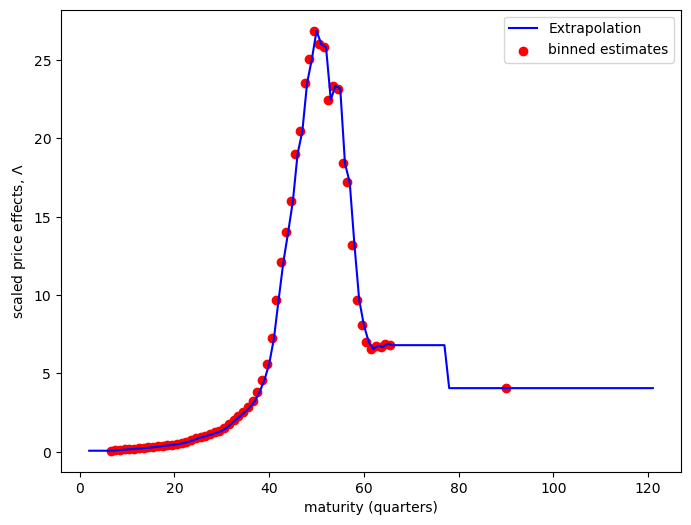

In [102]:
from scipy.interpolate import interp1d
x_data_extended = np.arange(2, N*4+2)
# Create a nearest-neighbor interpolation function
nearest_neighbor_func = interp1d(x_data, y_data, kind='nearest', fill_value='extrapolate')

# Apply the nearest neighbor interpolation to the extended x_data range (2 to 121)
y_nearest = nearest_neighbor_func(x_data_extended)

# Plotting the nearest neighbor extrapolation for the extended x_data range
plt.figure(figsize=(8,6))
plt.plot(x_data_extended, y_nearest, label=f'Extrapolation', color='blue')
plt.scatter(x_data, y_data, color='red', label='binned estimates')
plt.xlabel('maturity (quarters)')
plt.ylabel('scaled price effects, $\Lambda$')
#plt.title('Nearest Neighbor Extrapolation')
plt.legend()
#plt.grid(True)
plt.savefig(draft_path+"gv_fit.pdf")
plt.show()
#save figure


In [103]:
LamMat=np.diag(y_nearest)
LambdaRF=func_GV(1)*7.3/omega_US[1]

Text(0.5, 0, 'Maturity')

Text(0, 0.5, 'LamMat')

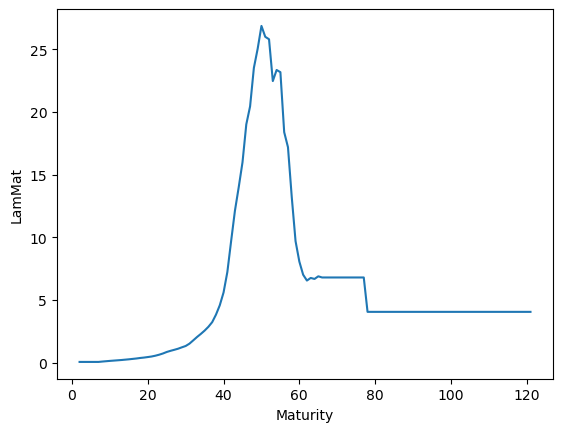

In [104]:
# plot diagonal of LamMat against maturities
plt.plot(maturities_finer,np.diag(LamMat))
plt.xlabel("Maturity")
plt.ylabel("LamMat")


### Simulate

In [105]:
# iterate on the  equation \omega_{t+1}=BMat\omega^{*}-Amat\omega_{t} with initial guess omega_{t}=Loadings_finer.omega.values. BMat,Amat is a matrix and omega_{t} is a vector
# Define the variables
omega_star = Loadings_finer.omega.values  # Define the target vector omega_star
pefactor=np.linalg.inv(IMat+dpe*(Pi_finer@(LamMat@(IMat-LplusMat))))
omega_ss=pefactor@omega_star
omega_t = omega_star  # Initial guess for omega_t
# Set the number of iterations
num_iterations = 2000 # You can adjust this as needed

omega_t_mat=np.zeros((num_iterations,len(maturities_finer)))
omega_t_mat[0,:]=omega_t
#LambdaRFGV=func_GV(1)

#print("LambdaRFGV = "+str(LambdaRFGV))
omega_US=temp.omega_US[1:].values
omega0US=1-sum(omega_US)
print("omega0US = "+str(omega0US))
#LambdaRF=LambdaRFGV/(1+LambdaRFGV*omega0US*B_T)
#LamMatVal=np.zeros(len(omega_US)) # initialize LamMatVal
#range(2,len(omega_t)+2)
#for mat in range(2,len(omega_t)+2):
#    num=(mat)*func_GV(mat)
#    LamMatVal[int(mat)-2]=(num)/(1+num*omega_US[int(mat)-2]*B_T)  

#LamMat=np.diag(LamMatVal)

#LambdaRF=LambdaRFGV/(1+LambdaRFGV*omega0US*B_T)

# Iteratively update omega_t
for _ in range(num_iterations):
    omega0=1-sum(omega_t) # rf holding
    omega0plus=omega_t[0]*QT(1)/(QT(2)*Gamma) #riskfree+
    ht=np.ones(len(omega_t))*LambdaRF*(omega0-omega0plus) # ht = LambdaRF*(omega0-omega0plus)
    dSigmaInvh=dpe*(Pi_finer@ht) # dSigmaInvh = d*Pi*ht
    BMatBeforeInv=IMat+dpe*(Pi_finer @ LamMat) # IMat+d*Pi_finer @ LamMat
    BMat=np.linalg.inv(BMatBeforeInv) # BMat = inv(IMat+d*Pi_finer @ LamMat)
    AMat1=(IMat+dpe*(Pi_finer @ LamMat)) # IMat+d*Pi_finer @ LamMat
    Amat2=dpe*Pi_finer@(LamMat @ LplusMat)  # d*Pi_finer @ (LamMat @ LplusMat)
    Amat=(np.linalg.inv(AMat1)) @ Amat2 # Amat = inv(AMat1) @ Amat2
    omega_t = BMat @ (omega_star+dSigmaInvh) + Amat @ omega_t  # omega_t = BMat @ (omega_star+dSigmaInvh) + Amat @ omega_{t-1}
    omega_t_mat[_,:]=omega_t
    # print every 100 iterations
    if _ % 100 == 0:
        print("num interations = "+str(_))
    


omega0US = 0.107262688555113
num interations = 0
num interations = 100
num interations = 200
num interations = 300
num interations = 400
num interations = 500
num interations = 600
num interations = 700
num interations = 800
num interations = 900
num interations = 1000
num interations = 1100
num interations = 1200
num interations = 1300
num interations = 1400
num interations = 1500
num interations = 1600
num interations = 1700
num interations = 1800
num interations = 1900


<Axes: xlabel='maturities'>

omega            0.8192
omega_pe_risky   0.0039
omega_pe_bonds   0.8738
dtype: float64

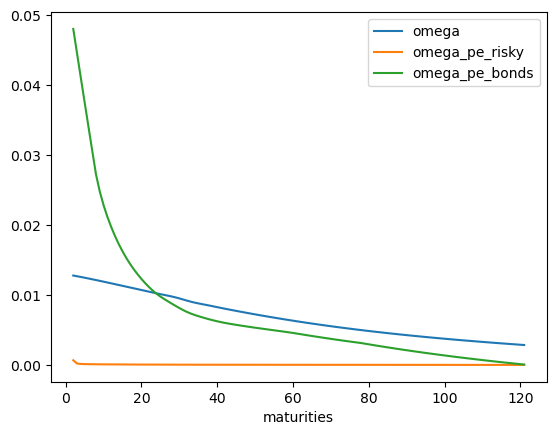

In [106]:
Loadings_finer['omega_pe_bonds']=omega_t

Loadings_finer[["omega", 'omega_pe_risky','omega_pe_bonds']].plot()
Loadings_finer[["omega", 'omega_pe_risky','omega_pe_bonds']].sum()

Text(0.5, 0, 'Maturity')

Text(0, 0.5, 'omega_t')

(2.0, 120.0)

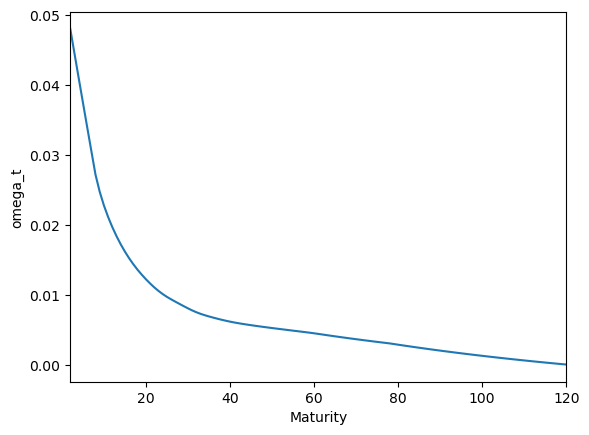

In [107]:
#plot omega_t
plt.plot(maturities_finer, omega_t)
plt.xlabel("Maturity")  # Corrected: added plt.
plt.ylabel("omega_t")   # Corrected: added plt.
plt.xlim(2, 120)        # Corrected: added plt.
plt.show()              # Add this line to display the plot


### Figure 4 (a): OPTIMAL PORTFOLIO WITH PRICE EFFECTS20 40 60 80 100 120

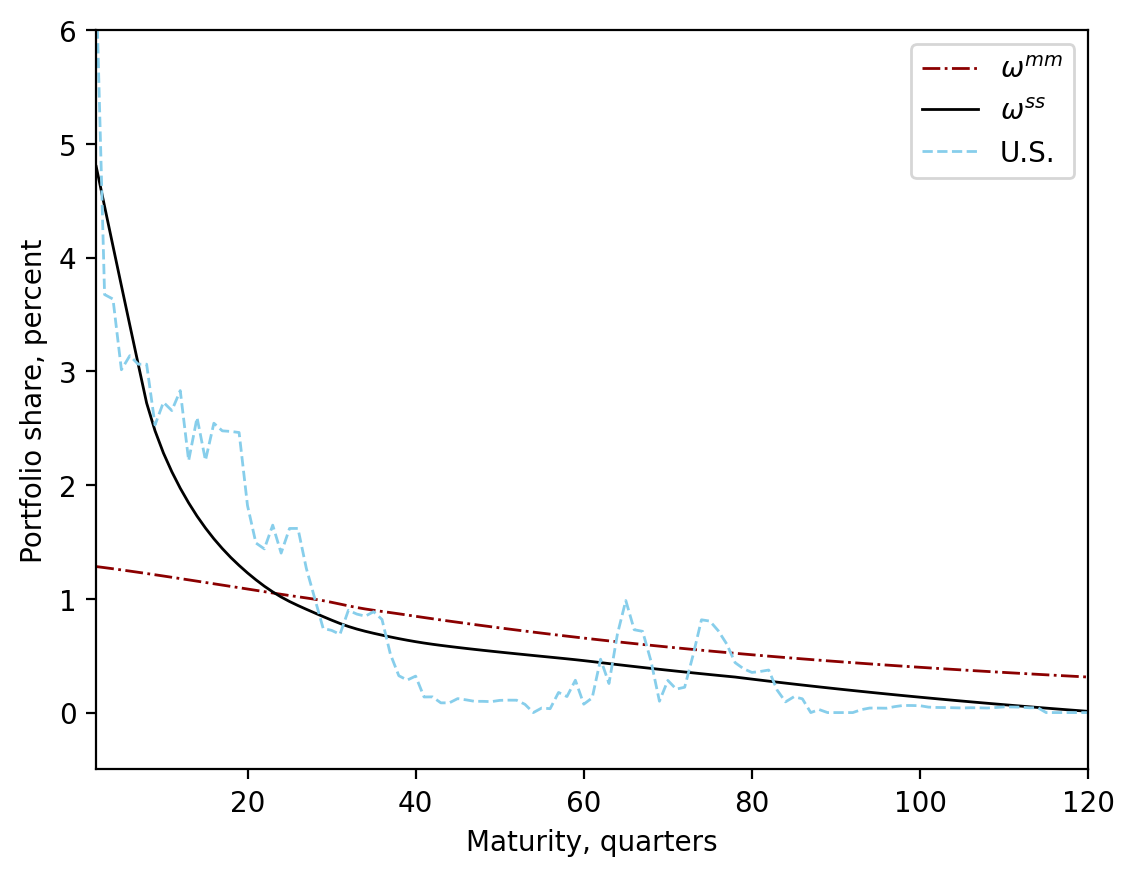

In [108]:
temp.loc[2:,"omega PE"]=Loadings_finer.omega_pe_risky.values
temp.loc[2:,"omega PE Bonds"]=Loadings_finer.omega_pe_bonds.values


priceeffects = plot_fig(name='opt_pe', T=len(maturities_finer), marker=['None','None','None'], columns=["QGamma", 'omega PE Bonds','omega_US'], leg=[r"$\omega^{mm}$",r"$\omega^{ss}$ ",r"U.S."], col=['darkred','black','skyblue'],linestyle=["-.","-",'--'],markersize=['1','2','1'] , Max_y=6,alpha=[1,1,1])


In [109]:
Macaulay=temp.reset_index()
Mc_US=(Macaulay['omega_US']*Macaulay['index']/4).sum()
Mc_th = (Macaulay['omega PE'] * Macaulay['index'] / 4).sum()
Mc_th_bonds = (Macaulay['omega PE Bonds'] * Macaulay['index'] / 4).sum()

print("Mcaulay US = {}".format(Mc_US))
print("Mcaulay PE (Lambda0=0)= {}".format(Mc_th))
print("Mcaulay PE (Lambda0>0)= {}".format(Mc_th_bonds))

Mcaulay US = 5.285136107905255
Mcaulay PE (Lambda0=0)= 0.024772152755322654
Mcaulay PE (Lambda0>0)= 6.153448004037036


## 5. Extention: AR(1) structure on the factor model

#### Estimating the factor regressions for returns

For each maturity $k$, we now run the regression 

$$r^{k}_{t}=\alpha_k+ \rho_k r^k_{t-1}+\delta_{(k)}  f_t+\sigma_{k}\varepsilon_{k,t}$$

and record the factor loadings $\delta_{r}\equiv\{\kappa_{(k)}\}$, $R2$, $\Delta\equiv diag \left(\{\sigma^2_{k}\}_k\right)$


In [110]:
lag=1
data = macrodata[(macrodata.index.year > start_year)
                 & (macrodata.index.year < end_year)]

X=data[['cons','factor']]
alpha=np.zeros(len(pair_of_return))
se_alpha=np.zeros(len(pair_of_return))
rho=np.zeros(len(pair_of_return))
se_rho=np.zeros(len(pair_of_return))
kappa=np.zeros(len(pair_of_return))
se_kappa=np.zeros(len(pair_of_return))
r2=np.zeros(len(pair_of_return))
Delta=np.zeros(len(pair_of_return))
Deltaraw=np.zeros(len(pair_of_return))
std_simga2 = np.zeros(len(pair_of_return))

for ret in range(len(pair_of_return)):
    Y=data[pair_of_return[ret]]
    data['lag_ret']=data[pair_of_return[ret]].shift()
    X=data[['cons','factor','lag_ret']]
    model = sm.OLS(Y[lag:],X[lag:])
    results = model.fit()
    alpha[ret]=results.params.cons
    se_alpha[ret]=results.bse.cons
    rho[ret]=results.params.lag_ret
    se_rho[ret]=results.bse.lag_ret
    kappa[ret]=results.params.factor
    se_kappa[ret]=results.bse.factor
    r2[ret]=results.rsquared
    Delta[ret]=results.resid.var()
    Deltaraw[ret]=Y.var()
    #cehck with leo
    #std_simga2[ret]=np.sqrt(2*(Y.var())**2/(len(Y)-1))
    std_simga2[ret]=np.sqrt(2*(results.resid.var())**2/(len(Y)-1))
    
    
#delta=np.zeros(len(pair_of_return))
LoadingsAR1=pd.DataFrame([alpha, se_alpha, rho, se_rho, kappa,se_kappa,Delta,std_simga2,r2,Deltaraw]).T
LoadingsAR1.index=pair_of_return
LoadingsAR1.columns=['alpha','se_alpha','rho','se_rho','kappa_f','se_kappa_f','sigma2','std_simga2','R2','sigma2_raw']
LoadingsAR1['maturities']=np.array([6,9,15,21,27,33,39,45,51,57,7.5*12])/3.0
LoadingsAR1['maturities']=LoadingsAR1['maturities'].astype(int)


#### Estimating the factor regressions for log spending deviation

Like the returns, we also project $\hat{G}$ on the factor using 

$$\hat{G}_{t}=\alpha_G+ \rho_G \hat{G}_{t-1} + \kappa_G f_t+\sigma_{G}\varepsilon_{G,t}$$



In [111]:
macrodata['ln_g_dt_lag']=macrodata['ln_g_dt'].shift()

data=macrodata[(macrodata.index.year>start_year)&(macrodata.index.year<end_year) ]
sel=pd.notnull(data['ln_g_dt_lag']) & (pd.notnull(data['factor']) ) & (pd.notnull(data['ln_g_dt']) )
    
Y=data[sel].ln_g_dt
X=data[sel][['cons','ln_g_dt_lag','factor']]
model = sm.OLS(Y[lag:],X[lag:])
results = model.fit()
print (results.summary())
kappa_G=results.params.factor
rho_G=results.params.ln_g_dt_lag
cov_rG_factor=LoadingsAR1.kappa_f*kappa_G*data.factor.var()

macrodata['ln_g_innv']=macrodata['ln_g_dt']-macrodata['ln_g_dt'].autocorr()*macrodata['ln_g_dt'].shift()
data['ln_g_innv']=macrodata['ln_g_innv']

cov_rG_raw=macrodata[pair_of_return+['ln_g_innv']].cov().ln_g_innv[:-1].values

LoadingsAR1['cov_rG'] = cov_rG_factor
LoadingsAR1['cov_rG_raw'] = cov_rG_raw

LoadingsAR1['alpha_G'] = results.params.cons
LoadingsAR1['se_alpha_G'] = results.bse.cons

LoadingsAR1['kappa_G'] = results.params.factor
LoadingsAR1['se_alpha_G'] = results.bse.factor

LoadingsAR1['sigma_G'] = results.resid.var()
## check with LEO
#Loadings['sigma_G_se'] = np.sqrt(2*(Y.var())**2/(len(Y)-1))
LoadingsAR1['sigma_G_se'] = np.sqrt(2*(results.resid.var())**2/(len(Y)-1))

LoadingsAR1['kappa_G'] = results.params.factor
LoadingsAR1['se_alpha_G'] = results.bse.factor

LoadingsAR1['rho_G'] = rho_G
LoadingsAR1['kappa_G'] = kappa_G
LoadingsAR1['se_rho_G'] = results.bse.ln_g_dt_lag
LoadingsAR1['se_kappa_G'] = results.bse.factor
macrodata['ln_g_dt_lag'] = macrodata['ln_g_dt'].shift()

LoadingsAR1["R2_G"] = results.rsquared


                            OLS Regression Results                            
Dep. Variable:                ln_g_dt   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     8156.
Date:                Wed, 20 Nov 2024   Prob (F-statistic):          9.09e-230
Time:                        15:59:50   Log-Likelihood:                -545.26
No. Observations:                 255   AIC:                             1097.
Df Residuals:                     252   BIC:                             1107.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
cons           -0.1772      0.129     -1.369      

#### Estimating the factor regressions for detrended tfp $\hat{\theta}$

Like the returns, we also project $\hat{\theta}$ on the factor using 

$$\hat{\theta}_{t}=\alpha_{\theta}+ \rho_{\theta} \hat{\theta}_{t-1} + \kappa_{\theta} f_t+\sigma_{\theta}\varepsilon_{\theta,t}$$



In [112]:
macrodata['theta_lag']=macrodata['theta'].shift()

data=macrodata[(macrodata.index.year>start_year)&(macrodata.index.year<end_year) ]
sel=pd.notnull(data['theta_lag']) & (pd.notnull(data['factor']) ) & (pd.notnull(data['theta']) )
    
Y=data[sel].theta
X=data[sel][['cons','theta_lag','factor']]
model = sm.OLS(Y[lag:],X[lag:])
results = model.fit()
print (results.summary())
kappa_theta=results.params.factor
rho_theta=results.params.theta_lag
cov_rtheta_factor=LoadingsAR1.kappa_f*kappa_theta*data.factor.var()

macrodata['theta_innv']=macrodata['theta']-macrodata['theta'].autocorr()*macrodata['theta'].shift()
data['theta_innv']=macrodata['theta_innv']

cov_rtheta_raw=macrodata[pair_of_return+['theta_innv']].cov().theta_innv[:-1].values
LoadingsAR1['cov_rtheta']=cov_rtheta_factor
LoadingsAR1['cov_rtheta_raw']=cov_rtheta_raw

LoadingsAR1['rho_theta']=rho_theta
LoadingsAR1['kappa_theta']=kappa_theta
LoadingsAR1['se_rho_theta']=results.bse.theta_lag
LoadingsAR1['se_kappa_theta']=results.bse.factor

LoadingsAR1['alpha_theta'] = results.params.cons
LoadingsAR1['se_alpha_theta'] = results.bse.cons


LoadingsAR1['sigma_theta'] = results.resid.var()
# check with Leo
#Loadings['sigma_theta_se'] = np.sqrt(2*(Y.var())**2/(len(Y)-1))
LoadingsAR1['sigma_theta_se']  = np.sqrt(2*(results.resid.var())**2/(len(Y)-1))

LoadingsAR1['kappa_theta'] = results.params.factor
LoadingsAR1['se_alpha_theta'] = results.bse.factor


LoadingsAR1["R2_theta"] = results.rsquared


                            OLS Regression Results                            
Dep. Variable:                  theta   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                 3.163e+04
Date:                Wed, 20 Nov 2024   Prob (F-statistic):          2.61e-303
Time:                        15:59:50   Log-Likelihood:                -376.35
No. Observations:                 255   AIC:                             758.7
Df Residuals:                     252   BIC:                             769.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
cons          -0.3133      0.100     -3.122      0.0

#### Estimating the factor autoregression $f_t$


$$f_{t}=\alpha_{f}+\rho_{f}f_{t-1}+\sigma_{f}\varepsilon_{f,t}$$



In [113]:
macrodata['factor_lag']=macrodata['factor'].shift()

data=macrodata[(macrodata.index.year>start_year)&(macrodata.index.year<end_year) ]
sel=(pd.notnull(data['factor']) ) & (pd.notnull(data['factor_lag']) )
    
Y=data[sel].factor
X=data[sel][['cons','factor_lag']]
model = sm.OLS(Y[lag:],X[lag:])
results = model.fit()
print (results.summary())
rho_factor=results.params.factor_lag
cov_rtheta_factor = LoadingsAR1.kappa_f*kappa_theta*data.factor.var()


macrodata['factor_innv']=macrodata['factor']-rho_factor*macrodata['factor_lag']-results.params.cons
data['factor_innv']=macrodata['factor_innv']
cov_rfactor_raw = macrodata[pair_of_return +
                            ['factor_innv']].cov().factor_innv[:-1].values

LoadingsAR1['rho_factor'] = rho_factor
LoadingsAR1['kappa_factor'] = 0
LoadingsAR1['se_rho_factor'] = results.bse.factor_lag
LoadingsAR1['se_kappa_factor'] = np.NaN

LoadingsAR1['alpha_factor'] = results.params.cons
LoadingsAR1['se_alpha_factor'] = results.bse.cons


LoadingsAR1['sigma_factor'] = results.resid.var()
# check with leo
#Loadings['sigma_factor_se'] = np.sqrt(2*(Y.var())**2/(len(Y)-1))
LoadingsAR1['sigma_factor_se'] = np.sqrt(2*(results.resid.var())**2/(len(Y)-1))



LoadingsAR1["R2_factor"] = results.rsquared


                            OLS Regression Results                            
Dep. Variable:                 factor   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.3028
Date:                Wed, 20 Nov 2024   Prob (F-statistic):              0.583
Time:                        15:59:50   Log-Likelihood:                -887.44
No. Observations:                 254   AIC:                             1779.
Df Residuals:                     252   BIC:                             1786.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
cons           0.0260      0.502      0.052      0.9

In [114]:
Reg_table = LoadingsAR1.reset_index(drop=True)
Reg_table['maturities'] = Reg_table['maturities']*3
Reg_table.loc[10, 'maturities'] = 120

Reg_table = Reg_table[["maturities",
                       "alpha", "se_alpha", "rho", "se_rho", "kappa_f", "se_kappa_f", "sigma2", "std_simga2", "R2"]]


for k in ["G", "theta","factor"]:
    var = '{}'.format(k)
    Reg_table.loc[len(Reg_table.index)] = [var, LoadingsAR1["alpha_{}".format(k)][0], LoadingsAR1["se_alpha_{}".format(
        k)][0], LoadingsAR1["rho_{}".format(k)][0], LoadingsAR1["se_rho_{}".format(k)][0], LoadingsAR1["kappa_{}".format(k)][0],
        LoadingsAR1["se_kappa_{}".format(k)][0], LoadingsAR1["sigma_{}".format(k)][0], LoadingsAR1["sigma_{}_se".format(k)][0], LoadingsAR1["R2_{}".format(k)][0]]

Reg_table = Reg_table.set_index('maturities')
Reg_table[["alpha", "se_alpha", "rho", "se_rho", "kappa_f", "se_kappa_f", "sigma2", "std_simga2", "R2"]] = Reg_table[[
    "alpha", "se_alpha", "rho", "se_rho", "kappa_f", "se_kappa_f", "sigma2", "std_simga2", "R2"]].applymap("{0:.3f}".format)

Reg_table['std_simga2'] = "(" + Reg_table['std_simga2'].apply(str) + ")"
Reg_table['se_alpha'] = "(" + Reg_table['se_alpha'].apply(str) + ")"
Reg_table['se_kappa_f'] = "(" + Reg_table['se_kappa_f'].apply(str) + ")"
Reg_table['se_rho'] = "(" + Reg_table['se_rho'].apply(str) + ")"
Reg_table = Reg_table.T

Reg_table.to_csv(draft_path+'Reg_table_no_adjust_AR1.csv')
Reg_table


maturities,6,9,15,21,27,33,39,45,51,57,120,G,theta,factor
alpha,0.086,0.155,0.220,0.245,0.284,0.315,0.346,0.344,0.372,0.304,0.444,-0.177,-0.313,0.026
se_alpha,(0.014),(0.025),(0.033),(0.035),(0.039),(0.039),(0.038),(0.037),(0.037),(0.043),(0.030),(0.016),(0.008),(0.502)
rho,-0.107,-0.057,-0.041,-0.043,-0.042,-0.025,-0.022,-0.008,-0.022,-0.027,0.003,1.001,1.009,-0.035
se_rho,(0.043),(0.035),(0.030),(0.025),(0.023),(0.020),(0.018),(0.016),(0.015),(0.015),(0.009),(0.008),(0.004),(0.063)
kappa_f,0.028,0.074,0.118,0.157,0.199,0.230,0.257,0.285,0.306,0.345,0.404,-0.032,-0.048,0.000
se_kappa_f,(0.002),(0.003),(0.004),(0.004),(0.005),(0.005),(0.005),(0.005),(0.005),(0.005),(0.004),(0.016),(0.008),(nan)
sigma2,0.044,0.154,0.267,0.300,0.378,0.384,0.356,0.345,0.341,0.460,0.222,4.232,1.125,63.676
std_simga2,(0.004),(0.014),(0.024),(0.027),(0.034),(0.034),(0.031),(0.031),(0.030),(0.041),(0.020),(0.375),(0.100),(5.650)
R2,0.536,0.698,0.771,0.840,0.870,0.898,0.922,0.938,0.946,0.943,0.979,0.985,0.996,0.001


## 6. Extension: Multifactor
The referee wanted us to use a multifactor model along the lines of Litterman and Scheinkman (1991). We estimate a 2 factor model (level and slope). The first step is to extract the two principal components.

Let $f_{t}^{1},\ldots f_{t}^{N}$ be N factors and the statistical model for returns be $$r_{t}^{k}=\alpha^{k}+\sum_{n=1}^{N}\kappa_{k}^{n}f_{t}^{n}+\sigma_{k}\varepsilon_{t}^{k}$$and $$f_{t}=\alpha_{f}+\sigma_{f,n}\varepsilon_{t}^{f,n}$$

In [115]:
data=macrodata[(macrodata.index.year>start_year)&(macrodata.index.year<end_year) ]


#factornamelist =['deficits_y','nom_shortrate','ln_real_gdp_dt'] + return_list
factornamelist = return_list
factornamelist =['deficits_y','nom_shortrate','ln_real_gdp_dt'] + return_list


pca = PCA(n_components=3)
principalComponents = pca.fit_transform(data[factornamelist])
pair_of_return=return_list[:-1]

print ("explained variation")
print (pca.explained_variance_ratio_)

#data['factor']=macrodata["real_gdp"]/macrodata["real_gdp"].shift(4)-1
data['factor1']=principalComponents[:,0]
data['factor2']=principalComponents[:,1]
data['factor3']=principalComponents[:,2]


#data['factor'].plot()
print ("sigma2_f")
print (data[['factor1','factor2','factor3']].var())
macrodata['factor1']=data.factor1
macrodata['factor2']=data.factor2
macrodata['factor3']=data.factor3



explained variation
[0.88965443 0.07061805 0.01652138]
sigma2_f
factor1   63.3262
factor2    5.0266
factor3    1.1760
dtype: float64


In [116]:
pca.components_.T * np.sqrt(pca.explained_variance_)

array([[ 1.05920385e-01, -4.42012933e-02,  9.30924632e-01],
       [-8.82114754e-02, -4.12172674e-02, -5.38228175e-01],
       [-3.89974222e-03, -4.05522595e-04, -3.12342527e-02],
       [ 2.22611200e-01, -1.19777397e-01, -5.08456847e-02],
       [ 5.93587728e-01, -2.83451364e-01, -5.15804978e-02],
       [ 9.44687135e-01, -4.11969269e-01, -7.03666323e-02],
       [ 1.25070232e+00, -4.68399274e-01, -4.12618072e-02],
       [ 1.58826272e+00, -5.47631368e-01, -4.14661054e-02],
       [ 1.83506281e+00, -5.55563683e-01, -3.02270718e-02],
       [ 2.04892597e+00, -5.54988654e-01, -5.91841181e-03],
       [ 2.27247490e+00, -4.86822062e-01,  1.61186902e-02],
       [ 2.43418275e+00, -4.44817509e-01,  2.77190902e-02],
       [ 2.74734984e+00, -4.15724260e-01,  2.76507018e-02],
       [ 3.21696912e+00, -1.46245188e-01,  3.62283638e-02],
       [ 4.62322822e+00,  1.73018567e+00, -3.23035837e-02]])

In [117]:
data[['factor1','factor2']].corr()


,factor1,factor2
factor1,1.0000,0.0000
factor2,0.0000,1.0000


<Axes: xlabel='DATE'>

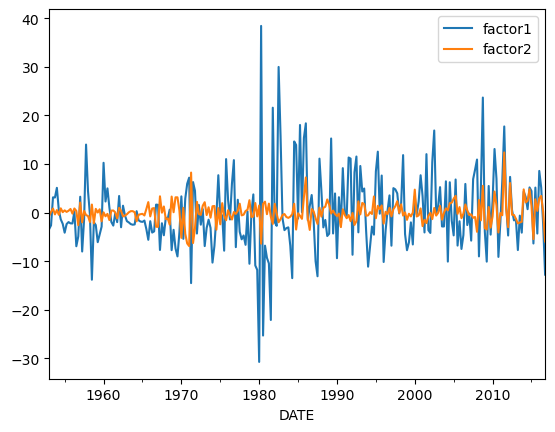

In [118]:
data[['factor1','factor2']].plot()
data[['datealt','factor1','factor2']].to_csv(draft_path+'factordata.csv')



### Estimating the factor regressions for returns

For each maturity $k$, we now run the regression

$$r^{k}_{t}=\alpha_k+ \delta_{(1,k)}  f^1_t+\delta_{(2,k)}  f^2_t+\sigma_{k}\varepsilon_{k,t}$$



In [119]:
lag=1
X=data[['cons','factor1','factor2']]
alphaMF=np.zeros(len(pair_of_return))
se_alphaMF=np.zeros(len(pair_of_return))
rhoMF=np.zeros(len(pair_of_return))
se_rhoMF=np.zeros(len(pair_of_return))
kappa1=np.zeros(len(pair_of_return))

se_kappa1=np.zeros(len(pair_of_return))
kappa2=np.zeros(len(pair_of_return))

se_kappa2=np.zeros(len(pair_of_return))

r2MF=np.zeros(len(pair_of_return))
DeltaMF=np.zeros(len(pair_of_return))
DeltarawMF=np.zeros(len(pair_of_return))
std_simga2MF = np.zeros(len(pair_of_return))

for ret in range(len(pair_of_return)):
    Y=data[pair_of_return[ret]]
    data['lag_ret']=data[pair_of_return[ret]].shift()
    X=data[['cons','lag_ret','factor1','factor2']]
    model = sm.OLS(Y[lag:],X[lag:])
    results = model.fit()
    alphaMF[ret]=results.params.cons
    se_alphaMF[ret]=results.bse.cons
    kappa1[ret]=results.params.factor1
    se_kappa1[ret]=results.bse.factor1
    kappa2[ret]=results.params.factor2
    se_kappa2[ret]=results.bse.factor2
    r2MF[ret]=results.rsquared
    DeltaMF[ret]=results.resid.var()
    DeltarawMF[ret]=Y.var()
     #cehck with leo
    #std_simga2[ret]=np.sqrt(2*(Y.var())**2/(len(Y)-1))
    std_simga2MF[ret]=np.sqrt(2*(results.resid.var())**2/(len(Y)-1))
    
#kappa=np.zeros(len(pair_of_return))
LoadingsMF=pd.DataFrame([alphaMF, se_alphaMF, rhoMF, se_rhoMF, kappa1,se_kappa1,kappa2,se_kappa2,DeltaMF,std_simga2MF,r2,DeltarawMF]).T
LoadingsMF.index=pair_of_return
LoadingsMF.columns=['alpha','se_alpha','rho','se_rho','kappa_f1','se_kappa_f1','kappa_f2','se_kappa_f2','sigma2','std_simga2','R2','sigma2_raw']
LoadingsMF['maturities']=np.array([6,9,15,21,27,33,39,45,51,57,7.5*12])/3.0
LoadingsMF['maturities']=LoadingsMF['maturities'].astype(int)

In [120]:
# write a csv file with the data in LoadingsMF
LoadingsMF.to_csv('LoadingsMF.csv')

In [121]:
sigma2_f1=data.factor1.var()
sigma2_f2=data.factor2.var()


### Estimating the factor regressions for government spending

 We now run the regression 

 $$\ln G_t-\ln G_{t-1}=\alpha_G+ \kappa_{1,G}  f^1_t+\kappa^2_{2,G}  f^2_t+\sigma_{G}\varepsilon_{G,t}$$


In [122]:
macrodata['ln_g_dt_lag'] = macrodata['ln_g_dt'].shift()

data = macrodata[(macrodata.index.year > start_year)
                 & (macrodata.index.year < end_year)]
sel = pd.notnull(data['ln_g_dt_lag']) & (pd.notnull(
    data['factor1'])) & (pd.notnull(data['factor2'])) & (pd.notnull(data['ln_g_dt']))

Y = data[sel].ln_g_dt-data[sel].ln_g_dt_lag
X = data[sel][['cons', 'factor1','factor2']]
model = sm.OLS(Y[lag:], X[lag:])
results = model.fit()
print(results.summary())
kappa1_G = results.params.factor1
kappa2_G = results.params.factor2

rho_G = 1.0
cov_rG_factor = LoadingsMF.kappa_f1*kappa1_G*data.factor1.var()+LoadingsMF.kappa_f2*kappa2_G*data.factor2.var()

macrodata['ln_g_innv'] = macrodata['ln_g_dt'] - \
    rho_G*macrodata['ln_g_dt'].shift()
data['ln_g_innv'] = macrodata['ln_g_innv']

cov_rG_raw = macrodata[pair_of_return +
                       ['ln_g_innv']].cov().ln_g_innv[:-1].values
LoadingsMF['cov_rG'] = cov_rG_factor
LoadingsMF['cov_rG_raw'] = cov_rG_raw

LoadingsMF['alpha_G'] = results.params.cons
LoadingsMF['se_alpha_G'] = results.bse.cons

LoadingsMF['kappa1_G'] = results.params.factor1
LoadingsMF['se_kappa1_G'] = results.bse.factor1


LoadingsMF['kappa2_G'] = results.params.factor2
LoadingsMF['se_kappa2_G'] = results.bse.factor2

LoadingsMF['sigma_G']=results.resid.var()
## check with LEO
#Loadings['sigma_G_se'] = np.sqrt(2*(Y.var())**2/(len(Y)-1))
LoadingsMF['sigma_G_se'] = np.sqrt(2*(results.resid.var())**2/(len(Y)-1))

LoadingsMF['rho_G']=rho_G
LoadingsMF['kappa1_G']=kappa1_G
LoadingsMF['se_rho_G']=np.NaN
LoadingsMF['se_kappa1_G']=results.bse.factor1
LoadingsMF['kappa2_G']=kappa2_G
LoadingsMF['se_kappa2_G']=results.bse.factor2
LoadingsMF["R2_G"]=results.rsquared
LoadingsMF

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     2.063
Date:                Wed, 20 Nov 2024   Prob (F-statistic):              0.129
Time:                        15:59:51   Log-Likelihood:                -545.11
No. Observations:                 255   AIC:                             1096.
Df Residuals:                     252   BIC:                             1107.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
cons          -0.1768      0.129     -1.368      0.1

,alpha,se_alpha,rho,se_rho,kappa_f1,se_kappa_f1,kappa_f2,se_kappa_f2,sigma2,std_simga2,...,se_alpha_G,kappa1_G,se_kappa1_G,kappa2_G,se_kappa2_G,sigma_G,sigma_G_se,rho_G,se_rho_G,R2_G
hprx6m,0.0856,0.0112,0.0000,0.0000,0.0279,0.0014,-0.0531,0.0048,0.0297,0.0026,...,0.1293,-0.0317,0.0162,-0.0321,0.0577,4.2266,0.3743,1.0000,NaN,0.0161
hprx12m,0.1526,0.0175,0.0000,0.0000,0.0745,0.0022,-0.1259,0.0077,0.0741,0.0066,...,0.1293,-0.0317,0.0162,-0.0321,0.0577,4.2266,0.3743,1.0000,NaN,0.0161
hprx18m,0.2144,0.0201,0.0000,0.0000,0.1186,0.0025,-0.1832,0.0088,0.0982,0.0087,...,0.1293,-0.0317,0.0162,-0.0321,0.0577,4.2266,0.3743,1.0000,NaN,0.0161
hprx24m,0.2394,0.0184,0.0000,0.0000,0.1571,0.0023,-0.2080,0.0081,0.0829,0.0073,...,0.1293,-0.0317,0.0162,-0.0321,0.0577,4.2266,0.3743,1.0000,NaN,0.0161
hprx30m,0.2749,0.0184,0.0000,0.0000,0.1996,0.0023,-0.2436,0.0081,0.0828,0.0073,...,0.1293,-0.0317,0.0162,-0.0321,0.0577,4.2266,0.3743,1.0000,NaN,0.0161
hprx36m,0.3075,0.0177,0.0000,0.0000,0.2307,0.0022,-0.2478,0.0078,0.0773,0.0068,...,0.1293,-0.0317,0.0162,-0.0321,0.0577,4.2266,0.3743,1.0000,NaN,0.0161
hprx42m,0.3382,0.0140,0.0000,0.0000,0.2574,0.0017,-0.2480,0.0062,0.0482,0.0043,...,0.1293,-0.0317,0.0162,-0.0321,0.0577,4.2266,0.3743,1.0000,NaN,0.0161
hprx48m,0.3383,0.0208,0.0000,0.0000,0.2856,0.0026,-0.2182,0.0092,0.1068,0.0095,...,0.1293,-0.0317,0.0162,-0.0321,0.0577,4.2266,0.3743,1.0000,NaN,0.0161
hprx54m,0.3668,0.0243,0.0000,0.0000,0.3058,0.0030,-0.1980,0.0107,0.1451,0.0128,...,0.1293,-0.0317,0.0162,-0.0321,0.0577,4.2266,0.3743,1.0000,NaN,0.0161
hprx60m,0.3001,0.0342,0.0000,0.0000,0.3451,0.0043,-0.1838,0.0153,0.2916,0.0258,...,0.1293,-0.0317,0.0162,-0.0321,0.0577,4.2266,0.3743,1.0000,NaN,0.0161


,cov_rG,cov_rG_raw
hprx6m,-0.0476,0.0045
hprx12m,-0.1295,-0.0579
hprx18m,-0.2089,-0.0793
hprx24m,-0.2823,-0.2058
hprx30m,-0.3619,-0.3724
hprx36m,-0.4238,-0.4234
hprx42m,-0.4776,-0.4942
hprx48m,-0.5390,-0.5496
hprx54m,-0.5828,-0.6729
hprx60m,-0.6641,-0.6274


<Axes: >

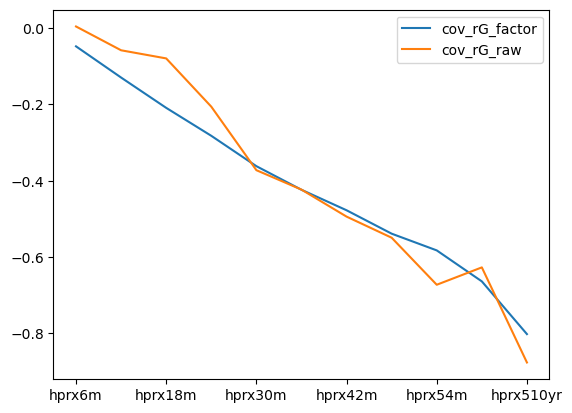

In [123]:
LoadingsMF[['cov_rG','cov_rG_raw']]
LoadingsMF[['cov_rG','cov_rG_raw']].plot()
plt.legend(['cov_rG_factor', 'cov_rG_raw'])
#save figure
plt.savefig(draft_path+'cov_rG_MF.pdf')

### Estimating the factor regressions for orthogonal component of output

 We now run the regression 

 $$\ln Y^{\perp}_t-\ln Y^{\perp}_{t-1}=\alpha_Y+ \kappa_{1,Y}  f^1_t+\kappa_{2,Y}  f^2_t+\sigma_{Y}\varepsilon_{Y,t}$$


In [124]:
macrodata['theta_lag'] = macrodata['theta'].shift()

data = macrodata[(macrodata.index.year > start_year)
                 & (macrodata.index.year < end_year)]
sel = pd.notnull(data['theta_lag']) & (pd.notnull(
    data['factor1'])) & (pd.notnull(
    data['factor2']))&(pd.notnull(data['theta']))

Y = data[sel].theta-data[sel].theta_lag
X = data[sel][['cons', 'factor1','factor2']]
model = sm.OLS(Y[lag:], X[lag:])
results = model.fit()
print(results.summary())
kappa1_theta = results.params.factor1
kappa2_theta = results.params.factor2

rho_theta = 1.0
cov_rtheta_factor = LoadingsMF.kappa_f1*kappa1_theta*data.factor1.var()+LoadingsMF.kappa_f2*kappa2_theta*data.factor2.var()

macrodata['theta_innv'] = macrodata['theta'] - \
    rho_theta*macrodata['theta'].shift()
data['theta_innv'] = macrodata['theta_innv']

cov_rtheta_raw = macrodata[pair_of_return +
                           ['theta_innv']].cov().theta_innv[:-1].values
LoadingsMF['cov_rtheta'] = cov_rtheta_factor
LoadingsMF['cov_rtheta_raw'] = cov_rtheta_raw

LoadingsMF['rho_theta'] = rho_theta
LoadingsMF['kappa1_theta'] = kappa1_theta
LoadingsMF['se_rho_theta'] = np.NaN
LoadingsMF['se_kappa1_theta'] = results.bse.factor1

LoadingsMF['kappa2_theta'] = kappa2_theta
LoadingsMF['se_kappa2_theta'] = results.bse.factor2

LoadingsMF['alpha_theta'] = results.params.cons
LoadingsMF['se_alpha_theta'] = results.bse.cons

LoadingsMF['kappa1_theta'] = results.params.factor1
LoadingsMF['se_kappa1_theta'] = results.bse.factor1

LoadingsMF['kappa2_theta'] = results.params.factor2
LoadingsMF['se_kappa2_theta'] = results.bse.factor2

LoadingsMF['sigma_theta'] = results.resid.var()
# check with Leo
#Loadings['sigma_theta_se'] = np.sqrt(2*(Y.var())**2/(len(Y)-1))
LoadingsMF['sigma_theta_se']  = np.sqrt(2*(results.resid.var())**2/(len(Y)-1))


LoadingsMF["R2_theta"] = results.rsquared


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.111
Model:                            OLS   Adj. R-squared:                  0.104
Method:                 Least Squares   F-statistic:                     15.80
Date:                Wed, 20 Nov 2024   Prob (F-statistic):           3.44e-07
Time:                        15:59:51   Log-Likelihood:                -378.39
No. Observations:                 255   AIC:                             762.8
Df Residuals:                     252   BIC:                             773.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
cons          -0.1509      0.067     -2.244      0.0

,cov_rtheta,cov_rtheta_raw
hprx6m,-0.0895,-0.0862
hprx12m,-0.2369,-0.2517
hprx18m,-0.3751,-0.3691
hprx24m,-0.4926,-0.4891
hprx30m,-0.6233,-0.6146
hprx36m,-0.7166,-0.6961
hprx42m,-0.7962,-0.7764
hprx48m,-0.8765,-0.8552
hprx54m,-0.9342,-0.9666
hprx60m,-1.0495,-1.0377


<Axes: >

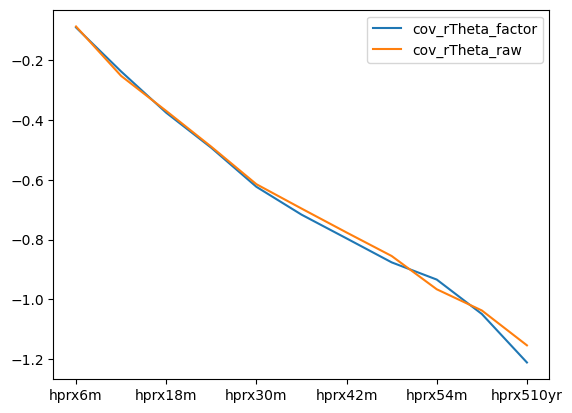

In [125]:
LoadingsMF[['cov_rtheta','cov_rtheta_raw']]
LoadingsMF[['cov_rtheta','cov_rtheta_raw']].plot()
plt.legend(['cov_rTheta_factor', 'cov_rTheta_raw'])
#save figure
plt.savefig(draft_path+'cov_rTheta_MF.pdf')

### Estimating the covariance matrix of returns using the factor model

Using the factor structure, we can write the covariance matrix of returns as

$$\Sigma_{T}=\Delta+ \kappa \Delta_f\kappa^{\intercal}$$

where $\Delta$ is a diagonal matrix with elements $\sigma^2_k$, $\Delta_f$ is a diagonal matrix with elements $[\sigma^2_{1,f},\sigma^2_{2,f}]$ and $\kappa=[\kappa_{1} \quad \kappa_2]$ are vectors with elements $\kappa_{(1,k)}$ and $\kappa^2_{(2,k)}$ stacked as two columns.

The inverse of the covariance matrix is given by Woodbury matrix identity applied to the prevuous expression

$$(A + UCV)^{-1} = A^{-1} - A^{-1} U (C^{-1} + VA^{-1}U)^{-1} VA^{-1}$$

where $A=\Delta$, $U=\kappa$, $C=\Delta_f$ and $V=\kappa^{\intercal}$






In [126]:
DeltaMF=np.diag(LoadingsMF.sigma2.values)
DeltaMFfac=np.diag( (sigma2_f1,sigma2_f2) )
kappaMF=np.vstack((LoadingsMF.kappa_f1.values,LoadingsMF.kappa_f2.values))
kappaMF=kappaMF.T

def getPiMF(DeltaMF,kappaMF,DeltaMFfac):
    
    invDeltaMF=np.linalg.inv(DeltaMF)
    invDeltaMFfac=np.linalg.inv(DeltaMFfac)
    kappaMFDeltaMFfackappaMFprime=np.matmul(np.matmul(kappaMF,DeltaMFfac),kappaMF.T)
    kappaMFprimeinvDeltaMFkappaMF=np.matmul(np.matmul(kappaMF.T,invDeltaMF),kappaMF)
    kappaMFprimeinvDeltaMF=np.matmul(kappaMF.T,invDeltaMF)
    invDeltaMFkappaMF=np.matmul(invDeltaMF,kappaMF)
    invmiddleterm=invDeltaMFfac+kappaMFprimeinvDeltaMFkappaMF
    middleterm=np.linalg.inv(invmiddleterm)
    SigmaMF=DeltaMF+np.matmul(np.matmul(kappaMF,DeltaMFfac),kappaMF.T)
    SigmaMFalt=np.matmul(np.matmul(kappaMF,DeltaMFfac),kappaMF.T)

    PiMF=invDeltaMF-np.matmul(np.matmul(invDeltaMFkappaMF,middleterm),kappaMFprimeinvDeltaMF)
    PiMFalt=np.linalg.pinv(np.matmul(np.matmul(kappaMF,DeltaMFfac),kappaMF.T))
    

    return PiMF,SigmaMF,SigmaMFalt,PiMFalt
    

PiMF,SigmaMF,SigmaMFalt,PiMFalt=getPiMF(DeltaMF,kappaMF,DeltaMFfac)



### Interpolation of $\kappa$ and $\sigma^2$

We use the same interpolation method as in the baseline case for delta_1. For delta_2 we use an alternative functional form that is consistent with the loadings are hump-shaped. 

$$\delta_1(j)=a_0-a_1\exp(-a_2 \times j) $$

$$\delta_2(j)=a_0+a_1\exp(- (a_2-j)^2/a_3)$$



In [127]:
initial_guess = [0.3, .1]
resultMFkappa1 = optimize.minimize(lambda x:np.sum ((LoadingsMF.kappa_f1-(x[0]-x[0]*np.exp(-x[1]*LoadingsMF.maturities.values)) )**2) , initial_guess,method='Nelder-Mead')
print("a and b for kappa1" )
resultMFkappa1.x
func_kappa1 = lambda n: resultMFkappa1.x[0]-resultMFkappa1.x[0]*np.exp(-resultMFkappa1.x[1]*n)

initial_guess = [-0.3, .3, 0.0]
resultMFkappa2 = optimize.minimize(lambda x:np.sum ((LoadingsMF.kappa_f2-(x[0]-x[0]*np.exp(-x[1]*LoadingsMF.maturities.values)-x[2]*LoadingsMF.maturities.values) )**2) , initial_guess,method='Nelder-Mead')
print("a and b for kappa2" )
resultMFkappa2.x
func_kappa2_intr = lambda n: resultMFkappa2.x[0]-resultMFkappa2.x[0]*np.exp(-resultMFkappa2.x[1]*n)-resultMFkappa2.x[2]*n
def func_kappa2(n):
    if n<30:
        y=func_kappa2_intr(n)
    else:
        y=func_kappa2_intr(30)
        
    return y
    

# write a function in python
def resid_kappa1(a):
    a0=a[0]
    a1=a[1]
    a2=a[2]
    a3=a[3]
    #a0= -a1*(np.exp(a2/a3)**2)
    mat=LoadingsMF.maturities.values    
    res=-LoadingsMF.kappa_f2-(a0+a1*np.exp(-(mat-a2)**2/a3))
    return sum(res**2)


initial_guess = [0.05,1,11,5**2]
resultMFkappa2 = optimize.minimize(resid_kappa1 , initial_guess,method='Nelder-Mead')
a=resultMFkappa2.x
print("coeff kappa2" )

print(a)
a0=a[0]
a1=a[1]
a2=a[2]
a3=a[3]
func_kappa2 = lambda n: -(a0+a1*np.exp(-(n-a2)**2/a3))


resultMFsigma = optimize.minimize(lambda x:np.sum ((LoadingsMF.sigma2-(x[0]-x[0]*np.exp(-x[1]*LoadingsMF.maturities.values)))**2) , initial_guess,method='Nelder-Mead')
print("a and b for sigma2" )
resultMFsigma.x
func_sigma2MF = lambda n: resultMFsigma.x[0]-resultMFsigma.x[0]*np.exp(-resultMFsigma.x[1]*n)
func_sigma2MF_raw =func_sigma2



resultMFalpha = optimize.minimize(lambda x:np.sum ((LoadingsMF.alpha-(x[0]-x[0]*np.exp(-x[1]*LoadingsMF.maturities.values)))**2) , initial_guess,method='Nelder-Mead')
print("a and b for alpha" )
resultMFalpha.x
func_alphaMF = lambda n: resultMFalpha.x[0]-resultMFalpha.x[0]*np.exp(-resultMFalpha.x[1]*n)

a and b for kappa1


array([0.51805521, 0.0530754 ])

a and b for kappa2


array([-0.53584266,  0.12914349, -0.01551216])

coeff kappa2
[4.87846051e-02 2.07263494e-01 1.21017982e+01 7.92365718e+01]
a and b for sigma2


array([ 0.3407376 ,  0.03535462, -6.76887864,  9.5152546 ])

a and b for alpha


array([  0.40248368,   0.13152936,  39.14618756, -71.67890305])

In [128]:

maturities= LoadingsMF.maturities
maturities_finer=np.linspace(2,N*4+1,N*4)
kappa1_finer=np.zeros(len(maturities_finer))
kappa2_finer=np.zeros(len(maturities_finer))
alphaMF_finer=np.zeros(len(maturities_finer))
sigma2MF_finer=np.zeros(len(maturities_finer))
sigma2MF_raw_finer=np.zeros(len(maturities_finer))

In [129]:

for n in maturities_finer:
    kappa1_finer[int(n)-2]=func_kappa1(n)
    kappa2_finer[int(n)-2]=func_kappa2(n)

    alphaMF_finer[int(n)-2]=func_alphaMF(n)
    sigma2MF_finer[int(n)-2]=func_sigma2MF(n)        
    sigma2MF_raw_finer[int(n)-2]=func_sigma2MF_raw(n)




DeltaMF_finer = np.diag(sigma2MF_finer)
kappaMF_finer=np.vstack((kappa1_finer,kappa2_finer))
kappaMF_finer=kappaMF_finer.T
PiMF_finer, SigmaMF_finer,SigmaMFalt_finer,PiMFalt_finer = getPiMF(DeltaMF_finer, kappaMF_finer,DeltaMFfac)
LoadingsMF_finer = pd.DataFrame([maturities_finer, alphaMF_finer, kappa1_finer,kappa2_finer,
                              sigma2_finer, sigma2_raw_finer]).T
LoadingsMF_finer.columns = ['maturities', 'alpha',
                          'kappa_f1','kappa_f2', 'sigma2', 'sigma2_raw']
#N = LoadingsMF_finer.maturities
LoadingsMF_finer = LoadingsMF_finer.set_index("maturities")


In [130]:
OriginalMF_points = pd.DataFrame()
OriginalMF_points["maturities"] = maturities_finer-2
for k in ["kappa_f1","kappa_f2", "alpha", "sigma2", "sigma2_raw"]:
    OriginalMF_points["{}".format(k)] = np.zeros(len(maturities_finer))
    OriginalMF_points["{}".format(k)] = np.nan
    l = 0
    for j in maturities-2:
        OriginalMF_points.loc[j, "{}".format(
            k)] = LoadingsMF["{}".format(k)].values[l]
        l = l+1
OriginalMF_points["maturities"] = OriginalMF_points["maturities"]+2
OriginalMF_points = OriginalMF_points.loc[0:len(maturities_finer)-2, :]
OriginalMF_points.set_index("maturities", inplace=True)

In [131]:
OriginalMF_points

,kappa_f1,kappa_f2,alpha,sigma2,sigma2_raw
maturities,,,,,
2.0000,0.0279,-0.0531,0.0856,0.0297,0.0944
3.0000,0.0745,-0.1259,0.1526,0.0741,0.5072
4.0000,NaN,NaN,NaN,NaN,NaN
5.0000,0.1186,-0.1832,0.2144,0.0982,1.1603
6.0000,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
116.0000,NaN,NaN,NaN,NaN,NaN
117.0000,NaN,NaN,NaN,NaN,NaN
118.0000,NaN,NaN,NaN,NaN,NaN


Text(0.5, 0, 'Maturity, quarters')

(0.0, 40.0)

(0.0, 0.5)

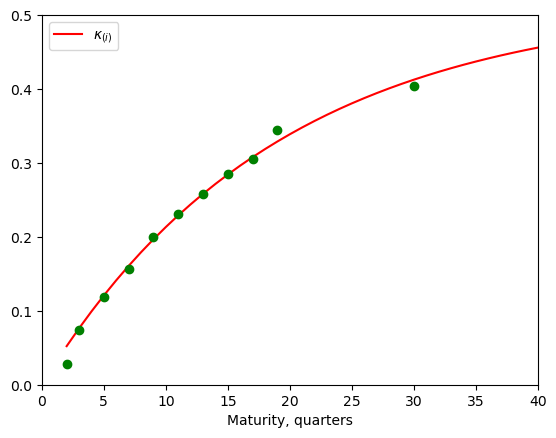

In [132]:

fig, ax = plt.subplots()
ax.set_prop_cycle(color=['red', 'green', 'blue'])
#plt.plot(Loadings_finer[['sigma2', 'kappa_f', 'cov_rX']])

#plt.plot(Original_points[['sigma2', 'kappa_f', 'cov_rX']],
#         'o')

plt.plot(LoadingsMF_finer[[ 'kappa_f1']])

plt.plot(OriginalMF_points[['kappa_f1']],
         'o')

plt.xlabel("Maturity, quarters")

plt.legend([r"$\kappa_{\left(i\right)}$"])



plt.xlim(0, 40)
plt.ylim(0, .5)
plt.savefig(draft_path+"fit_kappa_2fac_1.png")


Text(0.5, 0, 'Maturity, quarters')

(0.0, 40.0)

(0.0, -0.5)

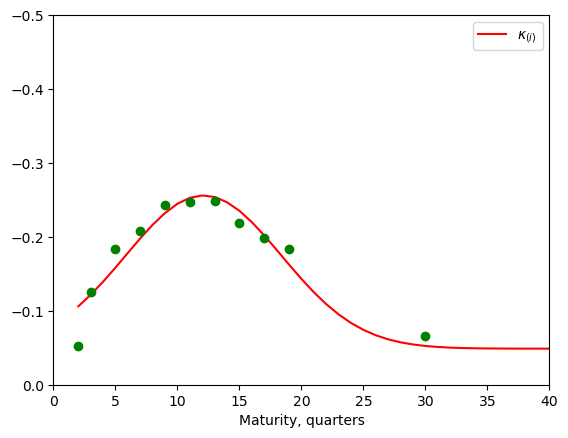

In [133]:
fig, ax = plt.subplots()
ax.set_prop_cycle(color=['red', 'green', 'blue'])
#plt.plot(Loadings_finer[['sigma2', 'kappa_f', 'cov_rX']])

#plt.plot(Original_points[['sigma2', 'kappa_f', 'cov_rX']],
#         'o')

plt.plot(LoadingsMF_finer[[ 'kappa_f2']])

plt.plot(OriginalMF_points[['kappa_f2']],
         'o')

plt.xlabel("Maturity, quarters")

plt.legend([r"$\kappa_{\left(i\right)}$"])


plt.xlim(0, 40)
plt.ylim(0, -.5)

plt.savefig(draft_path+"fit_kappa_2fac_2.png")

### Fiscal Hedging Portfolio
We set the loadings on the slope factor to zero.

<Axes: xlabel='maturities'>

Sum ofX- portfolio = -0.15205310068155647


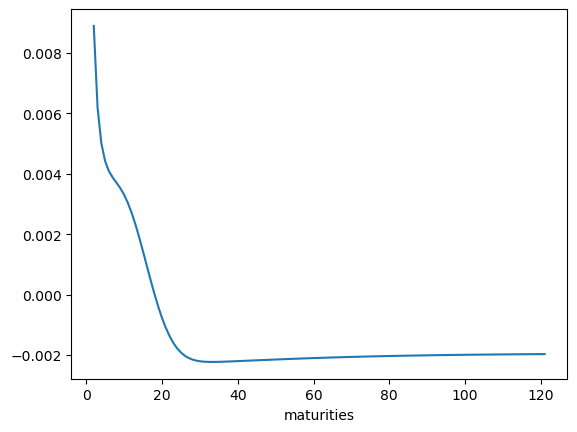

In [134]:
#omega_h_finer=(1/(Qrf* B_T ))*( Upsilon_T *kappa_theta / (1-  beta_hat) -  G_T *kappa_G / (1-  beta_hat) )*np.matmul(Pi_finer,kappa_finer)*sigma2_f

SigmaXMF1Beta=((Upsilon_T*kappa1_theta-G_T *kappa1_G)*kappa1_finer*sigma2_f1) / (1-  beta_hat)
SigmaXMF2Beta=((Upsilon_T*kappa2_theta-G_T *kappa2_G)*kappa2_finer*sigma2_f2) / (1-  beta_hat)


omegaMF_h_finer=(1/(Qrf* B_T ))*np.matmul(PiMF_finer,SigmaXMF1Beta+SigmaXMF2Beta*0)

LoadingsMF_finer['omega_h']=omegaMF_h_finer
LoadingsMF_finer['omega_h'].plot()

print("Sum ofX- portfolio = "+ str(LoadingsMF_finer['omega_h'].sum()))

<Axes: xlabel='maturities'>

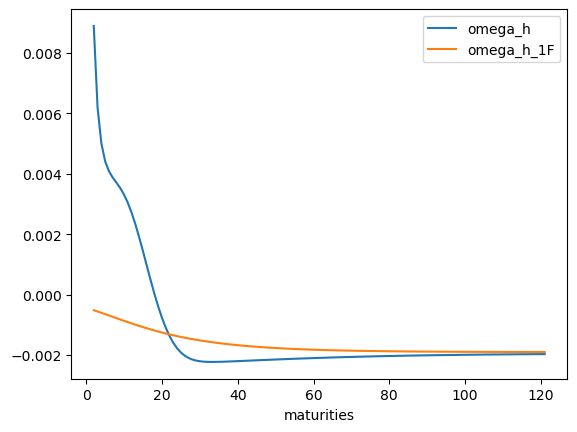

In [135]:
LoadingsMF_finer['omega_h_1F']=Loadings_finer['omega_h']
LoadingsMF_finer[['omega_h','omega_h_1F']].plot()


In [136]:

def  get_SigmaInfty():
    Nm=N*4*4
    maturities= LoadingsMF.maturities
    maturities_finer=np.linspace(2,Nm+1,Nm)
    kappa1_finer=np.zeros(len(maturities_finer))
    kappa2_finer=np.zeros(len(maturities_finer))
    alphaMF_finer=np.zeros(len(maturities_finer))
    sigma2MF_finer=np.zeros(len(maturities_finer))
    sigma2MF_raw_finer=np.zeros(len(maturities_finer))

    for n in maturities_finer:
            kappa1_finer[int(n)-2]=func_kappa1(n)
            kappa2_finer[int(n)-2]=func_kappa2(n)
            
            alphaMF_finer[int(n)-2]=func_alphaMF(n)
            sigma2MF_finer[int(n)-2]=func_sigma2MF(n)        
            sigma2MF_raw_finer[int(n)-2]=func_sigma2MF_raw(n)

    DeltaMF_finer = np.diag(sigma2MF_finer)
    kappaMF_finer=np.vstack((kappa1_finer,kappa2_finer))
    kappaMF_finer=kappaMF_finer.T
    
    PiMF_finer, SigmaMF_finer,SigmaMFalt_finer,PiMFalt_finer = getPiMF(DeltaMF_finer, kappaMF_finer,DeltaMFfac)
    np.save('SigmaMF_finer_tt.npy', SigmaMF_finer)
    np.save('SigmaMFalt_finer_tt.npy', SigmaMFalt_finer)
    np.save('maturities_finer_tt.npy', maturities_finer)
    np.save('alphaMF_finer_tt.npy', alphaMF_finer)
    np.save('kappa1_finer_tt.npy', kappa1_finer)
    np.save('kappa2_finer_tt.npy', kappa2_finer)
        

get_SigmaInfty()         

Sum of Q- portfolio = 1.0045864965065663


1.0045864965065663

<Axes: xlabel='maturities'>

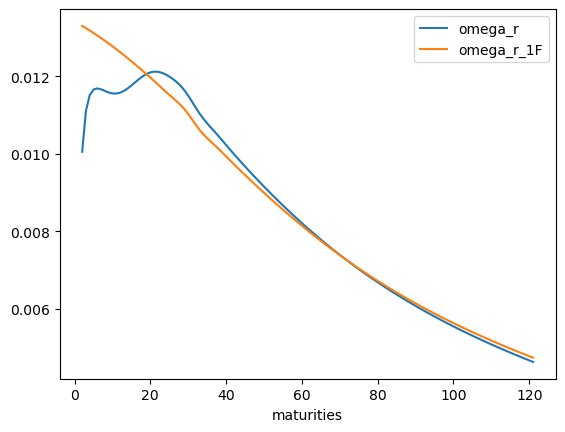

In [137]:
SigmaInfinityMF = np.load('SigmaMF_finer_tt.npy')
SigmaInfinityMFalt = np.load('SigmaMFalt_finer_tt.npy')
maturitiesInfinity = np.load('maturities_finer_tt.npy')
alphaInfinity = np.load('alphaMF_finer_tt.npy')
kappa1Infinity = np.load('kappa1_finer_tt.npy')
kappa2Infinity = np.load('kappa2_finer_tt.npy')
SigmaQMF = SigmaInfinityMF[:120, :]

# s^Q[k] = (Q^k_T \Gamma^k )/(Q^rf_T \sum Q^k_T \Gamma^k)
sQ=np.zeros(len(maturitiesInfinity))
for k in range(len(maturitiesInfinity)):
    sQ[k]=QT(k+1)*Gamma**(k+1)



WMF =  (1-beta_hat)*np.matmul(np.matmul(PiMF_finer, SigmaQMF),sQ)
LoadingsMF_finer['omega_r'] = WMF
LoadingsMF_finer['omega_r_beta'] = (1-beta_hat)*beta_hat**(maturitiesInfinity[:120]-1 )

print("Sum of Q- portfolio = "+ str(LoadingsMF_finer['omega_r'].sum()))
LoadingsMF_finer['omega_r'].sum()


LoadingsMF_finer['omega_r_1F']=Loadings_finer['omega_r_fin']
LoadingsMF_finer[['omega_r','omega_r_1F']].plot()


In [138]:
Loadings_finer

,alpha,kappa_f,sigma2,sigma2_raw,omega_h,omega_h_theta,omega_h_G,omega_r_fin,omega_r_beta,omega_r_QGamma,...,omega_Tr2075,omega_h_Tr1095,omega_r_fin_Tr1095,omega_Tr1095,omega_h_Tr2095,omega_r_fin_Tr2095,omega_Tr2095,omega_ineq,omega_pe_risky,omega_pe_bonds
maturities,,,,,,,,,,,,,,,,,,,,,
2.0000,0.0969,0.0521,0.1350,0.1350,-0.0005,-0.0010,0.0005,0.0133,0.0128,0.0128,...,0.0058,-0.0005,0.0051,0.0046,-0.0005,0.0036,0.0031,0.0000,0.0007,0.0480
3.0000,0.1362,0.0762,0.1825,0.1825,-0.0006,-0.0011,0.0006,0.0132,0.0126,0.0127,...,0.0081,-0.0006,0.0059,0.0053,-0.0006,0.0045,0.0039,0.0000,0.0002,0.0445
4.0000,0.1705,0.0990,0.2202,0.2202,-0.0006,-0.0012,0.0006,0.0132,0.0124,0.0126,...,0.0096,-0.0006,0.0066,0.0060,-0.0006,0.0054,0.0047,0.0000,0.0001,0.0410
5.0000,0.2004,0.1206,0.2502,0.2502,-0.0006,-0.0013,0.0007,0.0131,0.0123,0.0125,...,0.0105,-0.0007,0.0072,0.0065,-0.0007,0.0061,0.0054,0.0000,0.0001,0.0375
6.0000,0.2264,0.1411,0.2740,0.2740,-0.0007,-0.0014,0.0007,0.0130,0.0121,0.0124,...,0.0111,-0.0007,0.0078,0.0070,-0.0007,0.0068,0.0060,0.0000,0.0001,0.0341
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117.0000,0.4036,0.5175,0.3658,0.3658,-0.0019,-0.0038,0.0019,0.0049,0.0029,0.0032,...,0.0031,-0.0020,0.0056,0.0036,-0.0020,0.0058,0.0038,0.0000,0.0000,0.0003
118.0000,0.4036,0.5176,0.3658,0.3658,-0.0019,-0.0038,0.0019,0.0049,0.0028,0.0032,...,0.0030,-0.0020,0.0056,0.0036,-0.0020,0.0057,0.0037,0.0000,0.0000,0.0002
119.0000,0.4036,0.5176,0.3658,0.3658,-0.0019,-0.0038,0.0019,0.0048,0.0028,0.0032,...,0.0030,-0.0020,0.0055,0.0035,-0.0020,0.0057,0.0037,0.0000,0.0000,0.0002


<Axes: xlabel='maturities'>

fraction in the risk free bond


0.14746660417499013

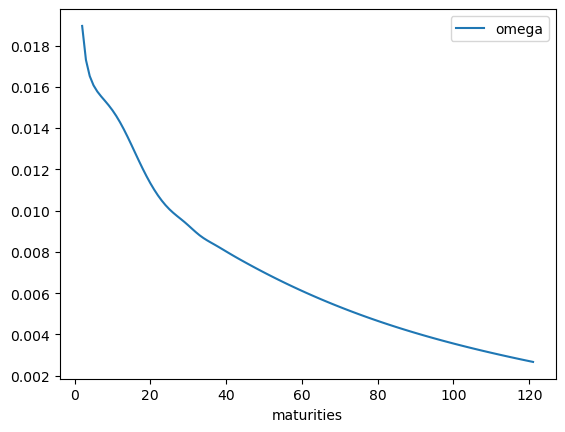

In [139]:
LoadingsMF_finer['omega'] = LoadingsMF_finer['omega_h'] + \
    LoadingsMF_finer['omega_r']
LoadingsMF_finer[['omega']].plot()
print("fraction in the risk free bond")
1-LoadingsMF_finer['omega'].sum()

Loadings_finer["omega_MF"]=LoadingsMF_finer['omega']

In [140]:
tempMF=[]
usdata=(pd.read_csv('../Data/omega_2017.csv').set_index('tmduratn_bin')/100)
tempMF=pd.DataFrame(np.ones(len(Loadings_finer.index)+1))
tempMF.index=range(1,122)
tempMF["omega capped"]=0
tempMF["omega_X"]=0
tempMF["omega_Q"]=0


tempMF["omega_US"]=(pd.read_csv('../Data/omega_2017.csv').set_index('tmduratn_bin')/100)
tempMF["omega_US"]=temp["omega_US"].fillna(0)
tempMF.loc[2:,"omega"]=LoadingsMF_finer.omega.values
tempMF.loc[2:,"omega_X"]=LoadingsMF_finer.omega_h.values
tempMF.loc[1,"omega"]=1-np.sum(LoadingsMF_finer.omega.values)
tempMF.loc[2:,"omega_Q"]=LoadingsMF_finer.omega_r.values
tempMF.loc[2:,"omega_1F"]=Loadings_finer.omega.values
tempMF.loc[2:,"omega_X_1F"]=Loadings_finer.omega_h.values
tempMF.loc[2:,"omega_Q_1F"]=Loadings_finer.omega_r_fin.values
tempMF.loc[2:,"QGamma"]=Loadings_finer.omega_r_QGamma




In [141]:
def plot_fig(
    columns=["omega capped", 'omega_US', 'omega_Q', 'omega_X'], 
    name='u',
    leg=[
        r"target portfolio",
        r"U.S. portfolio", 
        r"$\left(1-\hat{\beta}\right)\mathtt{\overrightarrow{\beta}}$", 
        r"$\left(1-\hat{\beta}\right)\mathtt{\overrightarrow{\beta}}$"
    ],
    T=None,
    Max_y=6.0,
    col=['darkred', 'black', 'darkseagreen'],
    marker=['None', 'None', 'None'],
    markersize=['3', '1', '2'],
    linestyle=['--', '-', '-.'],
    alpha=[0.5, 0.6, 0.7]
):
    # Create a copy of the data to avoid modifying the original DataFrame
    data_to_plot = tempMF[columns].copy() * 100

    if T is None:
        T = len(tempMF)

    fig, ax = plt.subplots()

    # Iterate over each column and plot with specified alpha
    for i, col_name in enumerate(columns):
        ax.plot(
            data_to_plot[col_name],  # Use the copied data
            color=col[i % len(col)], 
            lw=1, 
            linestyle=linestyle[i % len(linestyle)], 
            marker=marker[i % len(marker)], 
            markersize=float(markersize[i % len(markersize)]),
            alpha=alpha[i % len(alpha)]
        )
    
    columns = [x.replace('omega_', '') for x in columns]
    columns = [x.replace('gr', 'base') for x in columns]
    leg = leg
    
    fig.set_dpi(200)
    plt.xlim(2, T)
    plt.ylim(-0.5, Max_y)
    plt.xlabel("Maturity, quarters")
    plt.ylabel("Portfolio share, percent")
    plt.legend(leg)
    fig.savefig(draft_path + "{}.pdf".format(name))

    return fig


### FIGURE 3 (a): ROLE OF MULTIPLE FACTOR

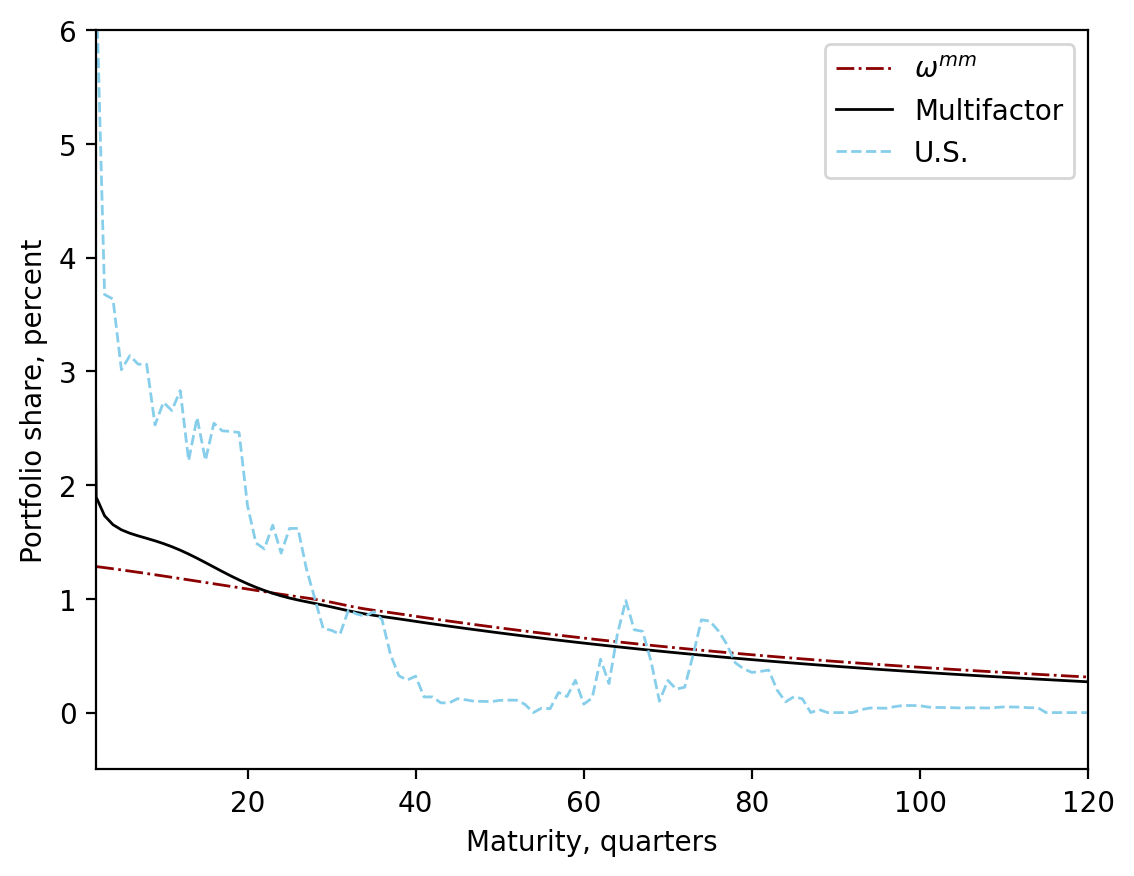

In [142]:
fig_1 = plot_fig(name='multifactor', T=120, Max_y=6,marker=['None', 'None','None'],markersize=['2','1','1'],   linestyle=['-.', '-','--']         ,
columns=[
    'QGamma', "omega","omega_US" ], leg=[ r"$\omega^{mm}$", r"Multifactor", "U.S."],col=['darkred',  'black','skyblue'], alpha=[1, 1,1])


In [143]:
Macaulay=tempMF.reset_index()
Mc_US=(Macaulay['omega_US']*Macaulay['index']/4).sum()
Mc_th = (Macaulay['omega'] * Macaulay['index'] / 4).sum()
print("Mc_US={}".format(Mc_US))
print("Mcaulay target={}".format(Mc_th))

Mc_US=5.285136107905255
Mcaulay target=9.351803647074497


In [144]:
Loadings_finer["omega_MF"]=LoadingsMF_finer['omega']

In [145]:
Reg_table=LoadingsMF.reset_index(drop=True)
Reg_table['maturities']=Reg_table['maturities']*3
Reg_table.loc[10,'maturities']=120

Reg_table = Reg_table[["maturities", "kappa_f1", "se_kappa_f1", "kappa_f2", "se_kappa_f2","sigma2","std_simga2", "R2"]]
Reg_table.loc[len(Reg_table.index)]=["G",LoadingsMF.kappa1_G[0],LoadingsMF.se_kappa1_G[0],LoadingsMF.kappa2_G[0],LoadingsMF.se_kappa2_G[0],LoadingsMF.sigma_G[0],LoadingsMF.sigma_G_se[0],LoadingsMF.R2_G[0]]
Reg_table.loc[len(Reg_table.index)]=["Theta",LoadingsMF.kappa1_theta[0],LoadingsMF.se_kappa1_theta[0],LoadingsMF.kappa2_theta[0],LoadingsMF.se_kappa2_theta[0],LoadingsMF.sigma_theta[0],LoadingsMF.sigma_theta_se[0],LoadingsMF.R2_theta[0]]
Reg_table=Reg_table.T

In [146]:
Reg_table=LoadingsMF.reset_index(drop=True)
Reg_table['maturities']=Reg_table['maturities']*3
Reg_table.loc[10,'maturities']=120

Reg_table = Reg_table[["maturities", "kappa_f1", "se_kappa_f1", "kappa_f2", "se_kappa_f2","sigma2","std_simga2", "R2"]]
Reg_table.loc[len(Reg_table.index)]=["G",LoadingsMF.kappa1_G[0],LoadingsMF.se_kappa1_G[0],LoadingsMF.kappa2_G[0],LoadingsMF.se_kappa2_G[0],LoadingsMF.sigma_G[0],LoadingsMF.sigma_G_se[0],LoadingsMF.R2_G[0]]
Reg_table.loc[len(Reg_table.index)]=["Theta",LoadingsMF.kappa1_theta[0],LoadingsMF.se_kappa1_theta[0],LoadingsMF.kappa2_theta[0],LoadingsMF.se_kappa2_theta[0],LoadingsMF.sigma_theta[0],LoadingsMF.sigma_theta_se[0],LoadingsMF.R2_theta[0]]
Reg_table=Reg_table.T
Reg_table.to_csv(draft_path+'Reg_table_MF.csv')

In [147]:
LoadingsMF.to_csv('LoadingsMF.csv')

## 7. Extension: Role of noise term

Our statistical model of returns allows for a noise term for each return that is orthogonal to the factor. This noise term affects the covariance matrix of returns, $\Sigma$.  In particular, it makes the inverse of the covariance matrix of returns full rank. To examine the role of the noise terms, we estimate the covariance and inv covariance of returns without the noise terms. 
Thus 
$$\Sigma^{\Delta=0}=\kappa\Delta_{f}\kappa^{\intercal}$$

Obviously, we have many returns and few factors, so the covariance matrix without the noisse term is not invertible. One way to say this is that a system $\Sigma^{\Delta=0} x=b$ will have many solutions $x$. 

To handle this issue we take the ``pusedo inverse.'' The psuedo inverse $\Sigma^{\Delta=0,-1}$ is such that $\Sigma^{\Delta=0,-1}b$ always picks the solution with the smallest l2 norm for any $b$. 

We then use $\Sigma^{\Delta=0,-1}$ in our formulas 


### One Factor Model

We will compute 3 versions of the portfolios

* Baseline

* pusedoinverse: Set orthogonal terms to zero and use pinv to compute the inverse covariance matrix

* limit:  Multiply the orthogonal terms with a scaling parameter and take limit as the scaling parameter is zero

For the fiscal hedging and liquidity terms we just need to recompute the "shapeterm:"

 $$ \sigma^2_f \Sigma^{-1}_T \vec{\kappa} = \left(\frac{\kappa_{j}}{\sigma_{j}^{2}}\chi^{2}\right)$$

where $\chi^{-2}=\sigma_{f}^{-2}+\sum_{i\in\mathcal{G}}\kappa_{i}^{2}\sigma_{i}^{-2}$


In [148]:
# define 1/X^2
invX2 = 1/sigma2_f+np.sum((Loadings_finer.kappa_f**2/Loadings_finer.sigma2))
# construct the vectpr $\Chi^2 \times(\kappa_j/sigma^2_j)$ where \Chi^2 is 1/invX2, \kappa_j=Loadings_finer.kappa_f and sigma^2_j=Loadings_finer.sigma2
Chi2 = 1 / invX2
# Calculate kappa_j/sigma^2_j
ratio = Loadings_finer.kappa_f / Loadings_finer.sigma2
# Construct the vector 
shapeterm = Chi2 * ratio
# contruct the difference between the vector and np.matmul(Pialt_finer,kappa_finer)*sigma2_f
#diff = shapeterm - np.matmul(Pi_finer, kappa_finer)*sigma2_f
#print("The difference between the shapeterm and np.matmul(Pi_finer,kappa_finer)*sigma2_f is {}".format(diff))
Loadings_finer['shapeterm'] = shapeterm


#### contruct the shape term with $\Sigma^{-1}_T$ using the pusedo inverse. 

$$ \Sigma^{-1}_T = \frac{\Sigma_T}{\left[Tr(\Sigma_T)\right]^2}  $$

In [149]:
Sigmaalt_finer=np.outer(Loadings_finer.kappa_f,Loadings_finer.kappa_f)*sigma2_f
Pi_finer_pinv=Sigmaalt_finer/np.trace(Sigmaalt_finer)**2
#check Pi_finer_pinv
np.sum(np.abs(Pi_finer_pinv - np.linalg.pinv(Sigmaalt_finer)))

1.5608765809977624e-17

In [150]:
shapeterm_pinv=np.matmul(Pi_finer_pinv,kappa_finer)*sigma2_f
Loadings_finer['shapeterm_pinv']=shapeterm_pinv

#### construct the shape term as a function of $\{(\mathrm{d}\sigma_j)^2\}_j$ as $\mathrm{d}\to 0$

$$\left(\frac{\kappa_{j}}{\sigma_{j}^{2}}\chi^{2}\right)=\frac{\kappa_{j}\mathrm{d^{-2}}\sigma_{j}^{-2}}{\sigma_{f}^{-2}+\sum_{i\in\mathcal{G}}\mathrm{d^{-2}}\kappa_{i}^{2}\sigma_{i}^{-2}}\to\kappa_{j}\left(\frac{\sigma_{j}^{-2}}{\sum_{i\in\mathcal{G}}\kappa_{i}^{2}\sigma_{i}^{-2}}\right)$$


In [151]:
# now construct the shape term as the sigma_j=sigma_j*d and d approaches zero
d = 1.0/1000
invX2_lim = 1/sigma2_f+np.sum((Loadings_finer.kappa_f**2/((d**2) * Loadings_finer.sigma2)))
# construct the vectpr $\Chi^2 \times(\kappa_j/sigma^2_j)$ where \Chi^2 is 1/invX2, \kappa_j=Loadings_finer.kappa_f and sigma^2_j=Loadings_finer.sigma2
Chi2_lim = 1 / invX2_lim
# Calculate kappa_j/sigma^2_j
ratio_lim = Loadings_finer.kappa_f / ( (d**2) *Loadings_finer.sigma2)
# Construct the vector 
shapeterm_lim = Chi2_lim * ratio_lim

Loadings_finer['shapeterm_lim'] = shapeterm_lim
# diff shapeterm and shapeterm_lim
diff_shapeterm = shapeterm - shapeterm_lim
print("The difference between the shapeterm and shapeterm_lim is {}".format(np.sum(np.abs(diff_shapeterm))))


The difference between the shapeterm and shapeterm_lim is 0.0004907314812576885


<Axes: xlabel='maturities'>

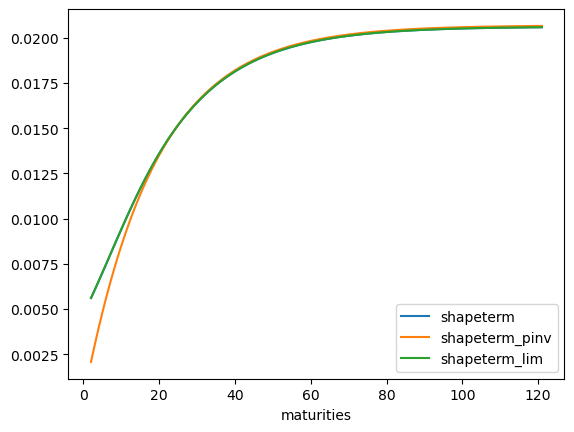

In [152]:

#plot shapeterm and shapeterm_lim
Loadings_finer[['shapeterm','shapeterm_pinv','shapeterm_lim']].plot()


#### Construct  the Fiscal Hedging and Liquidity Hedging portfolios

<Axes: xlabel='maturities'>

Sum ofX- portfolio (no noise )= omega_h_pinv   -0.2064
omega_h_lim    -0.2079
omega_h        -0.1975
dtype: float64


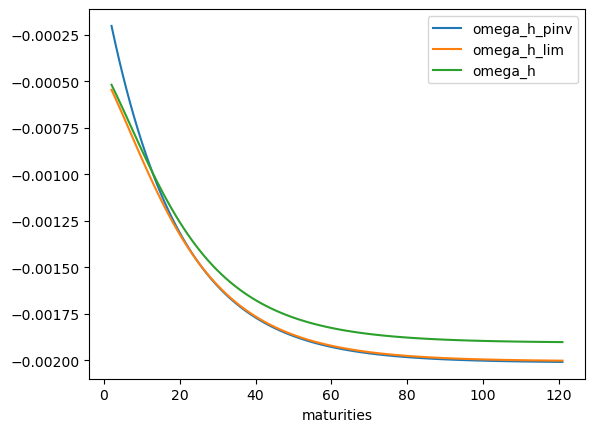

In [153]:
#omegaMF_h_finer=(1/(Qrf* B_T ))*np.matmul(PiMF_finer,SigmaXMF1Beta+SigmaXMF2Beta*0)

omega_h_finer_inv=(1/(Qrf* B_T ))*( Upsilon_T *kappa_theta / (1-  beta_hat) -  G_T *kappa_G*Gamma*Pii / (1-  beta_hat) )*shapeterm_pinv
omega_h_finer_lim= (1/(Qrf* B_T ))*( Upsilon_T *kappa_theta / (1-  beta_hat) -  G_T *kappa_G*Gamma*Pii / (1-  beta_hat) )*shapeterm_lim

Loadings_finer['omega_h_pinv']=omega_h_finer_inv
Loadings_finer['omega_h_lim']=omega_h_finer_lim

Loadings_finer[['omega_h_pinv','omega_h_lim','omega_h']].plot()

print("Sum ofX- portfolio (no noise )= "+ str(Loadings_finer[['omega_h_pinv','omega_h_lim','omega_h']].sum()))

#### Construct  the interest rate hedging terms

* Baseline: $\pi^Q \Sigma_{T}^{-1}\Sigma_{T}^{Q}\overrightarrow{\beta}\left[j\right]=(1-\hat{\beta})\hat{\beta}^{j}+ (1-\hat{\beta})\sum_{t\notin\mathcal{G}}\hat{\beta}^{t}\kappa_{t} \left(\frac{\kappa_{j}}{\sigma_{j}^{2}}\chi^{2}\right)$

* Baseline: $\pi^Q \Sigma_{T}^{-1}\Sigma_{T}^{Q}\overrightarrow{\beta}\left[j\right]=(1-\hat{\beta})\hat{\beta}^{j}+ (1-\hat{\beta})  \sum_{t\notin\mathcal{G}}\hat{\beta}^{t}\kappa_{t}\kappa_{j}\left(\frac{\sigma_{j}^{-2}}{\sum_{i\in\mathcal{G}}\kappa_{i}^{2}\sigma_{i}^{-2}}\right)$

* pusedoinverse: $(1-\hat{\beta})\left(\frac{\sum\kappa_{t}\hat{\beta}^{t}}{\sigma_{f}^{2}\sum_{\ell\in\mathcal{G}}\kappa_{\ell}^{2}}\right)\begin{bmatrix}\kappa_{1}\\
\kappa_{2}\\
\kappa_{3}\\
\vdots\\
\kappa_{T}
\end{bmatrix}$

In [154]:

def  get_kappainf():
    N=500
    maturitiesInfinity=np.linspace(2,N*4+1,N*4)
    kappaInfinity=np.zeros(len(maturitiesInfinity))
    sigma2Infinity=np.zeros(len(maturitiesInfinity))
 
    for n in maturitiesInfinity:
            kappaInfinity[int(n)-2]=func_kappa(n)
            #alpha_finer[int(n)-2]=func_alpha(n)
            sigma2Infinity[int(n)-2]=func_sigma2(n)        
            #sigma2_raw_finer[int(n)-2]=func_sigma2_raw(n)

    return kappaInfinity,sigma2Infinity,maturitiesInfinity
           

kappaInfinity,sigma2Infinity,maturitiesInfinity=get_kappainf()

In [155]:
# compute pinv interest rate hedging portfolio
# SigmaInfininity
SigmaInfinity_inv = np.outer(kappaInfinity, kappaInfinity)*sigma2_f
SimgaQ_inv=SigmaInfinity_inv[:120,:]
# betaInfinity
betaInfinity = beta_hat**(maturitiesInfinity-1)

# omega_r_finer_inv
omega_r_finer_inv1 = (1-beta_hat) * np.matmul(np.matmul(Pi_finer_pinv, SimgaQ_inv),
                         (beta_hat)**(maturitiesInfinity-1))

# \sum_{i=1}^{\infty} \beta_i \kappa_i 
betaInfinitykappaInfinity = np.sum(betaInfinity*kappaInfinity)
#sum_{i=1}^{120} kappa_i*kappa_i*sigma2_f
traceSimga = np.trace(np.outer(Loadings_finer.kappa_f,Loadings_finer.kappa_f))
omega_r_finer_inv = (1-beta_hat)*kappaInfinity[0:120]*betaInfinitykappaInfinity/traceSimga

# plot the diff between omega_r_finer_inv1 and omega_r_finer_inv2
#plt.plot(omega_r_finer_inv1-omega_r_finer_inv2)
Loadings_finer['omega_r_finer_inv'] = omega_r_finer_inv
#Loadings_finer['omega_r_finer_inv'].plot()

In [156]:
# compute the limiting interest rate portfolio 
d=1.0/1000
Sigma_finer_lim = np.outer(Loadings_finer.kappa_f, Loadings_finer.kappa_f)*(sigma2_f)+np.diag((d**2)*Loadings_finer.sigma2)
SigmaInfinity_lim = np.outer(kappaInfinity, kappaInfinity)*(sigma2_f)+np.diag((d**2)*sigma2Infinity)
SimgaQ_lim=SigmaInfinity_lim[:120,:]
Pi_finer_lim=np.linalg.inv(Sigma_finer_lim)
#omega_r_finer_lim
omega_r_finer_lim = (1-beta_hat) * np.matmul(np.matmul(Pi_finer_lim, SimgaQ_lim),
                         (beta_hat)**(maturitiesInfinity-1))
Loadings_finer['omega_r_finer_lim'] = omega_r_finer_lim

In [157]:
# compute the limiting interest rate portfolio using formula

ratio_lim = Loadings_finer.kappa_f / ((d**2)*Loadings_finer.sigma2)
# sum beta_i*kappa_i for i=121 to infinity
betaInfinitykappaInfinity_lim = np.sum(betaInfinity[120:]*kappaInfinity[120:])
# sum kappa_i*kappa_i/sigma_i for i=0 to 120
traceSimga_lim = np.sum(Loadings_finer.kappa_f**2/((d**2)*Loadings_finer.sigma2))

omega_r_finer_lim2 = (1-beta_hat)*beta_hat**(Loadings_finer.index-1)+ (1-beta_hat)*betaInfinitykappaInfinity_lim/traceSimga_lim*ratio_lim

<Axes: xlabel='maturities'>

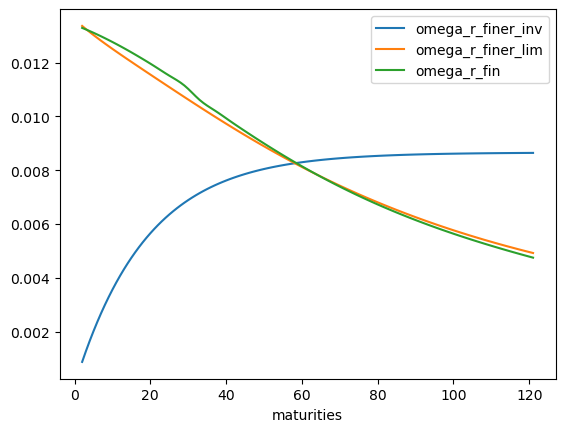

In [158]:
Loadings_finer[['omega_r_finer_inv','omega_r_finer_lim','omega_r_fin']].plot()

#### Compare the 3 portfolios

<Axes: xlabel='maturities'>

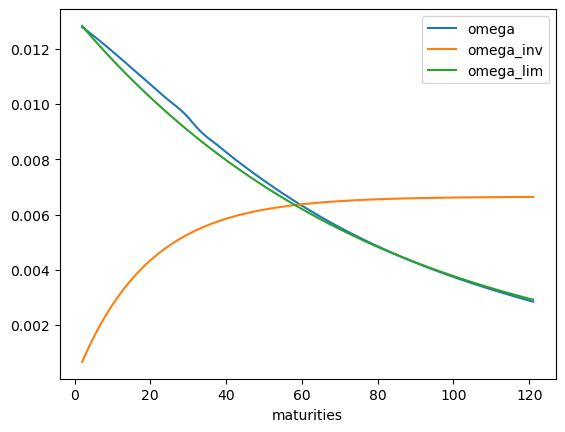

In [159]:
Loadings_finer['omega_inv']=Loadings_finer['omega_h_pinv']+Loadings_finer['omega_r_finer_inv']
Loadings_finer['omega_lim']=Loadings_finer['omega_h_lim']+Loadings_finer['omega_r_finer_lim']
# plot omega, omega_inv and omega_lim
Loadings_finer[['omega','omega_inv','omega_lim']].plot()

####  check
Suppose that we set $\{\sigma_{j}\}$ to zero and computed the residuals in $$ \Sigma \omega_{lim} -(\pi^Q \Sigma^Q+\pi^X \Sigma^X+\pi^A\Sigma^A) $$ 


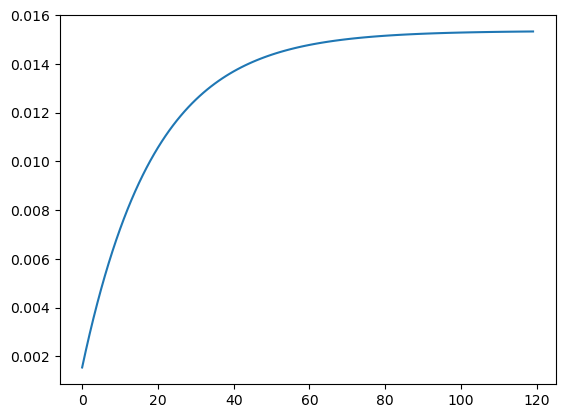

In [160]:

#omega_h_finer_inv=(1/(Qrf* B_T ))*( Upsilon_T *kappa_theta / (1-  beta_hat) -  G_T *kappa_G*Gamma*Pii / (1-  beta_hat) )*shapeterm_pinv

Sigma_dzero=np.outer(Loadings_finer.kappa_f,Loadings_finer.kappa_f)*sigma2_f

check=Sigma_dzero@omega_h_finer_lim-(1/(Qrf* B_T )*( Upsilon_T *kappa_theta / (1-  beta_hat) -  G_T *kappa_G / (1-  beta_hat) )*Loadings_finer.kappa_f.values*sigma2_f)
plt.plot(check)


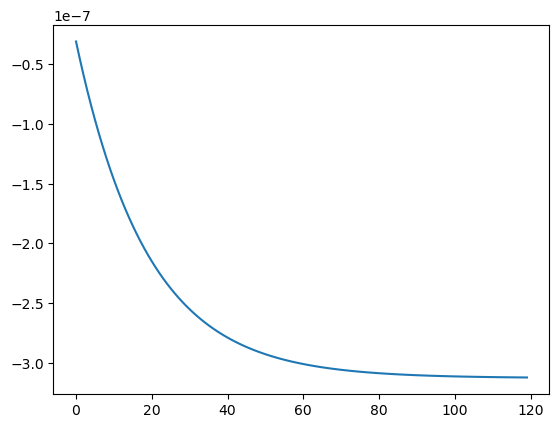

In [161]:
SigmaInfinity_dzero = np.outer(kappaInfinity, kappaInfinity)*(sigma2_f)

check=Sigmaalt_finer@omega_r_finer_lim-((1-beta_hat)*SigmaInfinity_dzero[:120,:]@(beta_hat)**(maturitiesInfinity-1))
plt.plot(check)

In [162]:
print("fraction in the risk free bond")
1-Loadings_finer[['omega','omega_inv','omega_lim']].sum()

fraction in the risk free bond


omega       0.1808
omega_inv   0.3182
omega_lim   0.1984
dtype: float64

In [166]:
tempLim=[]
usdata=(pd.read_csv('../Data/omega_2017.csv').set_index('tmduratn_bin')/100)
tempLim=pd.DataFrame(np.ones(len(Loadings_finer.index)+1))
tempLim.index=range(1,122)
tempLim["omega"]=0
tempLim["omega_inv"]=0
tempLim["omega_lim"]=0


tempLim["omega_US"]=(pd.read_csv('../Data/omega_2017.csv').set_index('tmduratn_bin')/100)
tempLim["omega_US"]=tempLim["omega_US"].fillna(0)
tempLim.loc[2:,"omega"]=Loadings_finer.omega.values
tempLim.loc[2:,"omega_inv"]=Loadings_finer.omega_inv.values
tempLim.loc[2:,"omega_lim"]=Loadings_finer.omega_lim.values
tempLim.loc[1,"omega"]=1-np.sum(Loadings_finer.omega.values)
tempLim.loc[1,"omega_inv"]=1-np.sum(Loadings_finer.omega_inv.values)
tempLim.loc[1,"omega_lim"]=1-np.sum(Loadings_finer.omega_lim.values)


In [167]:
def plot_fig(
    columns=["omega capped", 'omega_US', 'omega_Q', 'omega_X'], 
    name='u',
    leg=[
        r"target portfolio",
        r"U.S. portfolio", 
        r"$\left(1-\hat{\beta}\right)\mathtt{\overrightarrow{\beta}}$", 
        r"$\left(1-\hat{\beta}\right)\mathtt{\overrightarrow{\beta}}$"
    ],
    T=None,
    Max_y=6.0,
    col=['darkred', 'black', 'darkseagreen'],
    marker=['None', 'None', 'None'],
    markersize=['3', '1', '2'],
    linestyle=['--', '-', '-.'],
    alpha=[0.5, 0.6, 0.7]
):
    # Create a copy of the data to avoid modifying the original DataFrame
    data_to_plot = tempLim[columns].copy() * 100

    if T is None:
        T = len(tempLim)

    fig, ax = plt.subplots()

    # Iterate over each column and plot with specified alpha
    for i, col_name in enumerate(columns):
        ax.plot(
            data_to_plot[col_name],  # Use the copied data
            color=col[i % len(col)], 
            lw=1, 
            linestyle=linestyle[i % len(linestyle)], 
            marker=marker[i % len(marker)], 
            markersize=float(markersize[i % len(markersize)]),
            alpha=alpha[i % len(alpha)]
        )
    
    columns = [x.replace('omega_', '') for x in columns]
    columns = [x.replace('gr', 'base') for x in columns]
    leg = leg
    
    fig.set_dpi(200)
    plt.xlim(2, T)
    plt.ylim(-0.5, Max_y)
    plt.xlabel("Maturity, quarters")
    plt.ylabel("Portfolio share, percent")
    plt.legend(leg)
    fig.savefig(draft_path + "{}.pdf".format(name))

    return fig


### Two Factor Model

In [168]:
d=1.0/1000
kappaMF_finer=np.vstack((kappa1_finer,kappa2_finer))
DeltaMF_finer = np.diag(sigma2MF_finer)
kappaMF_finer=kappaMF_finer.T
DeltaMFfac_finer=np.diag( (sigma2_f1,sigma2_f2) )
SigmaMF_finer_lim=(d**2)*DeltaMF_finer+np.matmul(np.matmul(kappaMF_finer,DeltaMFfac_finer),kappaMF_finer.T)
PiMF_finer_lim=np.linalg.inv(SigmaMF_finer_lim)


<Axes: xlabel='maturities'>

Sum ofX- portfolio = omega_h_pinv   -0.1590
omega_h_lim    -0.1501
omega_h        -0.1521
dtype: float64


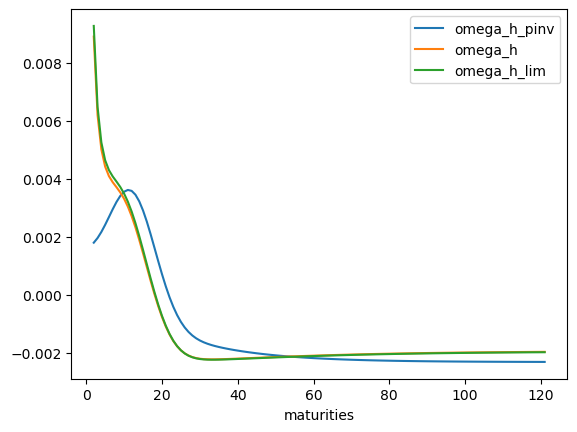

In [169]:
#1/(Qrf* B_T )
omegaMF_h_finer_pinv=(1/(Qrf* B_T ))*np.matmul(PiMFalt_finer,SigmaXMF1Beta+SigmaXMF2Beta*0)
omegaMF_h_finer_lim=(1/(Qrf* B_T ))*np.matmul(PiMF_finer_lim,SigmaXMF1Beta+SigmaXMF2Beta*0)


LoadingsMF_finer['omega_h_pinv']=omegaMF_h_finer_pinv
LoadingsMF_finer['omega_h_lim']=omegaMF_h_finer_lim
LoadingsMF_finer[['omega_h_pinv','omega_h','omega_h_lim']].plot()

print("Sum ofX- portfolio = "+ str(LoadingsMF_finer[['omega_h_pinv','omega_h_lim','omega_h']].sum()))

In [170]:

def  get_SigmaInfty_lim(d):
    Nm=N*4*4
    maturitiesInfinity=np.linspace(2,Nm+1,Nm)
    kappa1Infinity=np.zeros(len(maturitiesInfinity))
    kappa2Infinity=np.zeros(len(maturitiesInfinity))
    sigma2MFInfinity=np.zeros(len(maturitiesInfinity))

    for n in maturitiesInfinity:
            kappa1Infinity[int(n)-2]=func_kappa1(n)
            kappa2Infinity[int(n)-2]=func_kappa2(n)
            
            sigma2MFInfinity[int(n)-2]=func_sigma2MF(n)*(d**2)        

    DeltaMFInfinity = np.diag(sigma2MFInfinity)
    kappaMFInfinity=np.vstack((kappa1Infinity,kappa2Infinity))
    kappaMFInfinity=kappaMFInfinity.T
    
    PiMFInfinity, SigmaMFInfinity,SigmaMFInfinity,PiMFaltInfinity = getPiMF(DeltaMFInfinity, kappaMFInfinity,DeltaMFfac)
    return SigmaMFInfinity,maturitiesInfinity
        



In [171]:
SigmaInfinityMF_lim,maturitiesInfinity=get_SigmaInfty_lim(d)
SigmaQMF_lim = SigmaInfinityMF_lim[:120, :]

WMF_lim = (1-beta_hat) * np.matmul(np.matmul(PiMF_finer_lim, SigmaQMF_lim),
                             (beta_hat)**(maturitiesInfinity-1))
LoadingsMF_finer['omega_r_lim'] = WMF_lim


In [172]:

SigmaQMFalt = SigmaInfinityMFalt[:120, :]

WMFalt = (1-beta_hat) * np.matmul(np.matmul(PiMFalt_finer, SigmaQMFalt),
                             (beta_hat)**(maturitiesInfinity-1))
LoadingsMF_finer['omega_r_pinv'] = WMFalt


<Axes: xlabel='maturities'>

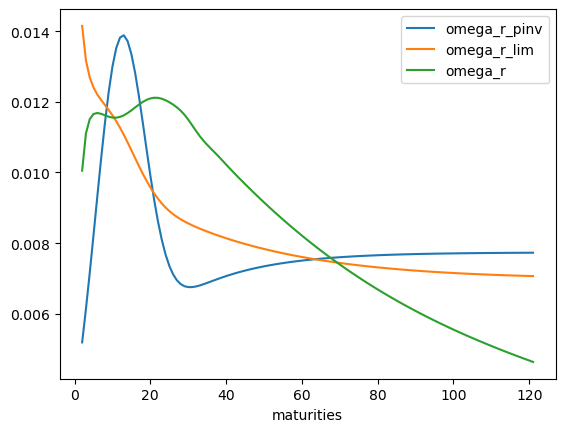

In [173]:
LoadingsMF_finer[['omega_r_pinv','omega_r_lim','omega_r']].plot()

<Axes: xlabel='maturities'>

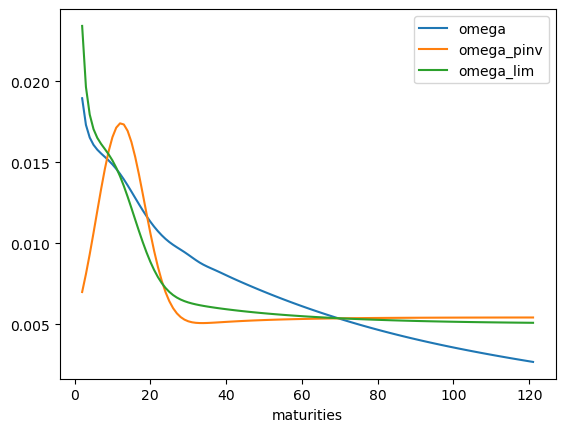

In [174]:
LoadingsMF_finer['omega_pinv'] =  LoadingsMF_finer['omega_h_pinv']+LoadingsMF_finer['omega_r_pinv']
LoadingsMF_finer['omega_lim'] =  LoadingsMF_finer['omega_h_lim']+LoadingsMF_finer['omega_r_lim']
LoadingsMF_finer[['omega','omega_pinv','omega_lim']].plot()

In [176]:
tempLimMF=[]
usdata=(pd.read_csv('../Data/omega_2017.csv').set_index('tmduratn_bin')/100)
tempLimMF=pd.DataFrame(np.ones(len(LoadingsMF_finer.index)+1))
tempLimMF.index=range(1,122)
tempLimMF["omega"]=0
tempLimMF["omega_inv"]=0
tempLimMF["omega_lim"]=0


tempLimMF["omega_US"]=(pd.read_csv('../Data/omega_2017.csv').set_index('tmduratn_bin')/100)
tempLimMF["omega_US"]=tempLimMF["omega_US"].fillna(0)
tempLimMF.loc[2:,"omega"]=LoadingsMF_finer.omega.values
tempLimMF.loc[2:,"omega_inv"]=LoadingsMF_finer.omega_pinv.values
tempLimMF.loc[2:,"omega_lim"]=LoadingsMF_finer.omega_lim.values
tempLimMF.loc[2:,"QGamma"] = Loadings_finer.omega_r_QGamma.values
tempLimMF.loc[1,"omega"]=1-np.sum(LoadingsMF_finer.omega.values)
tempLimMF.loc[1,"omega_inv"]=1-np.sum(LoadingsMF_finer.omega_pinv.values)
tempLimMF.loc[1,"omega_lim"]=1-np.sum(LoadingsMF_finer.omega_lim.values)


In [177]:
def plot_fig(
    columns=["omega capped", 'omega_US', 'omega_Q', 'omega_X'], 
    name='u',
    leg=[
        r"target portfolio",
        r"U.S. portfolio", 
        r"$\left(1-\hat{\beta}\right)\mathtt{\overrightarrow{\beta}}$", 
        r"$\left(1-\hat{\beta}\right)\mathtt{\overrightarrow{\beta}}$"
    ],
    T=None,
    Max_y=6.0,
    col=['darkred', 'black', 'darkseagreen'],
    marker=['None', 'None', 'None'],
    markersize=['3', '1', '2'],
    linestyle=['--', '-', '-.'],
    alpha=[0.5, 0.6, 0.7]
):
    # Create a copy of the data to avoid modifying the original DataFrame
    data_to_plot = tempLimMF[columns].copy() * 100

    if T is None:
        T = len(tempLimMF)

    fig, ax = plt.subplots()

    # Iterate over each column and plot with specified alpha
    for i, col_name in enumerate(columns):
        ax.plot(
            data_to_plot[col_name],  # Use the copied data
            color=col[i % len(col)], 
            lw=1, 
            linestyle=linestyle[i % len(linestyle)], 
            marker=marker[i % len(marker)], 
            markersize=float(markersize[i % len(markersize)]),
            alpha=alpha[i % len(alpha)]
        )
    
    columns = [x.replace('omega_', '') for x in columns]
    columns = [x.replace('gr', 'base') for x in columns]
    leg = leg
    
    fig.set_dpi(200)
    plt.xlim(2, T)
    plt.ylim(-0.5, Max_y)
    plt.xlabel("Maturity, quarters")
    plt.ylabel("Portfolio share, percent")
    plt.legend(leg)
    fig.savefig(draft_path + "{}.pdf".format(name))

    return fig


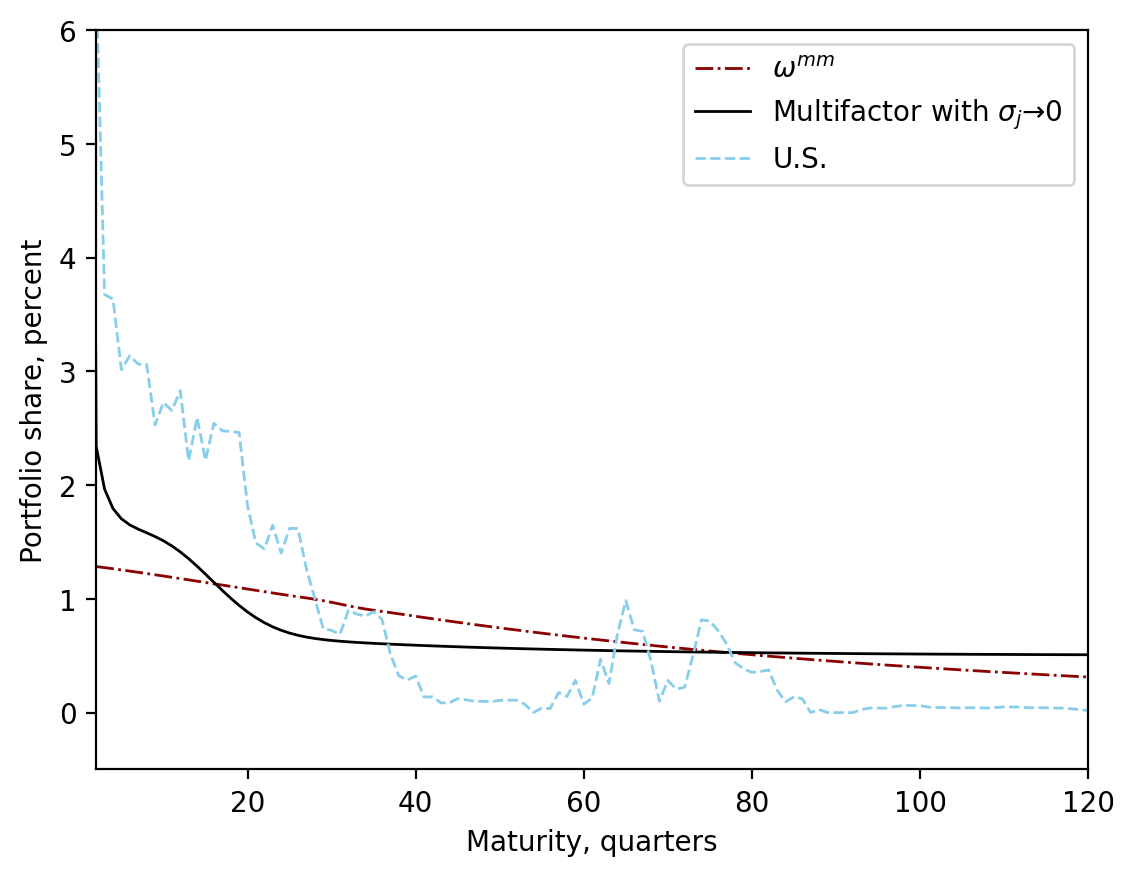

In [178]:
fig_1 = plot_fig(name='noise', T=120, Max_y=6,marker=['None', 'None','None'],markersize=['2','1','1'],   linestyle=['-.', '-','--'],columns=[
    'QGamma', "omega_lim","omega_US" ], leg=[ r"$\omega^{mm}$", r"Multifactor with $\sigma_j\to0$", "U.S."],col=['darkred',  'black','skyblue'], alpha=[1, 1,1])


#### Figure 3 (b)

In [179]:

print("fraction in the risk free bond")
1-LoadingsMF_finer[['omega','omega_pinv','omega_lim']].sum()

fraction in the risk free bond


omega        0.1475
omega_pinv   0.1915
omega_lim    0.1615
dtype: float64

In [180]:
Loadings_finer.to_csv("Loadings_finer.csv")

## 8. Extension: N=50 years

In [181]:
B_T=4.0
Gamma=1.005
tau_T=0.3
gamma=0.5
G_T=.15
Pii=1.0
N=50


### Target portfolio with N=50

77.33201605430494
0.9870687452490858


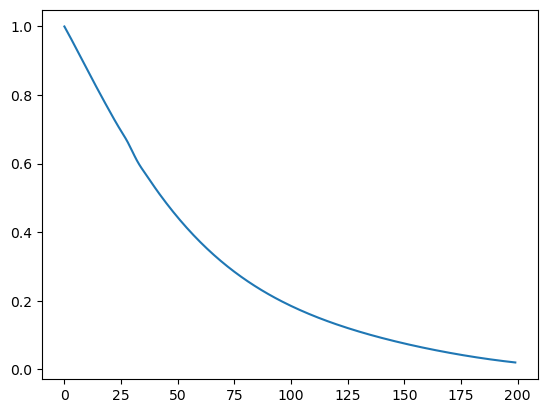

In [182]:

#plot QT for n=0 to N
plt.plot(range(0,N*4,1),[QT(n) for n in range(0,N*4,1)])
PVQ=0
for n in range(0,500,1):
    PVQ+=QT(n+1)*Gamma**(n+1)
print(PVQ)
beta_hat=1-1/PVQ
print(beta_hat)


#### finding the optimal tau
We use 
$$\tau_{T}^{*}\left(1-\tau_{T}^{*}\right)^{1-\gamma}=\frac{B_{T}+G_{T}\sum_{t=1}^{\infty}Q_{T}^{t}\mathbb{E}_{T}\frac{G_{T+t}}{G_{T}}}{\left(1-\tau_{T}\right)^{-\gamma}\sum_{t=1}^{\infty}Q_{T}^{t}\mathbb{E}_{T}\frac{\theta_{T+t}}{\theta_{T}}}$$



In [183]:
Nm=N*4*4
def res_tau(tau):
    LHS=tau*(1-tau)**(1-gamma)
    PVG=0
    PVTheta=0
    for t in range(1,Nm):
        PVG+=QT(t)*Gamma**(t)*G_T
        PVTheta+=QT(t)*Gamma**(t)*(1-tau_T)**(-gamma)
    RHS=(B_T+PVG)/PVTheta
    return LHS-RHS

taustar=optimize.fsolve(res_tau,0.3)[0]
print("the optimal tau is")
print(taustar)

Upsilonstar=taustar*(1-tau_T)**(-gamma)*(1-taustar)**(1-gamma)
print("the optimal Upsilon is")
print(Upsilonstar)
tau_bar=taustar
Upsilon_T=Upsilonstar


the optimal tau is
0.18720540404734815
the optimal Upsilon is
0.20172501900365702


In [184]:
print("implied beta_hat = " + str(beta_hat))

print( "(Quaterly) Output to Debt = " +str(1/B_T) )
print( "Growth rate= " +str(Gamma) )
print( "Avg gross inflation= " +str(Pii) )

print( "tax rate = " +str(tau_bar) )
print( "spending to output = " +str(G_T) )
print( "revenue to output = " +str(Upsilon_T) )


implied beta_hat = 0.9870687452490858
(Quaterly) Output to Debt = 0.25
Growth rate= 1.005
Avg gross inflation= 1.0
tax rate = 0.18720540404734815
spending to output = 0.15
revenue to output = 0.20172501900365702


#### Estimates with interpolation 

We estimate $\delta_j$ and $\sigma^2_j$ by fitting a following function 
$$f(j)=a-a\exp(-b \times j) $$

We fit $a$ and $b$ to minimize sum of squares betwen fitted and actual values of delta and sigma2

In [185]:
initial_guess = [0.3, .1]
resultkappa = optimize.minimize(lambda x:np.sum ((Loadings.kappa_f-(x[0]-x[0]*np.exp(-x[1]*Loadings.maturities.values)) )**2) , initial_guess,method='Nelder-Mead')
print("a and b for kappa" )
resultkappa.x
func_kappa = lambda n: resultkappa.x[0]-resultkappa.x[0]*np.exp(-resultkappa.x[1]*n)

resultsigma = optimize.minimize(lambda x:np.sum ((Loadings.sigma2-(x[0]-x[0]*np.exp(-x[1]*Loadings.maturities.values)))**2) , initial_guess,method='Nelder-Mead')
print("a and b for sigma2" )
resultsigma.x
func_sigma2 = lambda n: resultsigma.x[0]-resultsigma.x[0]*np.exp(-resultsigma.x[1]*n)
func_sigma2_raw =func_sigma2



resultalpha = optimize.minimize(lambda x:np.sum ((Loadings.alpha-(x[0]-x[0]*np.exp(-x[1]*Loadings.maturities.values)))**2) , initial_guess,method='Nelder-Mead')
print("a and b for alpha" )
resultalpha.x
func_alpha = lambda n: resultalpha.x[0]-resultalpha.x[0]*np.exp(-resultalpha.x[1]*n)


a and b for kappa


array([0.51859614, 0.05293846])

a and b for sigma2


array([0.36583394, 0.23032915])

a and b for alpha


array([0.40362272, 0.13721219])

In [186]:

maturities= Loadings.maturities
maturities_finer=np.linspace(2,N*4+1,N*4)
kappa_finer=np.zeros(len(maturities_finer))
alpha_finer=np.zeros(len(maturities_finer))

sigma2_finer=np.zeros(len(maturities_finer))
sigma2_raw_finer=np.zeros(len(maturities_finer))

#func_kappa = interp1d(maturities, Loadings.kappa_f.values,kind='linear',fill_value='extrapolate')
#func_alpha = interp1d(maturities, Loadings.alpha.values,kind='linear',fill_value='extrapolate')
#func_sigma2 = interp1d(maturities, Loadings.sigma2.values,kind='linear',fill_value='extrapolate')
#func_sigma2_raw = interp1d(maturities, Loadings.sigma2_raw.values,kind='linear',fill_value='extrapolate')

#func_kappa = lambda n: 0.1505*np.log(n)-0.0209
#func_sigma2 = lambda n: 0.1245*np.log(n)-0.0975


In [187]:


for n in maturities_finer:
    kappa_finer[int(n)-2]=func_kappa(n)
    alpha_finer[int(n)-2]=func_alpha(n)
    sigma2_finer[int(n)-2]=func_sigma2(n)        
    sigma2_raw_finer[int(n)-2]=func_sigma2_raw(n)




Delta_finer = np.diag(sigma2_finer)
Pi_finer, Sigma_finer = getPi(Delta_finer, kappa_finer, data.factor.var())
Loadings_finer = pd.DataFrame([maturities_finer, alpha_finer, kappa_finer,
                              sigma2_finer, sigma2_raw_finer]).T
Loadings_finer.columns = ['maturities', 'alpha',
                          'kappa_f', 'sigma2', 'sigma2_raw']
#N = Loadings_finer.maturities
Loadings_finer = Loadings_finer.set_index("maturities")


#### Optimal fiscal hedging portfolio
* The fiscal hedging portfolio is $\mathbf{\omega}_{T}^{\theta}+\mathbf{\omega}_{T}^{G}$ where

    $$\omega^\theta_T= \frac{T^*_T}{Q^{rf}_T B_T} \sigma^2_f \kappa_\theta \sum_{k} (Q^k_T\Gamma^k )  \Sigma^{-1}_T \mathbf{\kappa}_{(r)}$$

    $$\omega^G_T= - \frac{G_T}{Q^{rf}_T B_T} \sigma^2_f \kappa_G \sum_{k} (Q^k_T\Gamma^k )  \Sigma^{-1}_T \mathbf{\kappa}_{(r)}$$


<Axes: xlabel='maturities'>

Sum of hedging - portfolios = omega_h_theta   -0.3904
omega_h_G        0.1909
omega_h         -0.1995
dtype: float64


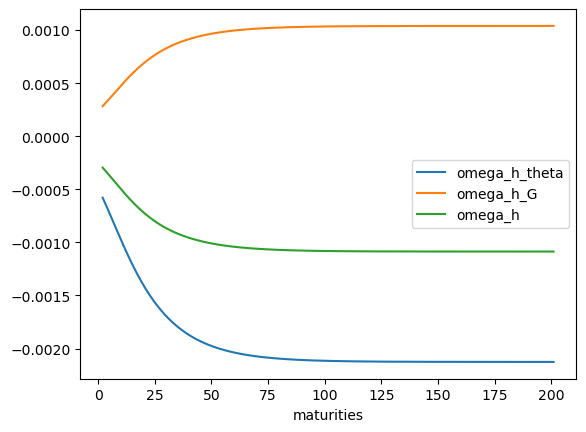

In [188]:
Qrf=QT(1)
omega_h_theta_finer=(1/(Qrf* B_T ))*( Upsilon_T *kappa_theta / (1-  beta_hat) -  0*G_T *kappa_G / (1-  beta_hat) )*np.matmul(Pi_finer,kappa_finer)*sigma2_f
omega_h_G_finer=(1/(Qrf* B_T ))*( 0*Upsilon_T *kappa_theta / (1-  beta_hat) -  G_T *kappa_G / (1-  beta_hat) )*np.matmul(Pi_finer,kappa_finer)*sigma2_f


omega_h_finer=(1/(Qrf* B_T ))*( Upsilon_T *kappa_theta / (1-  beta_hat) -  G_T *kappa_G / (1-  beta_hat) )*np.matmul(Pi_finer,kappa_finer)*sigma2_f

Loadings_finer['omega_h']=omega_h_finer
Loadings_finer['omega_h_theta']=omega_h_theta_finer
Loadings_finer['omega_h_G']=omega_h_G_finer

Loadings_finer[['omega_h_theta','omega_h_G','omega_h']].plot()

print("Sum of hedging - portfolios = "+ str(Loadings_finer[['omega_h_theta','omega_h_G','omega_h']].sum()))

#### Construct $\Sigma^Q$ 

In [189]:

def  get_SigmaInfty():
    Nm=N*4*4
    maturities= Loadings.maturities
    maturities_finer=np.linspace(2,Nm+1,Nm)
    kappa_finer=np.zeros(len(maturities_finer))
    alpha_finer=np.zeros(len(maturities_finer))

    sigma2_finer=np.zeros(len(maturities_finer))
    sigma2_raw_finer=np.zeros(len(maturities_finer))

    for n in maturities_finer:
            kappa_finer[int(n)-2]=func_kappa(n)
            alpha_finer[int(n)-2]=func_alpha(n)
            sigma2_finer[int(n)-2]=func_sigma2(n)        
            sigma2_raw_finer[int(n)-2]=func_sigma2_raw(n)


    Delta_finer = np.diag(sigma2_finer)
    Pi_finer, Sigma_finer = getPi(Delta_finer, kappa_finer, data.factor.var())
    np.save('Sigma_finer_tt.npy', Sigma_finer)
    np.save('maturities_finer_tt.npy', maturities_finer)
    np.save('alpha_finer_tt.npy', alpha_finer)
    np.save('kappa_finer_tt.npy', kappa_finer)
           

get_SigmaInfty()

#### Optimal interest risk portfolio



In [190]:
SigmaInfinity = np.load('Sigma_finer_tt.npy')
maturitiesInfinity = np.load('maturities_finer_tt.npy')
alphaInfinity = np.load('alpha_finer_tt.npy')
kappaInfinity = np.load('kappa_finer_tt.npy')

sQ=np.zeros(len(maturitiesInfinity))
sQunNormalized=np.zeros(len(maturitiesInfinity))
for k in range(len(maturitiesInfinity)):
    sQ[k]=QT(k+1)*Gamma**(k+1)


SigmaQ = SigmaInfinity[:len(maturities_finer), :]

W =  (1-beta_hat)*np.matmul(np.matmul(Pi_finer, SigmaQ),sQ)
Loadings_finer['omega_r_fin'] = W
Loadings_finer['omega_r_beta'] = (1-beta_hat)*beta_hat**(maturitiesInfinity[:len(maturities_finer)]-1 )
Loadings_finer['omega_r_QGamma'] = sQ[:N*4]*(1-beta_hat) # check this


print("Sum of Q- portfolio = "+ str(Loadings_finer['omega_r_fin'].sum()))
Loadings_finer['omega_r_fin'].sum()
Loadings_finer["Q"]=[QT(mat) for mat in Loadings_finer.index]


Sum of Q- portfolio = 1.0008401245729714


1.0008401245729714

<Axes: xlabel='maturities'>

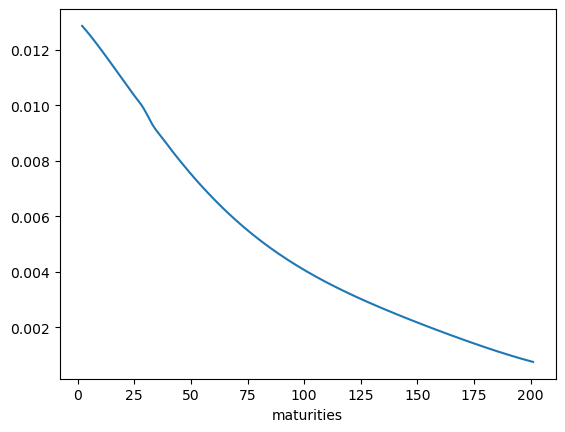

In [191]:
Loadings_finer['omega_r_fin'].plot()

<Axes: xlabel='maturities'>

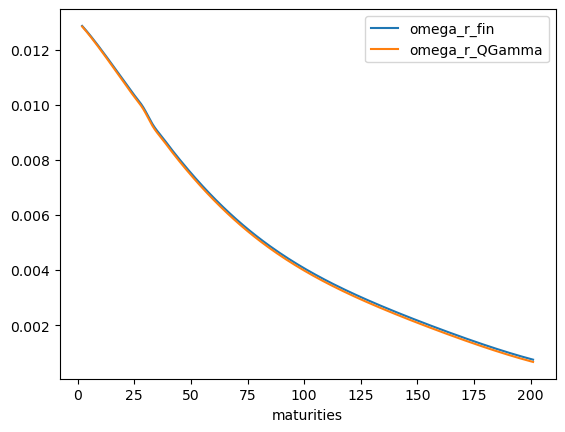

In [192]:
Loadings_finer[['omega_r_fin','omega_r_QGamma']].plot()

#### Optimal Portfolio


<Axes: xlabel='maturities'>

fraction in the risk free bond


0.19864777621880692

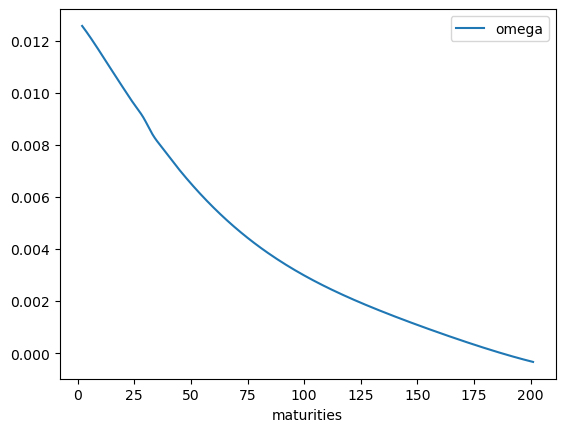

In [193]:
Loadings_finer['omega'] = Loadings_finer['omega_h'] + \
    Loadings_finer['omega_r_fin']
Loadings_finer[['omega']].plot()
print("fraction in the risk free bond")
1-Loadings_finer['omega'].sum()
Loadings_finer.to_csv('Loadings_finer_finite_N50.csv')


#### 3 Components of the  optimal capped (only risky maturities)

In [195]:
temp=[]
usdata=(pd.read_csv('../Data/omega_2017.csv').set_index('tmduratn_bin')/100)
temp=pd.DataFrame(np.ones(len(Loadings_finer.index)+1))
temp.index=range(1,len(maturities_finer)+2)
temp["omega capped"]=0
temp["omega_X"]=0
temp["omega_Q"]=0
temp["omega MF"]=0
temp["omega_US"]=0
temp["omega_QGamma"]=0

temp["(1-beta)beta^j"]=0


temp.loc[1:len(usdata),"omega_US"]=(pd.read_csv('../Data/omega_2017.csv').set_index('tmduratn_bin')/100)
temp["omega_US"]=temp["omega_US"].fillna(0)
temp.loc[2:,"omega capped"]=Loadings_finer.omega.values
temp.loc[2:,"omega_X"]=Loadings_finer.omega_h.values
temp.loc[2:,"(1-beta)beta^j"]=Loadings_finer.omega_r_beta.values
temp.loc[1,"omega capped"]=1-np.sum(Loadings_finer.omega.values)
temp.loc[2:,"omega_G"]=Loadings_finer.omega_h_G.values
temp.loc[2:,"omega_theta"]=Loadings_finer.omega_h_theta.values
temp.loc[2:,"omega_Q"]=Loadings_finer.omega_r_fin.values
temp.loc[2:,"QGamma"]=Loadings_finer.omega_r_QGamma.values





In [196]:
temp.to_csv("Loadings_finer_N50.csv")

<Axes: >

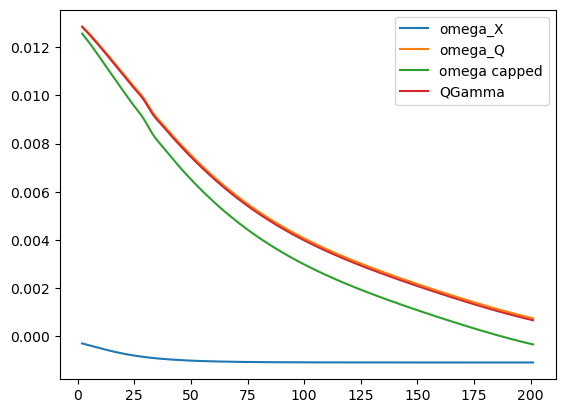

In [197]:
temp[temp.index>1][["omega_X","omega_Q","omega capped","QGamma"]].plot()

In [198]:
def plot_fig(columns=["omega capped", 'omega_US', 'omega_Q', 'omega_X'], name='u',
            leg=[r"target portfolio",
                 r"U.S. portfolio", r"$\left(1-\hat{\beta}\right)\mathtt{\overrightarrow{\beta}}$", 
                 r"$\left(1-\hat{\beta}\right)\mathtt{\overrightarrow{\beta}}$"],
            T=len(temp),
            Max_y=6.0,
             col=['darkred', 'black', 'darkseagreen'],
            marker=['None' ,'None', 'None'],
            markersize=['3','1','2'],linestyle=['--', '-', '-'],alpha=[1,1,1]):
               fig, ax = plt.subplots()
               cycler = plt.cycler(linestyle=linestyle,marker=marker,markersize=markersize,alpha=alpha)
               #ax.set_prop_cycle(cycler)
               fig     = (temp[columns]*100).plot(lw=1,color=col,ax=ax).get_figure()
               columns = [x.replace('omega_', '') for x in columns]
               columns = [x.replace('gr', 'base') for x in columns]
               leg     = leg
               fig.set_dpi(200)
               plt.xlim(2, T)
               plt.ylim(-.5, Max_y)
               plt.xlabel("Maturity, quarters")
               plt.ylabel("Portfolio share, percent")
               plt.legend(leg)
               fig.savefig(draft_path+"{}.pdf".format(name))

               return fig


In [199]:
def plot_fig(
    columns=["omega capped", 'omega_US', 'omega_Q', 'omega_X'], 
    name='u',
    leg=[
        r"target portfolio",
        r"U.S. portfolio", 
        r"$\left(1-\hat{\beta}\right)\mathtt{\overrightarrow{\beta}}$", 
        r"$\left(1-\hat{\beta}\right)\mathtt{\overrightarrow{\beta}}$"
    ],
    T=None,
    Max_y=6.0,
    col=['darkred', 'black', 'darkseagreen'],
    marker=['None', 'None', 'None'],
    markersize=['3', '1', '2'],
    linestyle=['--', '-', '-.'],
    alpha=[0.5, 0.6, 0.7]
):
    # Create a copy of the data to avoid modifying the original DataFrame
    data_to_plot = temp[columns].copy() * 100

    if T is None:
        T = len(temp)

    fig, ax = plt.subplots()

    # Iterate over each column and plot with specified alpha
    for i, col_name in enumerate(columns):
        ax.plot(
            data_to_plot[col_name],  # Use the copied data
            color=col[i % len(col)], 
            lw=1, 
            linestyle=linestyle[i % len(linestyle)], 
            marker=marker[i % len(marker)], 
            markersize=float(markersize[i % len(markersize)]),
            alpha=alpha[i % len(alpha)]
        )
    
    columns = [x.replace('omega_', '') for x in columns]
    columns = [x.replace('gr', 'base') for x in columns]
    leg = leg
    
    fig.set_dpi(200)
    plt.xlim(2, T)
    plt.ylim(-0.5, Max_y)
    plt.xlabel("Maturity, quarters")
    plt.ylabel("Portfolio share, percent")
    plt.legend(leg)
    fig.savefig(draft_path + "{}.pdf".format(name))

    return fig


<Axes: xlabel='maturities'>

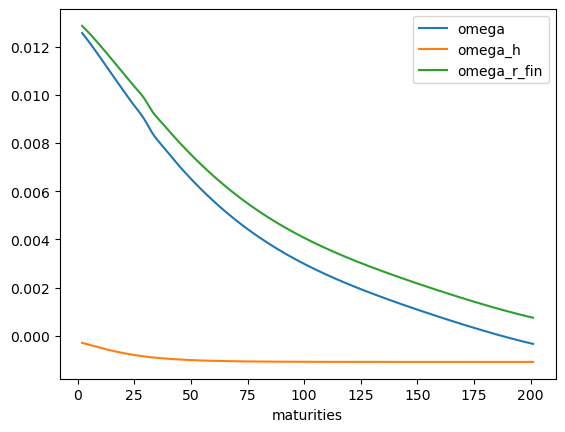

In [200]:
Loadings_finer[["omega","omega_h","omega_r_fin"]].plot()

In [201]:
Loadings_finer[["omega","omega_h","omega_r_fin"]].sum()

omega          0.8014
omega_h       -0.1995
omega_r_fin    1.0008
dtype: float64

### Price Effects with N=50

In [202]:
def getGVestimates(GVData):
    initial_guess = [0.002, .08]
    resultGV = optimize.minimize(lambda x:np.sum ((GVData.estimates-(x[0]-x[0]*np.exp(-x[1]*GVData.maturities.values*2)) )**2) , initial_guess,method='Nelder-Mead')
    print("a and b for GV" )
    resultGV.x
    func_GV = lambda n: (resultGV.x[0]-resultGV.x[0]*np.exp(-resultGV.x[1]*(n**2)))/4
    return func_GV


def getRatioQ(QT, maturities):
    den=np.array([QT(mat) for mat in range(3,len(maturities)+2 ) ])
    num=np.array([QT(mat) for mat in range(2,len(maturities)+1) ])
    ratioQ=np.array([QT(mat+2)/QT(mat+3) for mat in range(len(maturities)-1)])
    return ratioQ

# check this construct
def getLPlusMat(QT,maturities,Gamma):
    ratioQ=getRatioQ(QT, maturities)
    IMat=np.identity(len(maturities))
    LplusMat=np.diag((Gamma)**(-1)*ratioQ)
    LplusMat= np.hstack(( np.zeros(((len(maturities)-1),1 )),LplusMat))
    LplusMat= np.vstack(( LplusMat,np.zeros(((len(maturities)) ))))
    LplusMat[-1,-1]=0.0
    return LplusMat

def getPimat(maturities):
    kappa_finer=np.zeros(len(maturities))
    alpha_finer=np.zeros(len(maturities))
    sigma2_finer=np.zeros(len(maturities))
    sigma2_raw_finer=np.zeros(len(maturities))

    for n in maturities:
            kappa_finer[int(n)-2]=func_kappa(n)
            alpha_finer[int(n)-2]=func_alpha(n)
            sigma2_finer[int(n)-2]=func_sigma2(n)        
            sigma2_raw_finer[int(n)-2]=func_sigma2_raw(n)


    Delta_finer = np.diag(sigma2_finer)
    Pi_finer, Sigma_finer = getPi(Delta_finer, kappa_finer, macrodata.factor.var())
    return Pi_finer


def getPE( maturities,tau_bar,γ,beta_hat,QT,Gamma,GVData):
    dpe =  (-ζ(tau_bar, γ)**2  / ζ_prime(tau_bar, γ))*(1/( (1-  beta_hat)))*(QT(1)**(-2))
    dpe=dpe*(100**2) #convert to natural units
    func_GV=getGVestimates(GVData)
    nmax=40
    funcGVval=func_GV(np.array(range(1,nmax)))
    DataForLambda=(range(1,nmax)/temp.omega_US[1:nmax])*funcGVval*7.3
    #DataForLambda[nmax]=100
    LamMatVal=np.ones(len(maturities_finer))*DataForLambda[nmax]
    LamMatVal[0:len(DataForLambda)]=DataForLambda
    LamMat=np.diag(LamMatVal)
    LambdaRF=func_GV(1)/temp.omega_US[1]
    
    ratioQ=getRatioQ(QT,maturities)
    LplusMat=getLPlusMat(QT,maturities,Gamma)
    IMat=np.identity(len(maturities))
    # compute Y x Lambda x (I-Lplus)
    LamTildeMat = LamMat @ (IMat-LplusMat)
    Pi_finer=getPimat(maturities)
    price_effects_factor_lhs=IMat+ dpe * (Pi_finer @ LamTildeMat)
    #price_effects_factor=np.linalg.inv(IMat+d*np.matmul(Pi_finer,LamTildeMat))
    price_effects_factor=np.linalg.inv(price_effects_factor_lhs)
    return price_effects_factor,LamTildeMat,dpe,LamMat,LambdaRF,ratioQ,IMat,LplusMat


a and b for GV
a and b for GV


<Axes: xlabel='maturities'>

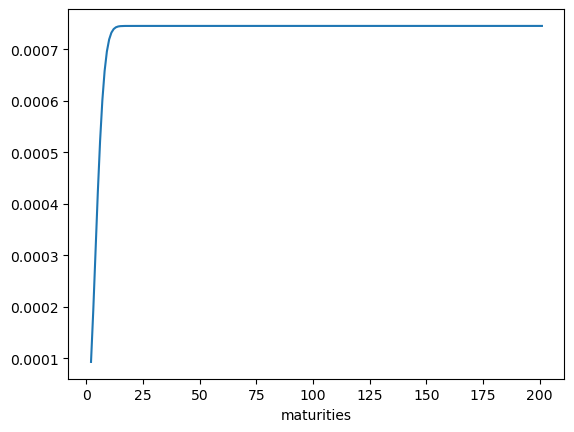

In [203]:
GVestimates=np.array([.001,0.002,0.002,0.002,0.003])
GVmaturities=np.array([2,3,4,5,50])*4
GVData=pd.DataFrame([GVestimates],columns=GVmaturities,index=["estimates"]).T
GVData["maturities"]=GVData.index

price_effects_factor,LamTildeMat,dpe,LamMat,LambdaRF,ratioQ,IMat,LplusMat=getPE( maturities_finer,tau_bar,γ,beta_hat,QT,Gamma,GVData)

func_GV=getGVestimates(GVData)

#plot the GV as function of maturity 
maturities_finer=Loadings_finer.index
GVData_finer=pd.DataFrame()
GVData_finer["GV_finer"]=func_GV(maturities_finer)
GVData_finer["maturities"]=maturities_finer
GVData_finer.set_index("maturities",inplace=True)
GVData_finer["GV_finer"].plot()
#Loadings_finer[["omega", 'omega_pe']].plot()
#Loadings_finer[["omega", 'omega_pe']].sum()

[range(1, 21), range(2, 22), range(3, 23), range(4, 24), range(5, 25), range(6, 26), range(7, 27), range(8, 28), range(9, 29), range(10, 30), range(11, 31), range(12, 32), range(13, 33), range(14, 34), range(15, 35), range(16, 36), range(17, 37), range(18, 38), range(19, 39), range(20, 40), range(21, 41), range(22, 42), range(23, 43), range(24, 44), range(25, 45), range(26, 46), range(27, 47), range(28, 48), range(29, 49), range(30, 50), range(31, 51), range(32, 52), range(33, 53), range(34, 54), range(35, 55), range(36, 56), range(37, 57), range(38, 58), range(39, 59), range(40, 60), range(41, 61), range(42, 62), range(43, 63), range(44, 64), range(45, 65), range(46, 66), range(47, 67), range(48, 68), range(49, 69), range(50, 70), range(51, 71), range(52, 72), range(53, 73), range(54, 74), range(55, 75), range(56, 76), range(57, 77), range(58, 78), range(59, 79), range(60, 80), range(61, 200)]


<Figure size 800x600 with 0 Axes>

Text(0.5, 0, 'x_data')

Text(0, 0.5, 'y_data')

Text(0.5, 1.0, 'Nearest Neighbor Extrapolation (2 to 200)')

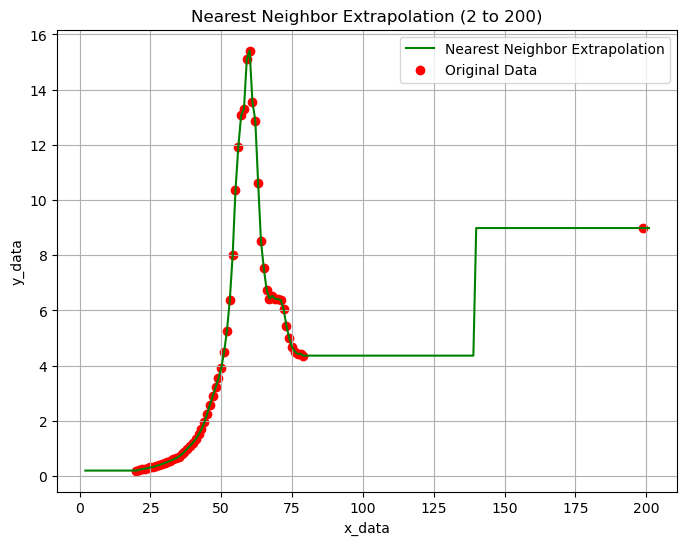

In [204]:
omega_US=temp.omega_US.values
namxy=15
bins=[range(n+1,n+1+4*5) for n in range(4*namxy)]
bins=[*bins,range(4*namxy+1,N*4)]
print(bins)
DataForLambdaVal=np.zeros(len(bins))
DataForLambdaMat=np.zeros(len(bins))
for ibin  in range(len(bins)):
    binval=bins[ibin]
    omegabin=sum(omega_US[binval])
    matbin=np.max(binval)
    funcGVval=func_GV(matbin)
    DataForLambdaVal[ibin]=(matbin/omegabin)*funcGVval*7.3
    DataForLambdaMat[ibin]=matbin
x_data = DataForLambdaMat
y_data = DataForLambdaVal

from scipy.interpolate import interp1d
x_data_extended = np.arange(2, N*4+2, 1)

# Create a nearest-neighbor interpolation function
nearest_neighbor_func = interp1d(x_data, y_data, kind='nearest', fill_value='extrapolate')

# Apply the nearest neighbor interpolation to the extended x_data range (2 to 121)
y_nearest = nearest_neighbor_func(x_data_extended)

# Plotting the nearest neighbor extrapolation for the extended x_data range
plt.figure(figsize=(8,6))
plt.plot(x_data_extended, y_nearest, label=f'Nearest Neighbor Extrapolation', color='green')
plt.scatter(x_data, y_data, color='red', label='Original Data')
plt.xlabel('x_data')
plt.ylabel('y_data')
plt.title('Nearest Neighbor Extrapolation (2 to 200)')
plt.legend()
plt.grid(True)
plt.show()
LamMat=np.diag(y_nearest)
LambdaRF=func_GV(1)*7.3/omega_US[1]

In [205]:
# iterate on the  equation \omega_{t+1}=BMat\omega^{*}-Amat\omega_{t} with initial guess omega_{t}=Loadings_finer.omega.values. BMat,Amat is a matrix and omega_{t} is a vector
# Define the variables
omega_star = Loadings_finer.omega.values  # Define the target vector omega_star
pefactor=np.linalg.inv(IMat+dpe*(Pi_finer@(LamMat@(IMat-LplusMat))))
omega_ss=pefactor@omega_star
omega_t = omega_ss  # Initial guess for omega_t
# Set the number of iterations
num_iterations = 2000 # You can adjust this as needed

omega_t_mat=np.zeros((num_iterations,len(maturities_finer)))
omega_t_mat[0,:]=omega_t
#LambdaRFGV=func_GV(1)

#print("LambdaRFGV = "+str(LambdaRFGV))
omega_US=temp.omega_US[1:].values
omega0US=1-sum(omega_US)
print("omega0US = "+str(omega0US))
#LambdaRF=LambdaRFGV/(1+LambdaRFGV*omega0US*B_T)
#LamMatVal=np.zeros(len(omega_US)) # initialize LamMatVal
#range(2,len(omega_t)+2)
#for mat in range(2,len(omega_t)+2):
#    num=(mat)*func_GV(mat)
#    LamMatVal[int(mat)-2]=(num)/(1+num*omega_US[int(mat)-2]*B_T)  

#LamMat=np.diag(LamMatVal)

#LambdaRF=LambdaRFGV/(1+LambdaRFGV*omega0US*B_T)

# Iteratively update omega_t
for _ in range(num_iterations):
    omega0=1-sum(omega_t) # rf holding
    omega0plus=omega_t[0]*QT(1)/(QT(2)*Gamma) #riskfree+
    ht=np.ones(len(omega_t))*LambdaRF*(omega0-omega0plus) # ht = LambdaRF*(omega0-omega0plus)
    dSigmaInvh=dpe*(Pi_finer@ht) # dSigmaInvh = d*Pi*ht
    BMatBeforeInv=IMat+dpe*(Pi_finer @ LamMat) # IMat+d*Pi_finer @ LamMat
    BMat=np.linalg.inv(BMatBeforeInv) # BMat = inv(IMat+d*Pi_finer @ LamMat)
    AMat1=(IMat+dpe*(Pi_finer @ LamMat)) # IMat+d*Pi_finer @ LamMat
    Amat2=dpe*Pi_finer@(LamMat @ LplusMat)  # d*Pi_finer @ (LamMat @ LplusMat)
    Amat=(np.linalg.inv(AMat1)) @ Amat2 # Amat = inv(AMat1) @ Amat2
    omega_t = BMat @ (omega_star+dSigmaInvh) + Amat @ omega_t  # omega_t = BMat @ (omega_star+dSigmaInvh) + Amat @ omega_{t-1}
    omega_t_mat[_,:]=omega_t
    # print every 100 iterations
    if _ % 100 == 0:
        print("num interations = "+str(_))
    


omega0US = 0.107262688555113
num interations = 0
num interations = 100
num interations = 200
num interations = 300
num interations = 400
num interations = 500
num interations = 600
num interations = 700
num interations = 800
num interations = 900
num interations = 1000
num interations = 1100
num interations = 1200
num interations = 1300
num interations = 1400
num interations = 1500
num interations = 1600
num interations = 1700
num interations = 1800
num interations = 1900


<Axes: xlabel='maturities'>

omega            0.8014
omega_pe_bonds   0.9453
dtype: float64

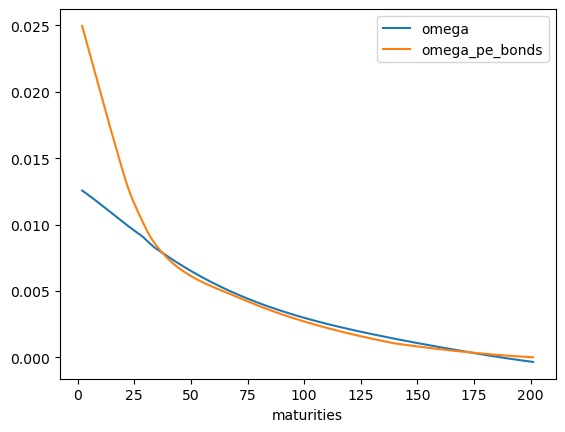

In [206]:
Loadings_finer['omega_pe_bonds']=omega_t

Loadings_finer[["omega",'omega_pe_bonds']].plot()
Loadings_finer[["omega",'omega_pe_bonds']].sum()

####  Figure 4 (b)

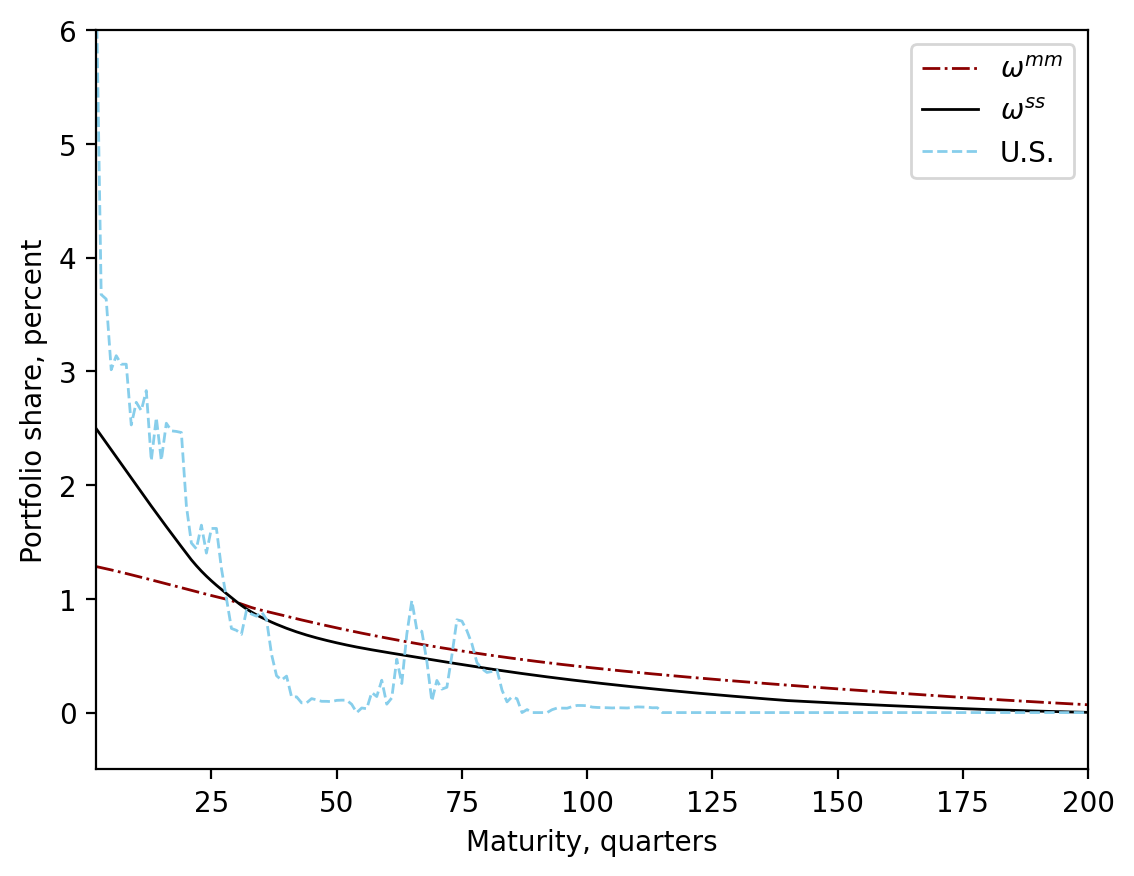

In [207]:
temp.loc[2:,"omega PE Bonds"]=Loadings_finer.omega_pe_bonds.values


priceeffects = plot_fig(name='opt_pe_N50', T=len(maturities_finer), marker=['None','None','None'], columns=["QGamma", 'omega PE Bonds','omega_US'], leg=[r"$\omega^{mm}$",r"$\omega^{ss}$ ",r"U.S."], col=['darkred','black','skyblue'],linestyle=["-.","-",'--'],markersize=['1','2','1'] , Max_y=6,alpha=[1,1,1])


In [208]:
Macaulay=temp.reset_index()
Mc_US=(Macaulay['omega_US']*Macaulay['index']/4).sum()
Mc_th_bonds = (Macaulay['omega PE Bonds'] * Macaulay['index'] / 4).sum()

print("Mcaulay US = {}".format(Mc_US))
print("Mcaulay PE (Lambda0>0)= {}".format(Mc_th_bonds))

Mcaulay US = 5.285136107905256
Mcaulay PE (Lambda0>0)= 10.181537732031273
